# A mechanistic interpretability approach to understanding how Gemma-2-2B processes self-reflections

This notebook reproduces the statistical analyses and visualizations reported in the BlackboxNLP paper using Gemma-2-2B.




In [1]:
# =============================================================================
# SETUP — imports, paths, and fixed settings
# =============================================================================
from pathlib import Path  # object-oriented file paths
import hashlib  # checksum helper for activation cache verification

import matplotlib.pyplot as plt  # figure rendering
import numpy as np  # numeric arrays and linear algebra
import pandas as pd  # tabular data (CSV loading)
from scipy.stats import pearsonr, spearmanr  # correlation metrics
from sklearn.linear_model import Ridge, RidgeCV  # ridge regression models
from sklearn.model_selection import KFold  # cross-validation splitter
from sklearn.preprocessing import StandardScaler  # zero-mean / unit-variance scaling

# --- Repository paths ---
ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "prl_metacognition_deidentified.csv").exists():
    nested_root = ROOT / "mp-llm-geometry"
    if (nested_root / "data" / "prl_metacognition_deidentified.csv").exists():
        ROOT = nested_root
    else:
        raise FileNotFoundError(
            "Run this notebook from the mp-llm-geometry repository root."
        )

DATA_DIR = ROOT / "data"
FIGURE_DIR = ROOT / "figures"
DATA_CSV = DATA_DIR / "prl_metacognition_deidentified.csv"
POOLED_PATH = DATA_DIR / "gemma2_2b_mean_pooled_residual_stream.npz"
FIG_PATH = FIGURE_DIR / "fig1.png"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# --- Extraction protocol (keep fixed so activations do not drift) ---
MODEL_NAME = "google/gemma-2-2b"  # base model, not the instruct version
DTYPE = "bfloat16"  # numeric precision during the forward pass
LAYERS = list(range(26))  # Gemma-2-2B has 26 residual blocks (0..25)
MAX_TOKENS = 512  # truncate longer reflections
BATCH_SIZE = 16  # reflections processed per GPU batch

# --- Analysis settings ---
SEED = 17  # makes cross-validation splits repeatable
CV_FOLDS = 5  # 5-fold cross-validation
N_BOOT = 5000  # participant-bootstrap draws used throughout
RECOMPUTE_ACTIVATIONS = False  # set True to overwrite the shared activation checkpoint
RECOMPUTE_FULL_VOCAB = False  # set True to rerun the expensive GPU vocabulary sweep
RNG = np.random.default_rng(SEED)  # seeded random generator for bootstrapping
MM = 1 / 25.4  # convert millimetres to inches for figure sizing

# --- Column names and plot colours ---
TEXT_COL = "combined_reflection"  # column containing reflection text
MP_DIMS = [  # five GPT-4 rubric score columns
    "comprehension_continuous",  # comprehension rubric score
    "judgment_continuous",  # judgment rubric score
    "evaluation_continuous",  # evaluation rubric score
    "final_decision_continuous",  # final-decision rubric score
    "confidence_continuous",  # confidence rubric score
]  # end MP_DIMS list
LABELS = {  # short human-readable names for plotting
    "comprehension_continuous": "Comprehension",  # plot label for comprehension
    "judgment_continuous": "Judgment",  # plot label for judgment
    "evaluation_continuous": "Evaluation",  # plot label for evaluation
    "final_decision_continuous": "Final decision",  # plot label for final decision
    "confidence_continuous": "Confidence",  # plot label for confidence
}  # end LABELS dict
COLORS = {  # hex colours matching the paper figure
    "judgment_continuous": "#4A7CB5",  # blue for judgment
    "evaluation_continuous": "#52A068",  # green for evaluation
    "comprehension_continuous": "#A8844A",  # gold for comprehension
    "final_decision_continuous": "#2D2D2D",  # dark grey for final decision
    "confidence_continuous": "#9678A8",  # purple for confidence
}  # end COLORS dict

print("Repository root:", ROOT)
print("Raw data:", DATA_CSV, "[present]" if DATA_CSV.exists() else "[missing]")
print("Activation checkpoint:", POOLED_PATH, "[present]" if POOLED_PATH.exists() else "[missing]")


Repository root: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry
Raw data: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\data\prl_metacognition_deidentified.csv [present]
Activation checkpoint: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\data\gemma2_2b_mean_pooled_residual_stream.npz [present]


## 1. Load the raw data

Each **row** is one person. Row 0 in the CSV must stay row 0 everywhere else — that is how we keep labels aligned with activations.

- **`combined_reflection`**: the text Gemma reads
- **Five `*_continuous` columns**: GPT-4 rubric scores (our labels)
- **`refl_len_log`**: log reflection length — used later to remove "longer text → higher score" effects


In [2]:
# --- Load CSV and build helper columns ---
df = pd.read_csv(DATA_CSV).reset_index(drop=True)  # read CSV; row order becomes 0..n-1
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)  # replace missing text with empty string
df["refl_len_chars"] = df[TEXT_COL].str.len()  # count characters in each reflection
df["refl_len_log"] = np.log1p(df["refl_len_chars"])  # log1p length for length-residualisation
df["mp_mean"] = df[MP_DIMS].mean(axis=1)  # average across five rubric dimensions

n = len(df)  # number of participants (486)
loglen = df["refl_len_log"].to_numpy(dtype=float)  # length control variable as numpy array
texts = df[TEXT_COL].tolist()  # list of reflection strings for tokenisation

print("Participants:", n)  # print sample size
df[["id", "refl_len_chars"] + MP_DIMS].head(3)  # preview first three rows


Participants: 486


,id,refl_len_chars,comprehension_continuous,judgment_continuous,evaluation_continuous,final_decision_continuous,confidence_continuous
0,208,7,0.0,0.0,0.0,0.0,0.0
1,73,234,3.0,3.1,2.5,3.4,2.0
2,27,183,2.1,2.3,1.7,2.7,1.6


## 2. Extract or load Gemma activations

When Gemma reads a reflection, each transformer layer produces one vector per token. We mean-pool the non-padding, non-BOS token vectors to obtain one 2,304-dimensional representation per participant and layer.

The checkpoint stores `mean_L0` through `mean_L25`, participant identifiers, and reflection lengths in `data/gemma2_2b_mean_pooled_residual_stream.npz`. Later figure sections reuse this participant-aligned artifact. By default the notebook validates and reuses it; set `RECOMPUTE_ACTIVATIONS = True` to regenerate it from the raw reflection text on a CUDA GPU.


In [3]:
# --- Helper functions for extraction ---

def hidden_state_index(layer):  # convert block index to hidden_states index
    # Map residual block index L to HuggingFace hidden_states index (L+1).
    return layer + 1  # after block L, the residual stream is hidden_states[L+1]


def mean_pool(h, include_mask):  # mean-pool token vectors using a boolean mask
    # Average token vectors where include_mask is True.
    # h shape: [batch, tokens, features]
    weights = include_mask.unsqueeze(-1).float()  # broadcast mask to feature dimension
    total = (h.float() * weights).sum(dim=1)  # sum token vectors, ignoring masked tokens
    count = weights.sum(dim=1).clamp(min=1.0)  # number of included tokens per sequence
    return (total / count).cpu().numpy()  # mean vector per sequence, moved to CPU numpy


def fingerprint(pooled):  # compute quick checksum of layer-12 activations
    # Small checksum so you can confirm your cache matches the reference run.
    h12 = pooled["mean_L12"].astype(float)  # layer-12 activation matrix as float64
    return {  # return two quick checksums
        "sum_L12": round(float(h12.sum()), 6),  # scalar sum for quick comparison
        "sha256_L12": hashlib.sha256(h12.tobytes()).hexdigest()[:16],  # hash prefix
    }  # end fingerprint dict


In [4]:
# --- Reuse the shared checkpoint or extract activations from Gemma ---
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

if POOLED_PATH.exists() and not RECOMPUTE_ACTIVATIONS:
    with np.load(POOLED_PATH, allow_pickle=False) as checkpoint:
        pooled = {key: checkpoint[key] for key in checkpoint.files}
    print("Loaded activation checkpoint:", POOLED_PATH)
else:
    if not torch.cuda.is_available():
        raise RuntimeError(
            "A CUDA GPU is required to create the activation checkpoint. "
            "Provide artifacts/pooled_all_layers.npz or run on a GPU."
        )

    torch.manual_seed(SEED)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    tokenizer.padding_side = "right"
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=getattr(torch, DTYPE),
        device_map={"": 0},
    ).eval()

    d_model = model.config.hidden_size
    activations = {
        layer: np.zeros((n, d_model), dtype=np.float32) for layer in LAYERS
    }

    for start in range(0, n, BATCH_SIZE):
        batch = tokenizer(
            texts[start : start + BATCH_SIZE],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_TOKENS,
        ).to(model.device)
        with torch.no_grad():
            hidden_states = model(
                **batch, output_hidden_states=True
            ).hidden_states

        include = batch["attention_mask"].bool().clone()
        include[:, 0] = False  # exclude BOS
        batch_size = len(batch["input_ids"])
        for layer in LAYERS:
            activations[layer][start : start + batch_size] = mean_pool(
                hidden_states[hidden_state_index(layer)], include
            )
        if start // BATCH_SIZE % 5 == 0:
            print(f"  extracted {min(start + BATCH_SIZE, n)}/{n}", flush=True)

    pooled = {
        "ids": df["id"].to_numpy(),
        "refl_len_chars": df["refl_len_chars"].to_numpy(),
        "layers": np.array(LAYERS, dtype=np.int16),
        **{f"mean_L{layer}": activations[layer] for layer in LAYERS},
    }
    np.savez_compressed(POOLED_PATH, **pooled)
    print("Wrote activation checkpoint:", POOLED_PATH)

# The model is not needed after extraction; release GPU memory before later sections.
if "model" in globals():
    del model
    torch.cuda.empty_cache()


C:\Users\ps967\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded activation checkpoint: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\data\gemma2_2b_mean_pooled_residual_stream.npz


In [5]:
# --- Verify activation shape and participant alignment ---
layers = [int(x) for x in pooled["layers"]]  # convert stored layer ids to Python ints

assert pooled["mean_L0"].shape[0] == n  # check row count matches number of participants
assert np.array_equal(pooled["ids"], df["id"].to_numpy())  # check ids match CSV order

print("Layer matrix shape:", pooled["mean_L12"].shape)  # expect (486, 2304)
print("Fingerprint:", fingerprint(pooled))  # print checksum for manual verification


Layer matrix shape: (486, 2304)
Fingerprint: {'sum_L12': 64207.879986, 'sha256_L12': '4685fdcf126fd0d4'}


## 3. Length residualisation

Longer reflections often get higher MP scores *and* different activations. If we skip this step, we might think Gemma "encodes metacognition" when it is partly encoding verbosity.

So, for each variable, we fit a simple line predicting it from log(length), then keep the **leftover part** (the residual).



In [6]:
# --- Remove linear effect of log(length) from any numeric vector or matrix ---

def residualise(values, control):  # subtract linear effect of control from values
    # Remove the linear effect of `control` from `values`.
    # Works for one target column or many activation columns at once.
    control = np.asarray(control, dtype=float).reshape(-1, 1)  # force column vector
    y = np.asarray(values, dtype=float)  # copy target(s) as float array
    if y.ndim == 1:  # if 1-D target, make it 2-D for uniform math
        y = y.reshape(-1, 1)  # shape (n, 1)

    design = np.column_stack([np.ones(len(control)), control])  # intercept + log-length
    beta, _, _, _ = np.linalg.lstsq(design, y, rcond=None)  # fit y ~ 1 + log(length)
    out = y - design @ beta  # subtract fitted length effect → residuals
    return out.ravel() if out.shape[1] == 1 else out  # return 1-D or 2-D as appropriate

# Quick sanity check on Judgment scores.
y_raw = df["judgment_continuous"].to_numpy(dtype=float)  # raw Judgment scores
y_clean = residualise(y_raw, loglen)  # length-residualised Judgment scores
print("Length correlation before:", round(pearsonr(loglen, y_raw)[0], 3))  # should be nonzero
print("Length correlation after:", round(pearsonr(loglen, y_clean)[0], 3))  # should be ~0


Length correlation before: 0.875
Length correlation after: -0.0


## 4. Held-out *r* — how well do activations predict MP scores?

We treat each person's activation vector as input features and their MP score as the target. We train a linear model (ridge regression) and ask: "Do predictions track the true scores?"

**Leakage-free nested evaluation:**
- Split people into 5 outer folds.
- Within each outer training fold, fit the activation and score length-adjustment models using training participants only.
- Fit feature standardization on that same outer training fold.
- Select the ridge penalty from 13 candidate values using `RidgeCV`'s efficient leave-one-out cross-validation within the outer training fold.
- Refit with the selected penalty and predict the untouched outer test fold.
- Repeat until everyone has one held-out prediction.

The held-out target residual for each participant is also computed using only that participant's outer-training fold. Thus neither preprocessing nor hyperparameter selection uses an outer-test participant's score.

**Held-out r:** Pearson correlation between the cross-fitted target residuals and out-of-fold predictions.



In [7]:
# --- Leakage-free nested ridge regression with out-of-fold predictions ---
RIDGE_ALPHAS = np.logspace(-1, 5, 13)


def fit_length_adjustment(values, control):
    """Fit values ~ 1 + control and return coefficients learned on training rows."""
    values = np.asarray(values, dtype=float)
    if values.ndim == 1:
        values = values[:, None]
    design = np.column_stack([np.ones(len(control)), np.asarray(control, dtype=float)])
    return np.linalg.lstsq(design, values, rcond=None)[0]


def apply_length_adjustment(values, control, beta):
    """Apply training-fitted nuisance coefficients to arbitrary rows."""
    values = np.asarray(values, dtype=float)
    was_vector = values.ndim == 1
    if was_vector:
        values = values[:, None]
    design = np.column_stack([np.ones(len(control)), np.asarray(control, dtype=float)])
    adjusted = values - design @ beta
    return adjusted.ravel() if was_vector else adjusted


def ridge_oof(X, y, control, n_folds=CV_FOLDS, seed=SEED):
    """Return outer-OOF predictions, cross-fitted targets, and fold-specific alphas."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    control = np.asarray(control, dtype=float)
    preds = np.zeros(len(y))
    targets = np.zeros(len(y))
    selected_alphas = []
    outer_cv = KFold(n_splits=n_folds, shuffle=True, random_state=seed)

    for train_idx, test_idx in outer_cv.split(X):
        # Every preprocessing quantity is learned without the outer test fold.
        x_beta = fit_length_adjustment(X[train_idx], control[train_idx])
        y_beta = fit_length_adjustment(y[train_idx], control[train_idx])
        X_train = apply_length_adjustment(X[train_idx], control[train_idx], x_beta)
        X_test = apply_length_adjustment(X[test_idx], control[test_idx], x_beta)
        y_train = apply_length_adjustment(y[train_idx], control[train_idx], y_beta)
        targets[test_idx] = apply_length_adjustment(y[test_idx], control[test_idx], y_beta)

        scaler = StandardScaler().fit(X_train)
        X_train = scaler.transform(X_train)
        X_test = scaler.transform(X_test)

        # RidgeCV's default efficient leave-one-out CV is nested inside this outer fold.
        alpha = float(RidgeCV(alphas=RIDGE_ALPHAS).fit(X_train, y_train).alpha_)
        selected_alphas.append(alpha)
        model = Ridge(alpha=alpha).fit(X_train, y_train)
        preds[test_idx] = model.predict(X_test)

    return preds, targets, np.asarray(selected_alphas)


# Worked example: Judgment at layer 14.
layer = 14
target = "judgment_continuous"
X_raw = pooled[f"mean_L{layer}"].astype(float)
y_raw = df[target].to_numpy(dtype=float)
pred, y, fold_alphas = ridge_oof(X_raw, y_raw, loglen)
held_out_r = pearsonr(y, pred).statistic

print(f"{LABELS[target]} at L{layer}: nested held-out r = {held_out_r:.3f}")
print("Outer-fold selected alphas:", fold_alphas)


Judgment at L14: nested held-out r = 0.678
Outer-fold selected alphas: [0.1 0.1 0.1 0.1 0.1]


## 5. Bootstrapping — how uncertain is that *r*?

Held-out r is one number computed from 486 people. Bootstrapping asks: "If we resampled these 486 people with replacement many times, how much would r wiggle?"

**We do the following:**
1. Randomly sample 486 people **with replacement** (some repeat, some missing).
2. Recompute r on that resample.
3. Repeat hundreds of times.
4. Take the middle 95% of those r values → confidence interval.

This helps us judge stability.


In [8]:
# --- Bootstrap 95% CI for held-out Pearson r ---

def bootstrap_r_ci(y, preds, n_boot=N_BOOT, rng=RNG):  # bootstrap 95% CI for Pearson r
    n = len(y)  # sample size
    boot_rs = []  # list to store bootstrap r values

    for _ in range(n_boot):  # repeat bootstrap resampling
        idx = rng.integers(0, n, n)  # draw n indices with replacement
        boot_rs.append(pearsonr(y[idx], preds[idx])[0])  # r on resampled pairs

    boot_rs = np.array(boot_rs)  # convert list to array
    return float(np.percentile(boot_rs, 2.5)), float(np.percentile(boot_rs, 97.5))  # 95% CI

ci_lo, ci_hi = bootstrap_r_ci(y, pred)  # CI for the worked example above
print(f"Held-out r = {held_out_r:.3f}")  # point estimate
print(f"Bootstrap 95% CI = [{ci_lo:.3f}, {ci_hi:.3f}]")  # uncertainty interval


Held-out r = 0.678
Bootstrap 95% CI = [0.606, 0.739]


## 6. Encoding matrix — scan all layers and all MP dimensions

The previous cell checked one layer and one rubric dimension. Figure 1 needs the full grid:

    6 targets  ×  26 layers  =  156 held-out r values

Targets = 5 rubric dimensions + their average (`mp_mean`). Each cell now runs the complete nested procedure above. We retain the participant-level cross-fitted target residuals and predictions so all later Figure 1 and Figure 2 analyses use exactly the same held-out quantities.

This is slower than selecting one penalty on the full dataset because each of the five outer folds performs its own internal penalty selection.


In [9]:
# --- Build full layer × dimension encoding table with nested outer-fold evaluation ---
analysis_dims = MP_DIMS + ["mp_mean"]  # five rubrics plus their row-wise average
raw_targets = {dim: df[dim].to_numpy(dtype=float) for dim in analysis_dims}
raw_activations = {
    layer: pooled[f"mean_L{layer}"].astype(float)
    for layer in layers
}

rows = []
y_res = {}  # cross-fitted target residuals, shared across layers for each dimension
layer_oof = {}  # participant-level outer-OOF predictions
layer_fold_alphas = {}  # five independently selected penalties per layer × dimension

for dim in analysis_dims:
    for layer in layers:
        pred, y_crossfit, fold_alphas = ridge_oof(
            raw_activations[layer], raw_targets[dim], loglen
        )
        if dim not in y_res:
            y_res[dim] = y_crossfit
        else:
            np.testing.assert_allclose(y_res[dim], y_crossfit, rtol=0, atol=1e-12)
        layer_oof[(dim, layer)] = pred
        layer_fold_alphas[(dim, layer)] = fold_alphas
        rows.append({
            "dimension": dim,
            "label": LABELS.get(dim, "MP avg"),
            "layer": layer,
            "r": float(pearsonr(y_crossfit, pred).statistic),
            "alpha_fold_1": fold_alphas[0],
            "alpha_fold_2": fold_alphas[1],
            "alpha_fold_3": fold_alphas[2],
            "alpha_fold_4": fold_alphas[3],
            "alpha_fold_5": fold_alphas[4],
        })
    print("Finished:", LABELS.get(dim, "MP avg"), flush=True)

mat = pd.DataFrame(rows)
mat.to_csv(DATA_DIR / "figure1_nested_encoding_matrix.csv", index=False)
print("Total rows:", len(mat))
mat.head(3)


Finished: Comprehension


Finished: Judgment


Finished: Evaluation


Finished: Final decision


Finished: Confidence


Finished: MP avg


Total rows: 156


,dimension,label,layer,r,alpha_fold_1,alpha_fold_2,alpha_fold_3,alpha_fold_4,alpha_fold_5
0,comprehension_continuous,Comprehension,0,0.459475,0.1,0.1,0.1,0.1,0.1
1,comprehension_continuous,Comprehension,1,0.432265,0.1,0.1,0.1,0.1,0.1
2,comprehension_continuous,Comprehension,2,0.470206,0.1,0.1,0.1,0.1,0.1


## 7. Observed encoding maxima

For each rubric dimension, we identify the layer with the largest observed held-out correlation using the unsmoothed values in `mat`.

These sample maxima—for example, Evaluation L12 and Final Decision L21—are marked in Panel A. They are descriptive argmax estimates rather than precise or distinct processing stages; participant-bootstrap uncertainty in their locations is quantified below.


In [10]:
# --- Find the observed maximizing layer for each dimension ---
maximum_rows = []
for dim in analysis_dims:
    sub = mat[mat.dimension == dim]
    best = sub.loc[sub["r"].idxmax()]
    maximum_rows.append({
        "dimension": dim,
        "label": LABELS.get(dim, "MP avg"),
        "observed_max_layer": int(best["layer"]),
        "observed_max_r": float(best["r"]),
    })

encoding_maxima = pd.DataFrame(maximum_rows)
encoding_maxima[encoding_maxima.dimension.isin(MP_DIMS)]


,dimension,label,observed_max_layer,observed_max_r
0,comprehension_continuous,Comprehension,13,0.508602
1,judgment_continuous,Judgment,14,0.677832
2,evaluation_continuous,Evaluation,12,0.578569
3,final_decision_continuous,Final decision,21,0.619890
4,confidence_continuous,Confidence,16,0.431491


## 8. Depth gradient (panel b)

**Intuition:** does encoding get stronger as you go deeper in the network?

For each dimension we have 26 points: `(layer 0, r₀), (layer 1, r₁), …, (layer 25, r₂₅)`.

**Depth gradient = Spearman correlation between layer number and held-out r.**

- **Positive rho:** encoding tends to increase in deeper layers (late-layer ramp)
- **Negative rho:** encoding is stronger in early layers
- **Near zero:** no steady trend (maybe a mid-layer bump instead)

Spearman (not Pearson) is used because we care about **monotonic trend**, not perfect linearity.


In [11]:
# --- Spearman depth gradient for each dimension ---
grad_rows = []  # list to collect gradient summaries
for dim in analysis_dims:  # loop over six targets
    sub = mat[mat.dimension == dim].sort_values("layer")  # layer-ordered r profile

    rho, _ = spearmanr(sub["layer"], sub["r"])  # rank correlation: layer vs held-out r

    grad_rows.append({  # store gradient info
        "dimension": dim,  # internal name
        "label": LABELS.get(dim, "MP avg"),  # plot label
        "rho": float(rho),  # Spearman depth gradient
    })  # end append dict

grad = pd.DataFrame(grad_rows)  # table of depth gradients
grad[grad.dimension.isin(MP_DIMS)].sort_values("rho", ascending=False)  # show five rubrics, sorted


,dimension,label,rho
4,confidence_continuous,Confidence,0.840000
3,final_decision_continuous,Final decision,0.833162
2,evaluation_continuous,Evaluation,0.228034
1,judgment_continuous,Judgment,-0.105641
0,comprehension_continuous,Comprehension,-0.353162


## 9. Profile shape for panel (a)

**Problem:** Judgment might always encode more strongly than Confidence in absolute terms. Panel A instead compares the shape of each dimension's encoding profile across depth and marks its observed maximum.

**Fix:** for each dimension separately, z-score its 26 layer-wise r values:

    z = (r - mean(r)) / std(r)

Now all curves share a common "shape language" centred at 0.


In [12]:
# --- Z-score a 1-D vector within itself (for panel a profile shape) ---

def zscore_within(values):  # z-score a vector using its own mean and std
    values = np.asarray(values, dtype=float)  # ensure float numpy array
    std = values.std(ddof=0)  # population standard deviation across layers
    if std < 1e-12:  # guard against flat profiles (division by zero)
        return np.zeros_like(values)  # return flat zero line
    return (values - values.mean()) / std  # centre at 0, scale by std

# Demo on Judgment.
rs = mat[mat.dimension == "judgment_continuous"].sort_values("layer")["r"].to_numpy(float)  # raw profile
zs = zscore_within(rs)  # z-scored profile for plotting
print("Raw r range:", round(rs.min(), 3), "to", round(rs.max(), 3))  # absolute scale
print("Z-scored range:", round(zs.min(), 3), "to", round(zs.max(), 3))  # shape-only scale


Raw r range: 0.574 to 0.678
Z-scored range: -2.845 to 1.505


## 10. Draw Figure 1

- **Panel A:** z-scored depth profiles with observed maxima marked
- **Panel (b):** depth gradients sorted from highest to lowest rho


Saved: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\figures\fig1.png


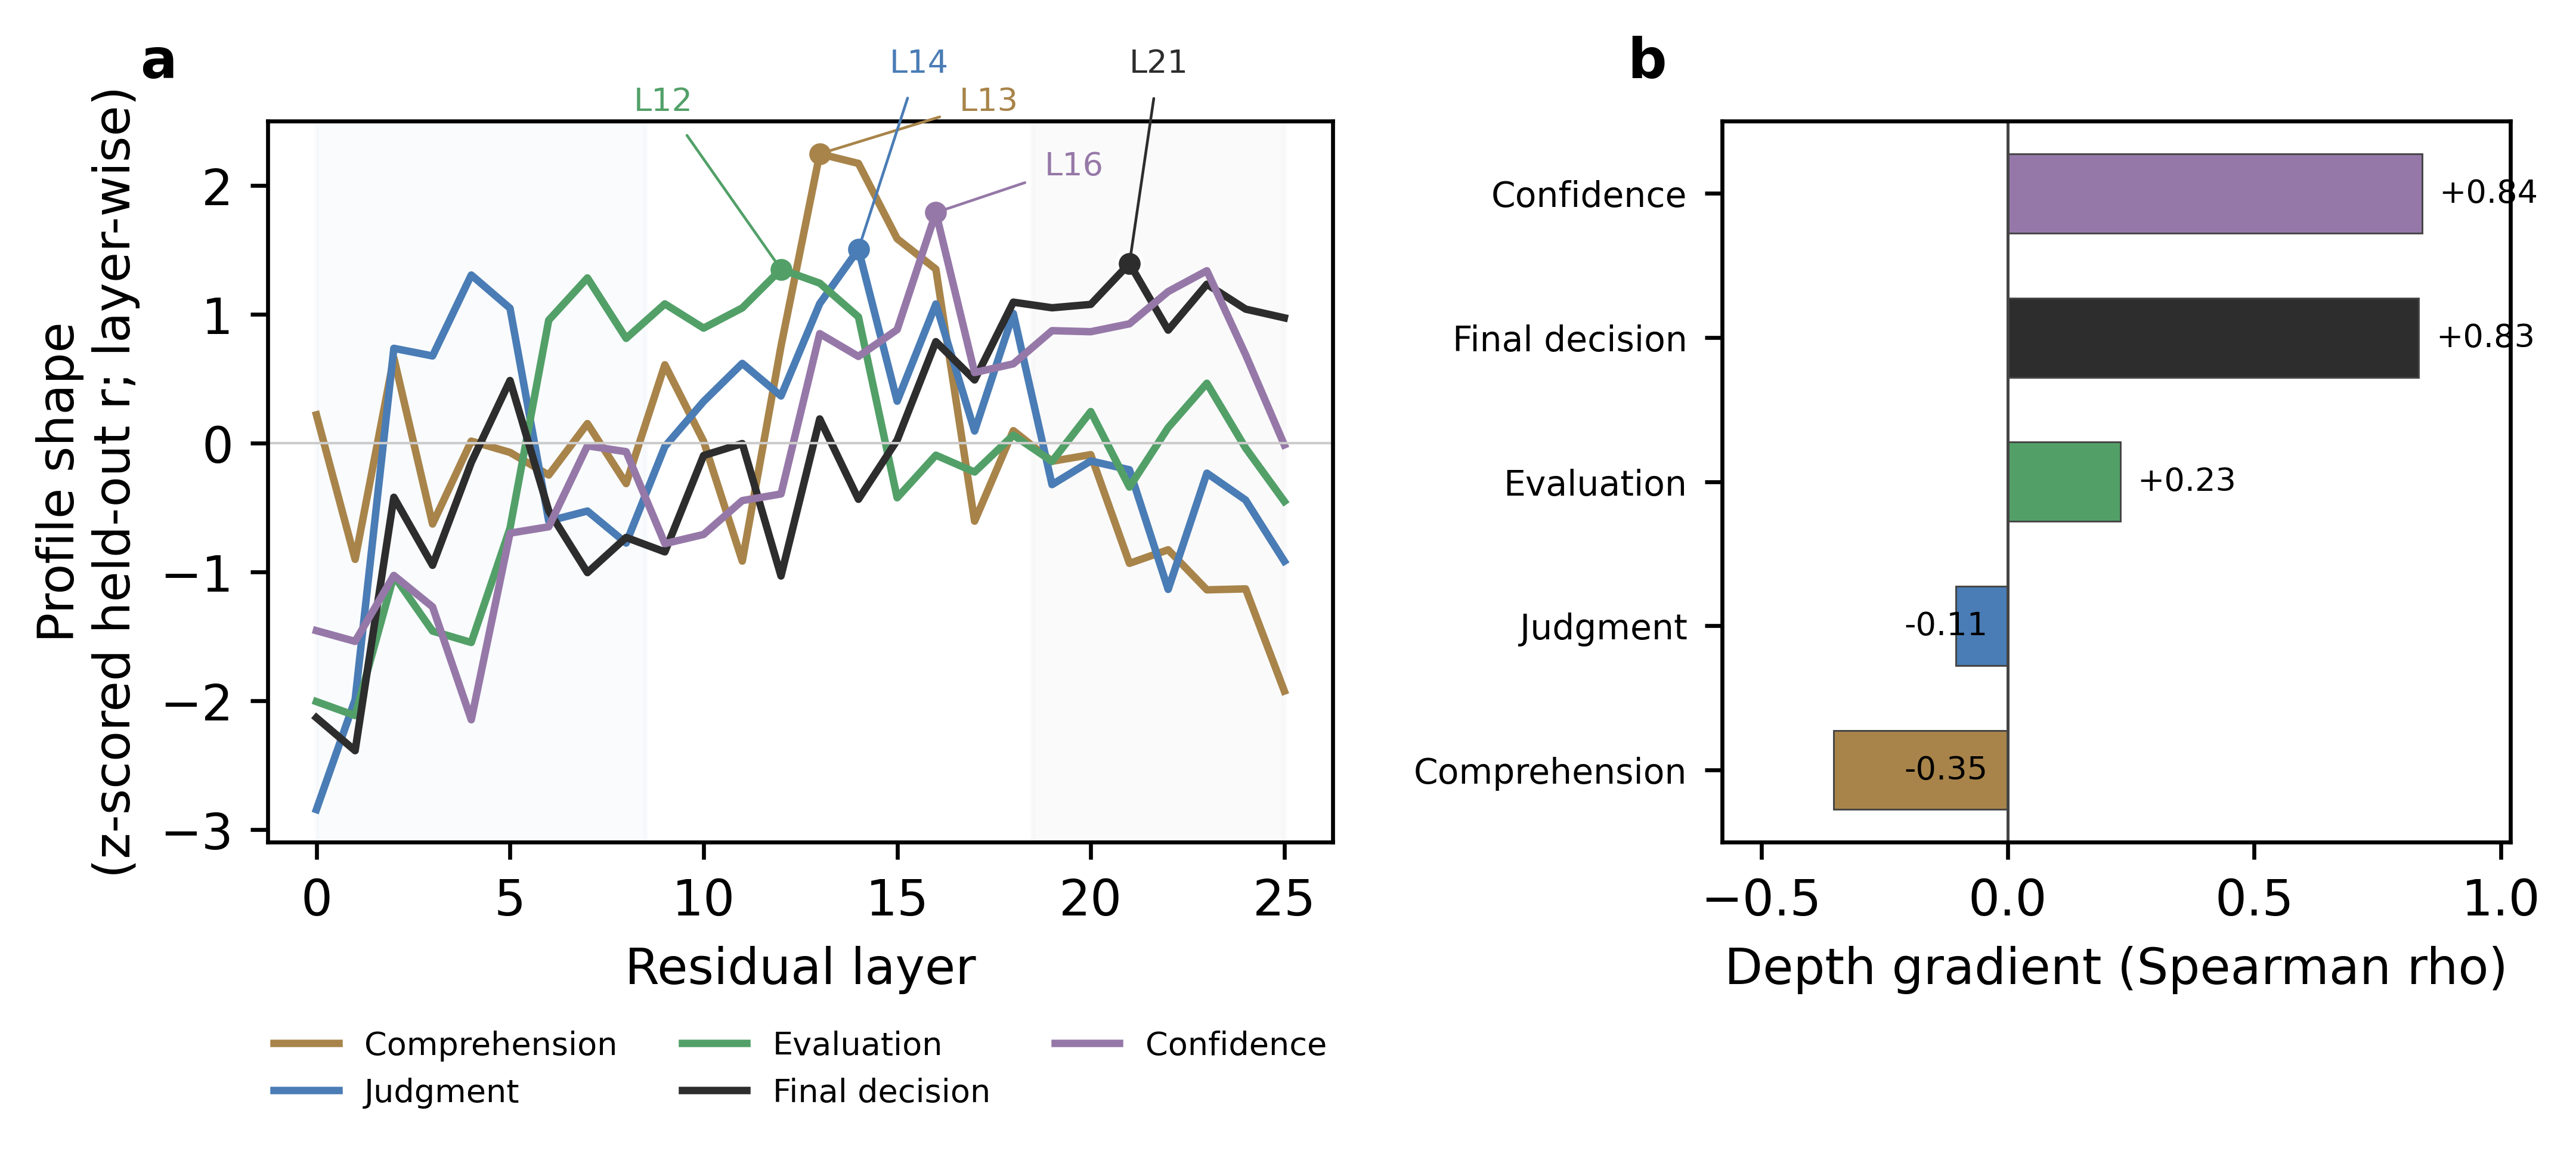

In [13]:
# --- Draw and save Figure 1 (Panels A and B) ---
MAXIMUM_LABEL_SLOTS = {
    "evaluation_continuous": (8.2, 2.58),
    "judgment_continuous": (14.8, 2.88),
    "comprehension_continuous": (16.6, 2.58),
    "confidence_continuous": (18.8, 2.08),
    "final_decision_continuous": (21.0, 2.88),
}

maximum_layer_by_dimension = encoding_maxima.set_index("dimension")["observed_max_layer"].to_dict()
layer_to_idx = {layer: i for i, layer in enumerate(layers)}

fig, (ax_a, ax_b) = plt.subplots(  # create 1×2 figure with two axes
    1, 2,  # one row, two columns
    figsize=(183 * MM, 80 * MM),  # Nature-style width/height in inches
    gridspec_kw={"width_ratios": [1.35, 1.0], "wspace": 0.42},  # panel (a) slightly wider
)  # end subplots call
fig.subplots_adjust(left=0.10, right=0.97, top=0.94, bottom=0.30)  # leave room for legend below (a)

# ----- Panel (a): profile shape -----
all_z = []  # collect all z values (unused but kept for possible y-limit tuning)
for dim in MP_DIMS:  # plot each of the five rubric dimensions
    rs = mat[mat.dimension == dim].sort_values("layer")["r"].to_numpy(dtype=float)  # raw r profile
    zs = zscore_within(rs)  # z-scored profile for shape comparison
    all_z.extend(zs)  # append to list

    ax_a.plot(layers, zs, color=COLORS[dim], linewidth=1.5, label=LABELS[dim])  # depth profile line

    maximum_layer = int(maximum_layer_by_dimension[dim])
    maximum_z = float(zs[layer_to_idx[maximum_layer]])
    ax_a.scatter(
        [maximum_layer], [maximum_z], s=26, color=COLORS[dim],
        edgecolors="white", linewidths=0.7,
    )

    tx, ty = MAXIMUM_LABEL_SLOTS[dim]
    ax_a.annotate(
        f"L{maximum_layer}",
        xy=(maximum_layer, maximum_z),
        xytext=(tx, ty),
        fontsize=6.5,  # small annotation font
        color=COLORS[dim],  # match dimension colour
        arrowprops={"arrowstyle": "-", "color": COLORS[dim], "lw": 0.55},  # thin connector
    )  # end annotate call

ax_a.axvspan(0, 8.5, color="#eef4fa", alpha=0.35, zorder=0)  # shade early layers
ax_a.axvspan(18.5, 25, color="#f5f5f5", alpha=0.45, zorder=0)  # shade late layers
ax_a.axhline(0, color="#cccccc", linewidth=0.5)  # horizontal reference at z=0
ax_a.set_xlabel("Residual layer")  # x-axis label
ax_a.set_ylabel("Profile shape\n(z-scored held-out r; layer-wise)")  # y-axis label
ax_a.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False, fontsize=6.5)  # legend below panel
ax_a.text(-0.12, 1.06, "a", transform=ax_a.transAxes, fontsize=11, fontweight="bold")  # panel tag

# ----- Panel (b): depth gradient -----
plot_grad = grad[grad.dimension.isin(MP_DIMS)].sort_values("rho", ascending=True)  # five rubrics, low→high
y_pos = np.arange(len(plot_grad))  # bar positions 0..4

ax_b.barh(  # horizontal bars for Spearman rho
    y_pos,  # bar y positions
    plot_grad["rho"],  # bar lengths = depth gradients
    color=[COLORS[d] for d in plot_grad["dimension"]],  # match dimension colours
    edgecolor="#444444",  # thin bar outline
    linewidth=0.35,  # outline width
    height=0.55,  # bar thickness
)  # end barh call
ax_b.axvline(0, color="#444444", linewidth=0.6)  # vertical zero reference

for i, row in enumerate(plot_grad.itertuples()):  # annotate each bar with rho value
    x_text = row.rho + 0.035 if row.rho >= 0 else -0.04  # place text just right/left of bar end
    ha = "left" if row.rho >= 0 else "right"  # text alignment depends on sign
    ax_b.text(x_text, i, f"{row.rho:+.2f}", va="center", ha=ha, fontsize=6.5)  # formatted rho label

ax_b.set_yticks(y_pos)  # tick positions
ax_b.set_yticklabels(plot_grad["label"], fontsize=7)  # dimension names on y-axis
ax_b.set_xlim(-0.58, 1.02)  # x-axis limits with padding for labels
ax_b.set_xlabel("Depth gradient (Spearman rho)")  # x-axis label
ax_b.text(-0.12, 1.06, "b", transform=ax_b.transAxes, fontsize=11, fontweight="bold")  # panel tag

fig.savefig(FIG_PATH, dpi=600, bbox_inches="tight", facecolor="white")  # save high-res PNG
plt.close(fig)  # free memory
print("Saved:", FIG_PATH)  # confirm output path

try:  # optional inline preview in Jupyter
    from IPython.display import Image, display  # Jupyter display utilities
    display(Image(filename=str(FIG_PATH)))  # show saved figure in notebook output
except ImportError:  # running outside Jupyter
    pass  # skip preview if IPython is unavailable


---

# Figure 1 uncertainty and inference

## Uncertainty in the observed encoding maxima

An observed argmax is not a precise estimate of where encoding is strongest. We resample participants 5,000 times, recompute the held-out correlation at all 26 layers, and record the maximizing layer in every draw. This yields a full participant-bootstrap distribution for each dimension. Judgment and Comprehension have adjacent observed maxima (L14 and L13, respectively), and overlapping intervals are not interpreted as evidence of distinct computational stages.

**Outputs:** draw-level distributions, a five-row uncertainty summary, and an appendix figure.

In [14]:
# Retain participant-level OOF predictions for encoding-maximum bootstrapping.
FIG1_OUTPUT_DIR = DATA_DIR

N_MAXIMUM_BOOTSTRAP = 5000
ANALYSIS_SEED = 17
RUBRIC_DIMS = MP_DIMS.copy()
DECLARED_FAMILY_SIZE = len(RUBRIC_DIMS) * len(layers)

rubric_oof = {
    (dim, layer): layer_oof[(dim, layer)]
    for dim in RUBRIC_DIMS
    for layer in layers
}
assert len(rubric_oof) == DECLARED_FAMILY_SIZE
assert all(pred.shape == (len(df),) for pred in rubric_oof.values())
print(f"Retained {len(rubric_oof)} rubric OOF vectors from the encoding scan.")

Retained 130 rubric OOF vectors from the encoding scan.


In [15]:
# Resample participants and reselect the maximizing layer.
oof_by_dimension = {
    dim: np.column_stack([layer_oof[(dim, layer)] for layer in layers])
    for dim in RUBRIC_DIMS
}
rng = np.random.default_rng(ANALYSIS_SEED)
records = []

for boot_id in range(N_MAXIMUM_BOOTSTRAP):
    idx = rng.integers(0, len(df), len(df))
    for dim in RUBRIC_DIMS:
        y = y_res[dim][idx]
        pred = oof_by_dimension[dim][idx]
        y0 = y - y.mean()
        pred0 = pred - pred.mean(axis=0)
        r = (y0 @ pred0) / np.sqrt((y0 @ y0) * np.sum(pred0 ** 2, axis=0))
        maximizing_index = int(np.argmax(r))
        records.append({
            "bootstrap_draw": boot_id,
            "dimension": dim,
            "label": LABELS[dim],
            "maximizing_layer": int(layers[maximizing_index]),
            "maximum_r": float(r[maximizing_index]),
            "depth_gradient": float(spearmanr(layers, r).statistic),
        })

maximum_draws = pd.DataFrame(records)
maximum_uncertainty = (
    maximum_draws.groupby(["dimension", "label"], sort=False)["maximizing_layer"]
    .agg(
        bootstrap_maximum_mean="mean",
        bootstrap_ci_low=lambda x: np.percentile(x, 2.5),
        bootstrap_ci_high=lambda x: np.percentile(x, 97.5),
    )
    .reset_index()
)
observed_maxima = encoding_maxima[
    encoding_maxima.dimension.isin(RUBRIC_DIMS)
][["dimension", "observed_max_layer", "observed_max_r"]]
maximum_uncertainty = observed_maxima.merge(
    maximum_uncertainty, on="dimension", validate="one_to_one"
)
maximum_uncertainty["n_bootstrap"] = N_MAXIMUM_BOOTSTRAP

maximum_draws.to_csv(
    FIG1_OUTPUT_DIR / "figure1_encoding_maxima_bootstrap_draws.csv", index=False
)
maximum_uncertainty.to_csv(
    FIG1_OUTPUT_DIR / "figure1_encoding_maxima_uncertainty_summary.csv", index=False
)
display(maximum_uncertainty.sort_values("observed_max_layer").round(3))

,dimension,observed_max_layer,observed_max_r,label,bootstrap_maximum_mean,bootstrap_ci_low,bootstrap_ci_high,n_bootstrap
2,evaluation_continuous,12,0.579,Evaluation,10.685,6.0,23.0,5000
0,comprehension_continuous,13,0.509,Comprehension,11.977,0.0,16.0,5000
1,judgment_continuous,14,0.678,Judgment,10.031,2.0,18.0,5000
4,confidence_continuous,16,0.431,Confidence,17.390,15.0,23.0,5000
3,final_decision_continuous,21,0.620,Final decision,19.655,5.0,25.0,5000


## Multiplicity across the probing grid

Figure 1 evaluates 26 layers for each of five dimensions, creating a declared family of 130 estimates. We apply Benjamini–Hochberg FDR across all 130 Pearson-correlation approximations and export the complete table. Because tuned out-of-fold predictions are not fixed predictors, these adjusted values are explicitly exploratory; observed encoding maxima remain descriptive.

In [16]:
# BH-FDR across the declared 5 × 26 exploratory family.
from scipy.stats import t as student_t

family_inference = (
    mat[mat.dimension.isin(RUBRIC_DIMS)]
    .sort_values(["dimension", "layer"])
    .reset_index(drop=True)
    .copy()
)
assert len(family_inference) == DECLARED_FAMILY_SIZE

r = family_inference["r"].to_numpy(float)
df_r = len(df) - 2
t_stat = r * np.sqrt(df_r / np.maximum(1 - r ** 2, np.finfo(float).tiny))
p_raw = 2 * student_t.sf(np.abs(t_stat), df=df_r)

order = np.argsort(p_raw)
ranked_q = p_raw[order] * len(p_raw) / np.arange(1, len(p_raw) + 1)
ranked_q = np.minimum.accumulate(ranked_q[::-1])[::-1]
q_bh = np.empty_like(ranked_q)
q_bh[order] = np.clip(ranked_q, 0, 1)

family_inference["p_pearson_approx"] = p_raw
family_inference["q_bh_fdr_130_approx"] = q_bh
family_inference["reject_bh_fdr_05"] = q_bh <= .05
family_inference["inference_status"] = "exploratory Pearson approximation"
family_inference.to_csv(
    FIG1_OUTPUT_DIR / "figure1_layer_dimension_inference_bh_fdr_130.csv", index=False
)
display(family_inference)

,dimension,label,layer,r,alpha_fold_1,alpha_fold_2,alpha_fold_3,alpha_fold_4,alpha_fold_5,p_pearson_approx,q_bh_fdr_130_approx,reject_bh_fdr_05,inference_status
0,comprehension_continuous,Comprehension,0,0.459475,0.1,0.1,0.1,0.1,0.1,9.349368e-27,1.413277e-26,True,exploratory Pearson approximation
1,comprehension_continuous,Comprehension,1,0.432265,0.1,0.1,0.1,0.1,0.1,1.516012e-23,1.990723e-23,True,exploratory Pearson approximation
2,comprehension_continuous,Comprehension,2,0.470206,0.1,0.1,0.1,0.1,0.1,4.200297e-28,6.578778e-28,True,exploratory Pearson approximation
3,comprehension_continuous,Comprehension,3,0.438923,0.1,0.1,0.1,0.1,0.1,2.641278e-24,3.539857e-24,True,exploratory Pearson approximation
4,comprehension_continuous,Comprehension,4,0.454525,0.1,0.1,0.1,0.1,0.1,3.770398e-26,5.483351e-26,True,exploratory Pearson approximation
...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,judgment_continuous,Judgment,21,0.637063,0.1,0.1,0.1,0.1,0.1,1.088489e-56,8.843976e-56,True,exploratory Pearson approximation
126,judgment_continuous,Judgment,22,0.614939,0.1,0.1,0.1,0.1,0.1,6.934261e-52,3.467130e-51,True,exploratory Pearson approximation
127,judgment_continuous,Judgment,23,0.636436,0.1,0.1,0.1,0.1,0.1,1.507716e-56,1.152959e-55,True,exploratory Pearson approximation
128,judgment_continuous,Judgment,24,0.631464,0.1,0.1,0.1,0.1,0.1,1.947695e-55,1.332634e-54,True,exploratory Pearson approximation


## Alignment with the prespecified MP order

Shared observed maxima do not establish five discrete representational stages. The depth-gradient panel instead tests whether profile shape follows the prespecified progression from local comprehension to integrative commitment. We use an exact ordered-trend test, participant-bootstrap stability, and a rank-based sensitivity analysis. The result is interpreted as descriptive alignment with the prespecified order.

In [17]:
# Test depth-gradient alignment with the prespecified MP order.
from itertools import permutations

MP_HIERARCHY_ORDER = [
    "comprehension_continuous", "judgment_continuous", "evaluation_continuous",
    "final_decision_continuous", "confidence_continuous",
]
ranks = np.arange(1, 6)
gradients = np.array([
    grad.loc[grad.dimension == dim, "rho"].iloc[0] for dim in MP_HIERARCHY_ORDER
])

# Primary test: linear trend in depth gradients across the ordered rubric stages.
hierarchy_r = float(pearsonr(ranks, gradients).statistic)
null_r = np.array([pearsonr(order, gradients).statistic for order in permutations(ranks)])
hierarchy_p = float(np.mean(np.abs(null_r) >= abs(hierarchy_r) - 1e-12))

# Rank-based sensitivity analysis and participant-bootstrap stability.
hierarchy_rho = float(spearmanr(ranks, gradients).statistic)
null_rho = np.array([spearmanr(order, gradients).statistic for order in permutations(ranks)])
hierarchy_rho_p = float(np.mean(np.abs(null_rho) >= abs(hierarchy_rho) - 1e-12))
boot_gradients = maximum_draws.pivot(
    index="bootstrap_draw", columns="dimension", values="depth_gradient"
)[MP_HIERARCHY_ORDER].to_numpy()
boot_r = np.array([pearsonr(ranks, row).statistic for row in boot_gradients])
ci_low, ci_high = np.percentile(boot_r, [2.5, 97.5])

hierarchy_summary = pd.DataFrame([{
    "ordered_linear_r": hierarchy_r,
    "exact_two_sided_p": hierarchy_p,
    "bootstrap_ci_low": ci_low,
    "bootstrap_ci_high": ci_high,
    "bootstrap_positive_fraction": np.mean(boot_r > 0),
    "spearman_rho_sensitivity": hierarchy_rho,
    "spearman_exact_two_sided_p": hierarchy_rho_p,
    "n_bootstrap": N_MAXIMUM_BOOTSTRAP,
}])
hierarchy_summary.to_csv(
    FIG1_OUTPUT_DIR / "figure1_depth_gradient_hierarchy_alignment.csv", index=False
)
display(hierarchy_summary)

,ordered_linear_r,exact_two_sided_p,bootstrap_ci_low,bootstrap_ci_high,bootstrap_positive_fraction,spearman_rho_sensitivity,spearman_exact_two_sided_p,n_bootstrap
0,0.97147,0.016667,0.528808,0.99125,1.0,1.0,0.016667,5000


Saved: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\figures\fig1_appendix.png


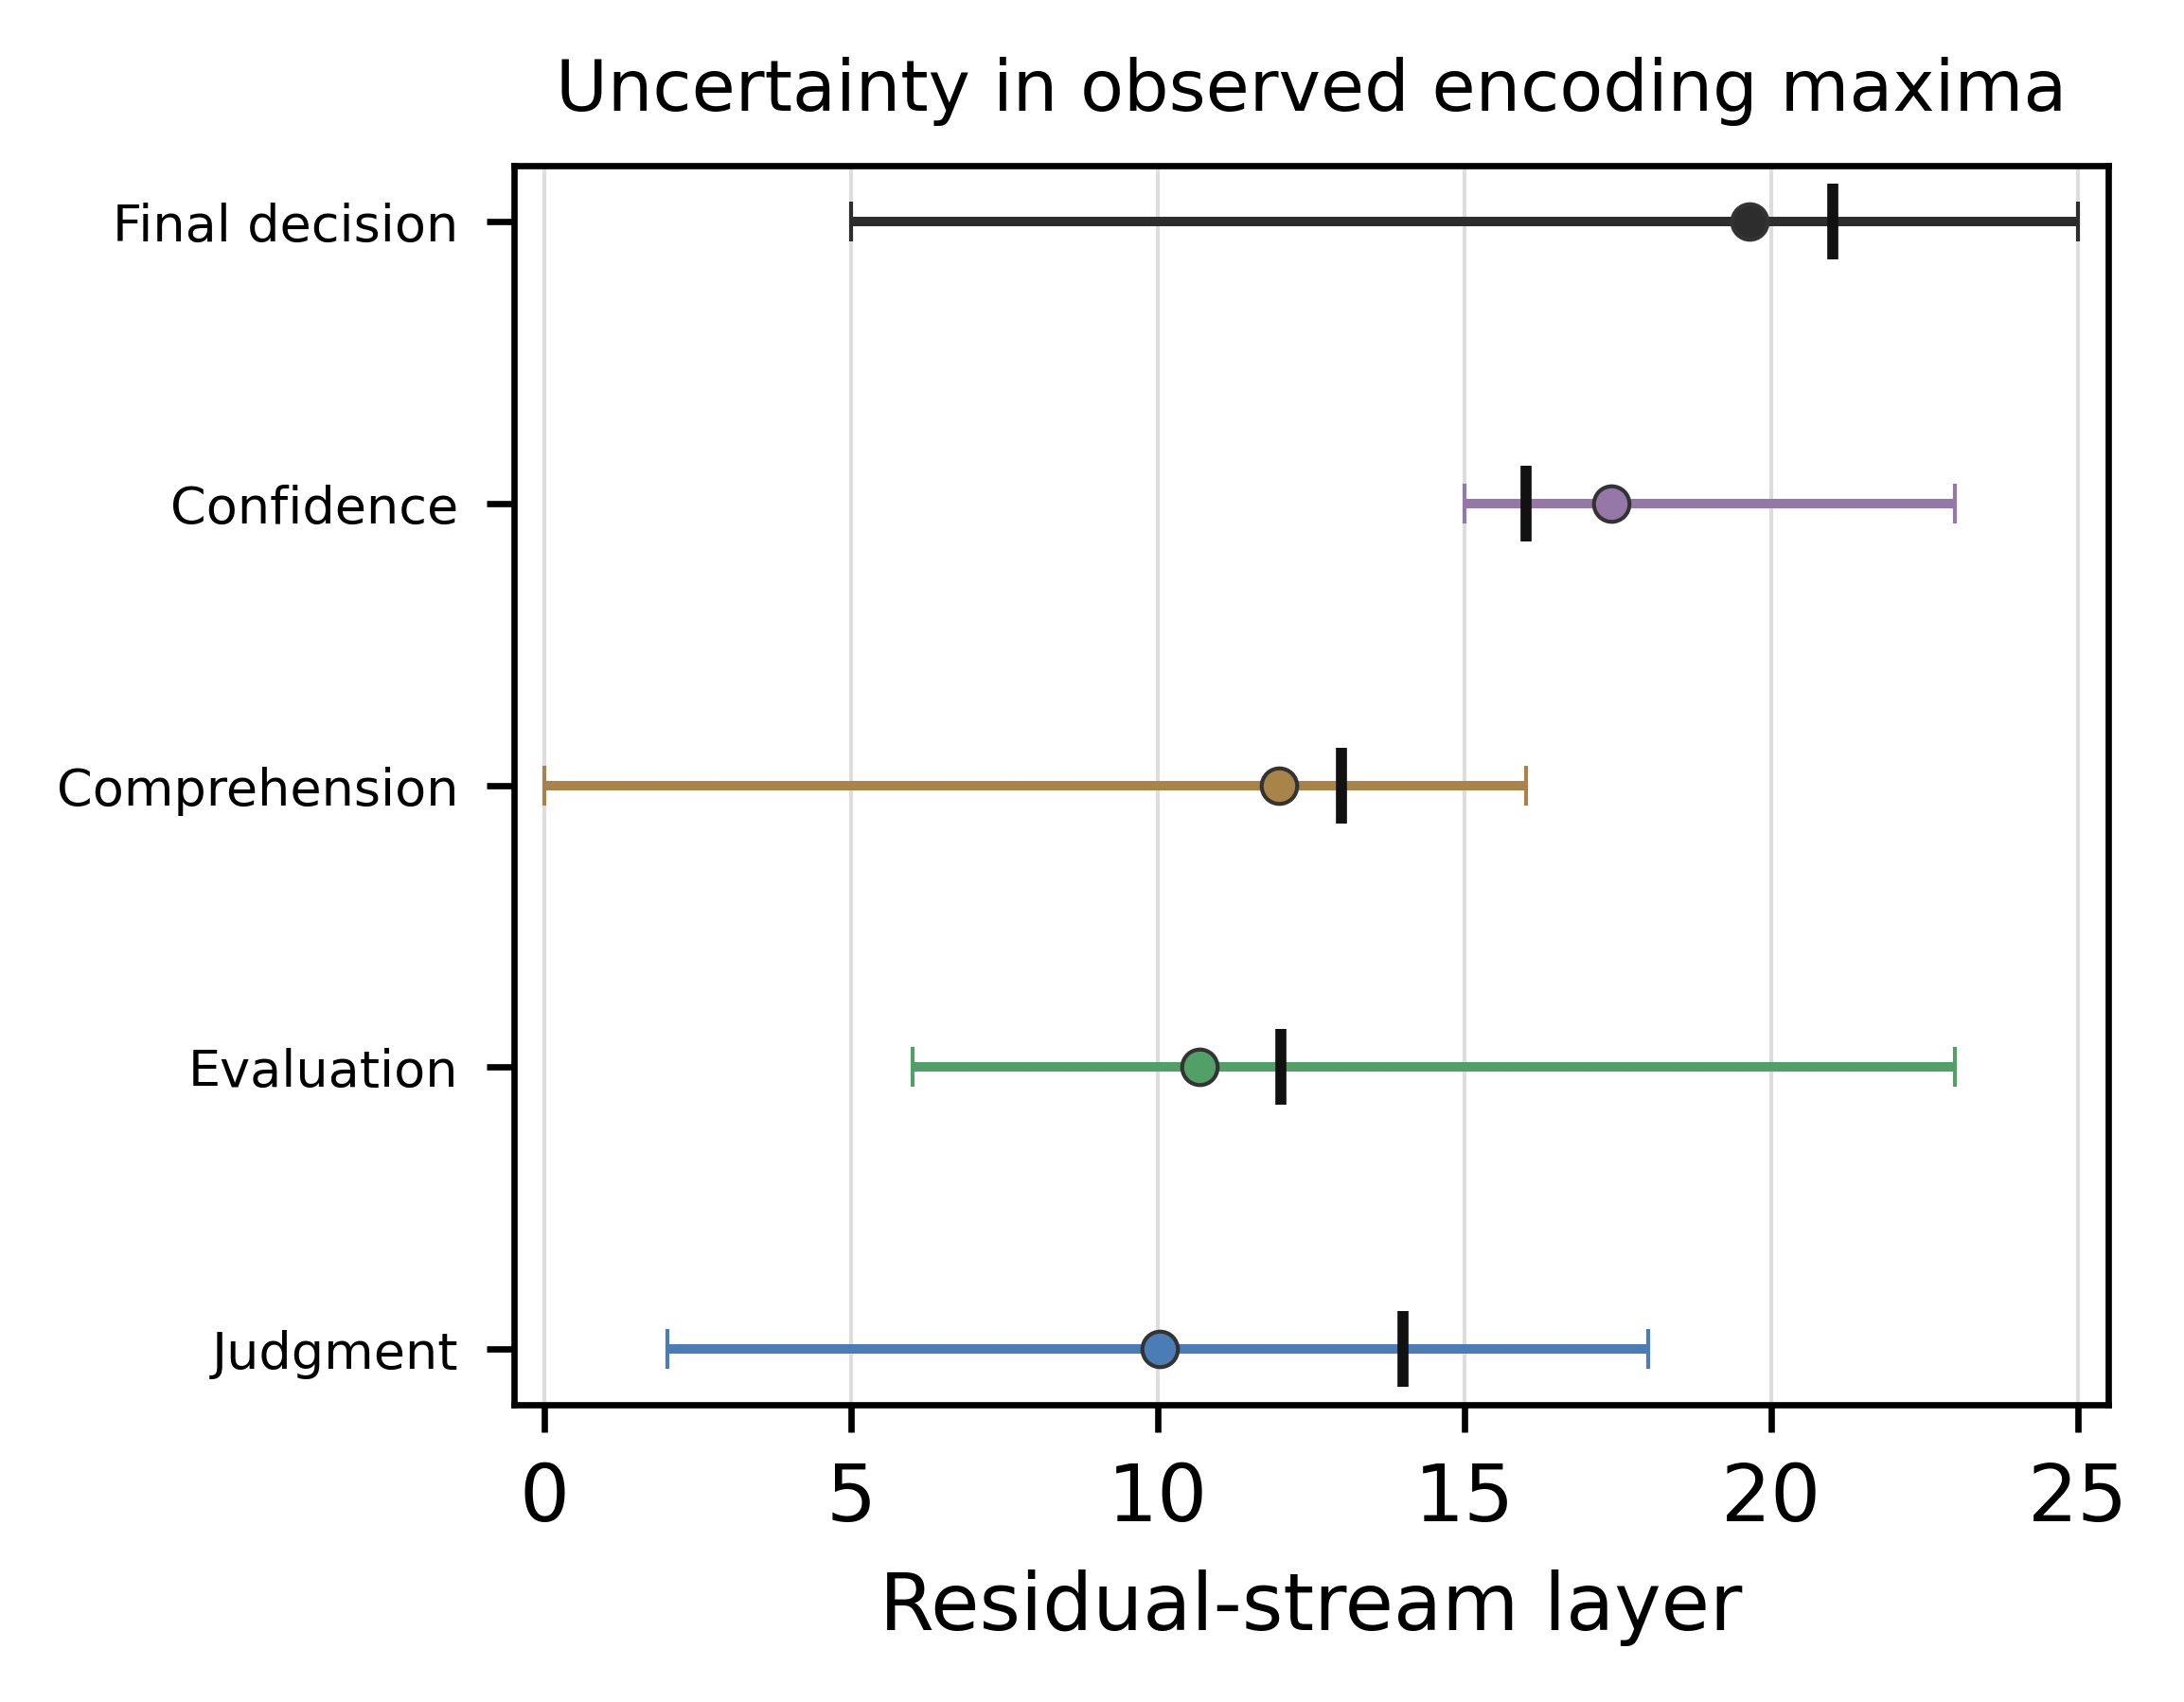

In [18]:
# Appendix figure — uncertainty in observed encoding maxima
APPENDIX_FIG_PNG = FIGURE_DIR / "fig1_appendix.png"
APPENDIX_FIG_PDF = FIGURE_DIR / "fig1_appendix.pdf"
fig_rev, ax_rc = plt.subplots(figsize=(92 * MM, 72 * MM))

# Circle = bootstrap mean; horizontal line = 95% interval; black tick = observed maximum.
maximum_plot = maximum_uncertainty.sort_values(
    "bootstrap_maximum_mean"
).reset_index(drop=True)
y_position = np.arange(len(maximum_plot))
x_error = np.vstack([
    maximum_plot["bootstrap_maximum_mean"] - maximum_plot["bootstrap_ci_low"],
    maximum_plot["bootstrap_ci_high"] - maximum_plot["bootstrap_maximum_mean"],
])

for row_number, row in maximum_plot.iterrows():
    color = COLORS[row.dimension]
    ax_rc.errorbar(
        row.bootstrap_maximum_mean, row_number,
        xerr=x_error[:, row_number:row_number + 1],
        fmt="o", markersize=4.5,
        color=color, markerfacecolor=color, markeredgecolor="#333333",
        markeredgewidth=0.5, ecolor=color, elinewidth=1.2, capsize=2.5,
        zorder=3,
    )
    ax_rc.scatter(
        row.observed_max_layer, row_number,
        marker="|", s=90, linewidths=1.4, color="#111111", zorder=4,
    )

ax_rc.set_yticks(y_position)
ax_rc.set_yticklabels(maximum_plot["label"], fontsize=6.5)
ax_rc.set_xlim(-0.5, 25.5)
ax_rc.set_xticks([0, 5, 10, 15, 20, 25])
ax_rc.set_xlabel("Residual-stream layer")
ax_rc.set_title("Uncertainty in observed encoding maxima", fontsize=9, pad=7)
ax_rc.grid(axis="x", color="#dddddd", linewidth=0.5, zorder=0)

fig_rev.savefig(APPENDIX_FIG_PNG, dpi=600, bbox_inches="tight", facecolor="white")
fig_rev.savefig(APPENDIX_FIG_PDF, bbox_inches="tight", facecolor="white")
plt.close(fig_rev)
print("Saved:", APPENDIX_FIG_PNG)
display(Image(filename=str(APPENDIX_FIG_PNG)))

## Figure 1 reported outputs

Observed encoding maxima, depth gradients, bootstrap intervals, ordered-trend statistics, and the declared 130-test family all remain linked to the computed objects above.

In [19]:
# Assemble the Figure 1 quantities used in reporting.
figure1_report = maximum_uncertainty.merge(
    grad[["dimension", "rho"]].rename(columns={"rho": "depth_gradient_rho"}),
    on="dimension",
    how="left",
)
figure1_report.to_csv(FIG1_OUTPUT_DIR / "figure1_reported_summary.csv", index=False)

figure1_hierarchy_report = pd.DataFrame({
    "quantity": [
        "declared_layer_dimension_family",
        "ordered_gradient_pearson_r",
        "ordered_gradient_exact_p",
        "ordered_gradient_bootstrap_ci_low",
        "ordered_gradient_bootstrap_ci_high",
        "ordered_gradient_spearman_rho",
        "ordered_gradient_spearman_exact_p",
        "ordered_gradient_bootstrap_positive_rate",
    ],
    "value": [
        DECLARED_FAMILY_SIZE,
        hierarchy_r,
        hierarchy_p,
        ci_low,
        ci_high,
        hierarchy_rho,
        hierarchy_rho_p,
        np.mean(boot_r > 0),
    ],
})
figure1_hierarchy_report.to_csv(
    FIG1_OUTPUT_DIR / "figure1_hierarchy_report.csv", index=False
)

display(figure1_report.round(4))
display(figure1_hierarchy_report.round(4))

,dimension,observed_max_layer,observed_max_r,label,bootstrap_maximum_mean,bootstrap_ci_low,bootstrap_ci_high,n_bootstrap,depth_gradient_rho
0,comprehension_continuous,13,0.5086,Comprehension,11.9774,0.0,16.0,5000,-0.3532
1,judgment_continuous,14,0.6778,Judgment,10.0306,2.0,18.0,5000,-0.1056
2,evaluation_continuous,12,0.5786,Evaluation,10.6850,6.0,23.0,5000,0.2280
3,final_decision_continuous,21,0.6199,Final decision,19.6548,5.0,25.0,5000,0.8332
4,confidence_continuous,16,0.4315,Confidence,17.3898,15.0,23.0,5000,0.8400


,quantity,value
0,declared_layer_dimension_family,130.0000
1,ordered_gradient_pearson_r,0.9715
2,ordered_gradient_exact_p,0.0167
3,ordered_gradient_bootstrap_ci_low,0.5288
4,ordered_gradient_bootstrap_ci_high,0.9912
5,ordered_gradient_spearman_rho,1.0000
6,ordered_gradient_spearman_exact_p,0.0167
7,ordered_gradient_bootstrap_positive_rate,1.0000


---

# Figure 2 — encoding and task-marker coupling

This section relates rubric readouts at their observed maximizing layers to two independently measured task markers: the initial volatility prior and win-switch rate. It reports all ten signed marker-specific associations, quantifies score overlap and cross-dimension probe transfer, and draws the manuscript figure from the resulting task-marker coupling estimates.

In [20]:
# Figure 2 paths and independently measured task-marker definitions.
FIG2_DIR = DATA_DIR
FIG2_MARKERS = {
    "Belief volatility": "mu03_avg",
    "Win-switch rate": "wsr_avg",
}

missing_markers = [column for column in FIG2_MARKERS.values() if column not in df]
if missing_markers:
    raise KeyError(f"Missing Figure 2 marker columns: {missing_markers}")
print("Figure 2 markers:", FIG2_MARKERS)

Figure 2 markers: {'Belief volatility': 'mu03_avg', 'Win-switch rate': 'wsr_avg'}


In [21]:
# Descriptive distributions of the two task markers.
figure2_marker_descriptives = pd.DataFrame([
    {
        "marker": marker,
        "column": column,
        "n": int(df[column].notna().sum()),
        "mean": df[column].mean(),
        "sd": df[column].std(ddof=1),
        "min": df[column].min(),
        "max": df[column].max(),
    }
    for marker, column in FIG2_MARKERS.items()
])
figure2_marker_descriptives.to_csv(
    FIG2_DIR / "figure2_marker_descriptives.csv", index=False
)
display(figure2_marker_descriptives.round(4))

,marker,column,n,mean,sd,min,max
0,Belief volatility,mu03_avg,486,-0.6662,1.3361,-4.1297,2.4625
1,Win-switch rate,wsr_avg,486,0.0958,0.1654,0.0000,0.9896


## Reuse the Figure 1 out-of-fold predictions

Both Figure 2 coordinates use the exact participant-level out-of-fold predictions generated for Figure 1. This keeps held-out encoding and task-marker coupling on one internally consistent readout definition.

In [22]:
# Retrieve the OOF prediction at each dimension's observed encoding maximum.
maximum_oof = {
    dim: layer_oof[
        (dim, int(encoding_maxima.loc[
            encoding_maxima.dimension == dim, "observed_max_layer"
        ].iloc[0]))
    ]
    for dim in MP_DIMS
}
figure2_oof_check = pd.DataFrame([
    {
        "dimension": dim,
        "observed_max_layer": int(encoding_maxima.loc[
            encoding_maxima.dimension == dim, "observed_max_layer"
        ].iloc[0]),
        "encoding_r": pearsonr(maximum_oof[dim], y_res[dim]).statistic,
    }
    for dim in MP_DIMS
])
display(figure2_oof_check.round(4))

,dimension,observed_max_layer,encoding_r
0,comprehension_continuous,13,0.5086
1,judgment_continuous,14,0.6778
2,evaluation_continuous,12,0.5786
3,final_decision_continuous,21,0.6199
4,confidence_continuous,16,0.4315


## Figure 2 inferential analyses

The following cells quantify overlap, transfer, marker-specific associations, and rank stability. The manuscript panel is drawn only after these internally consistent quantities have been assembled.

---

## Score overlap and cross-dimension probe transfer

Correlated rubric scores or cross-dimensional probe transfer could create apparent dimension structure. We therefore report complete raw and length-residualized score-correlation matrices, a cross-dimensional out-of-fold transfer matrix, and each probe's matched-target advantage over its strongest off-target correlation.

,matrix,mean_abs_off_diagonal
0,Raw scores,0.837
1,Length-residualized scores,0.495
2,OOF probe transfer,0.325


,dimension,label,matched_r,strongest_off_target_abs_r,matched_target_advantage
0,comprehension_continuous,Comprehension,0.509,0.552,-0.043
1,judgment_continuous,Judgment,0.678,0.560,0.118
2,evaluation_continuous,Evaluation,0.579,0.361,0.218
3,final_decision_continuous,Final decision,0.620,0.570,0.050
4,confidence_continuous,Confidence,0.431,0.396,0.035


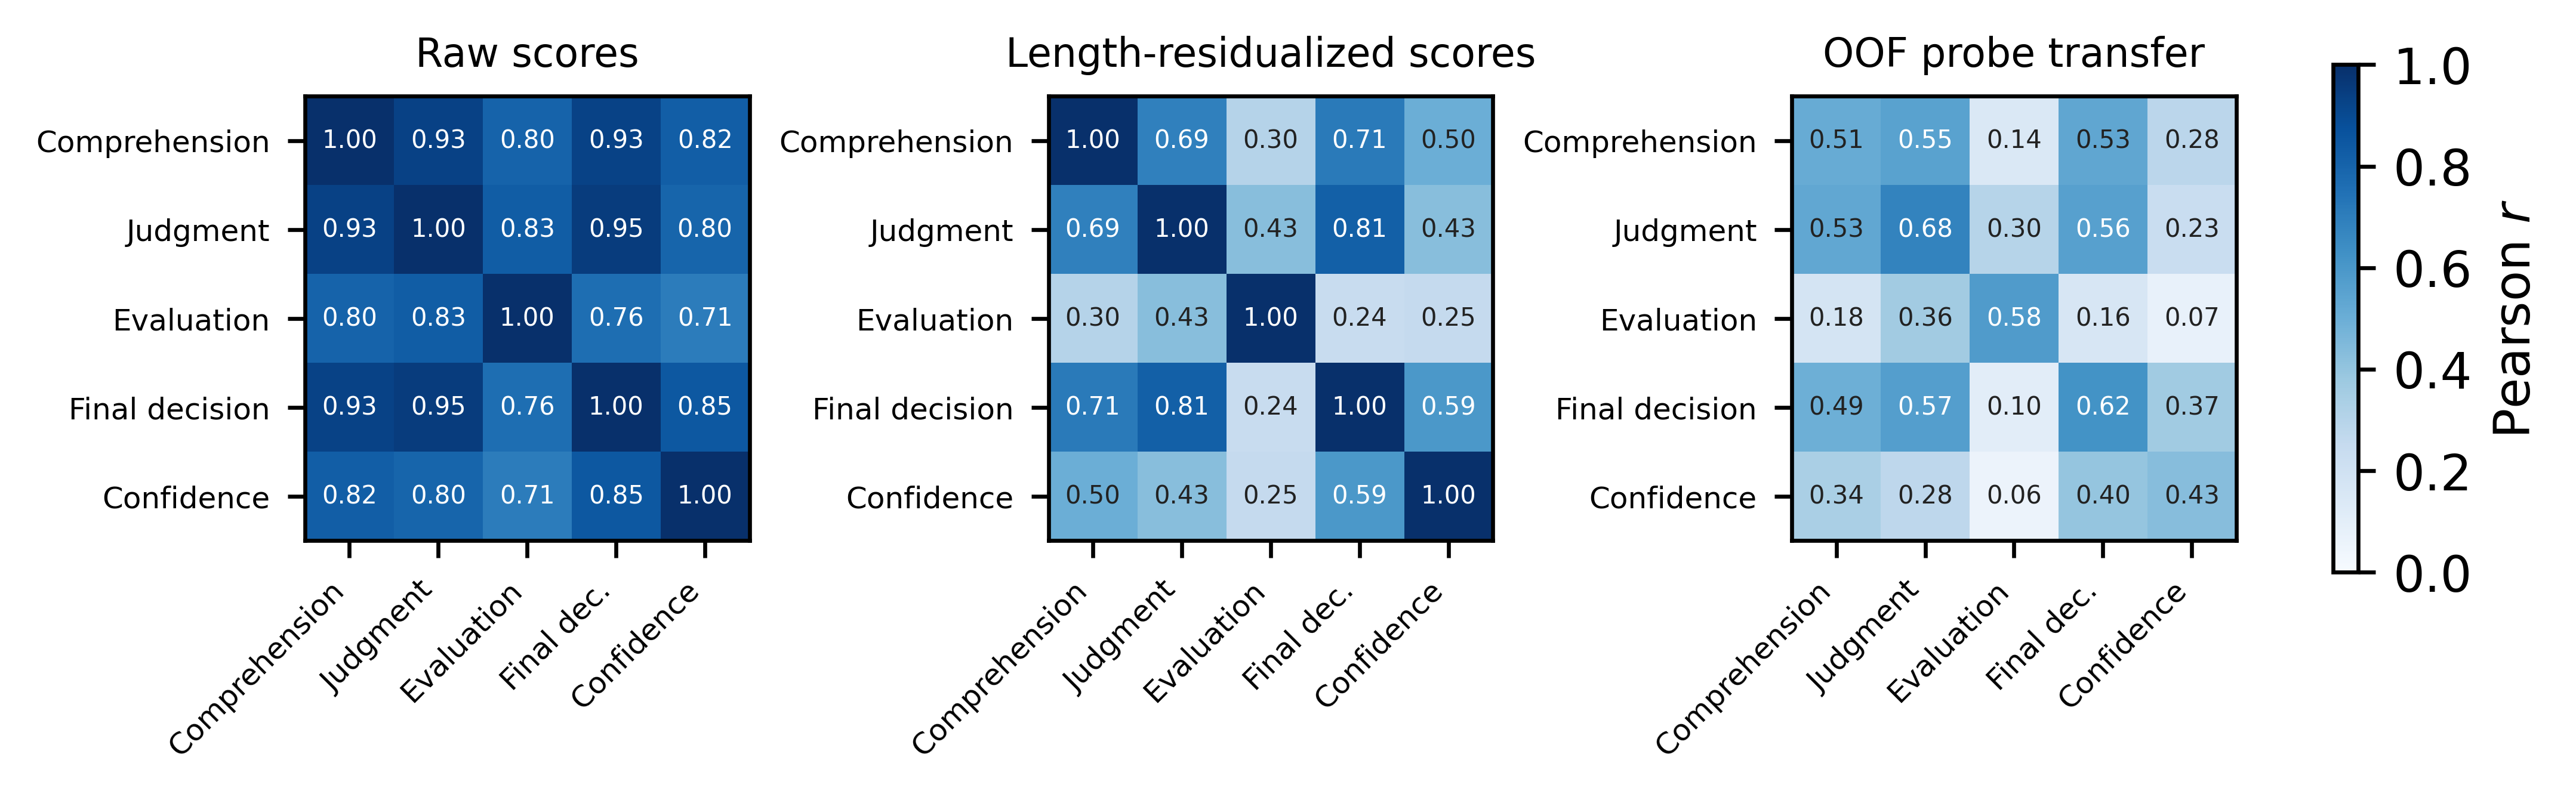

In [23]:
# Complete raw/residualized score correlations and OOF probe transfer.
fig2_labels = [LABELS[dim] for dim in MP_DIMS]
raw_score_corr = df[MP_DIMS].astype(float).corr()
residual_score_corr = pd.DataFrame(
    np.column_stack([y_res[dim] for dim in MP_DIMS]), columns=fig2_labels
).corr()
raw_score_corr.index = raw_score_corr.columns = fig2_labels

probe_transfer = pd.DataFrame(
    [[pearsonr(maximum_oof[source], y_res[target]).statistic for target in MP_DIMS]
     for source in MP_DIMS],
    index=fig2_labels, columns=fig2_labels,
)


def mean_abs_off_diagonal(matrix):
    values = matrix.to_numpy(float).copy()
    return float(np.mean(np.abs(values[~np.eye(len(values), dtype=bool)])))


transfer_specificity = []
for i, dim in enumerate(MP_DIMS):
    row = np.abs(probe_transfer.iloc[i].to_numpy())
    off_target_max = np.max(np.delete(row, i))
    transfer_specificity.append({
        "dimension": dim,
        "label": fig2_labels[i],
        "matched_r": probe_transfer.iloc[i, i],
        "strongest_off_target_abs_r": off_target_max,
        "matched_target_advantage": probe_transfer.iloc[i, i] - off_target_max,
    })
transfer_specificity = pd.DataFrame(transfer_specificity)

raw_score_corr.to_csv(FIG2_DIR / "figure2_score_correlations_raw.csv")
residual_score_corr.to_csv(FIG2_DIR / "figure2_score_correlations_length_residualized.csv")
probe_transfer.to_csv(FIG2_DIR / "figure2_oof_probe_transfer_matrix.csv")
transfer_specificity.to_csv(FIG2_DIR / "figure2_probe_specificity.csv", index=False)

matrix_summary = pd.DataFrame({
    "matrix": ["Raw scores", "Length-residualized scores", "OOF probe transfer"],
    "mean_abs_off_diagonal": [
        mean_abs_off_diagonal(raw_score_corr),
        mean_abs_off_diagonal(residual_score_corr),
        mean_abs_off_diagonal(probe_transfer),
    ],
})
display(matrix_summary.round(3))
display(transfer_specificity.round(3))

fig_m, axes = plt.subplots(1, 3, figsize=(180 * MM, 57 * MM), constrained_layout=True)
for ax, matrix, title in zip(
    axes,
    [raw_score_corr, residual_score_corr, probe_transfer],
    ["Raw scores", "Length-residualized scores", "OOF probe transfer"],
):
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks(range(5), [label.replace("Final decision", "Final dec.") for label in fig2_labels], rotation=45, ha="right", fontsize=6)
    ax.set_yticks(range(5), fig2_labels, fontsize=6)
    ax.set_title(title, fontsize=8)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=5,
                    color="white" if matrix.iloc[i, j] > .55 else "#222222")
fig_m.colorbar(image, ax=axes, shrink=.8, label="Pearson $r$")
MATRIX_FIG = FIGURE_DIR / "fig2_appendix.png"
fig_m.savefig(MATRIX_FIG, dpi=600, bbox_inches="tight", facecolor="white")
plt.close(fig_m)
display(Image(filename=str(MATRIX_FIG)))

## Marker-specific inference

The mean absolute coupling coordinate can conceal sign, marker differences, and multiplicity. We retain it only as the Figure 2 display coordinate and report all ten signed partial correlations with participant-bootstrap intervals and Holm familywise correction. BH-FDR is exported as a secondary analysis.

In [24]:
# Ten signed marker tests with familywise correction.
from scipy.stats import pearsonr

marker_residuals = {
    "Belief volatility": residualise(df["mu03_avg"].to_numpy(float), loglen),
    "Win-switch rate": residualise(df["wsr_avg"].to_numpy(float), loglen),
}
rng_q5 = np.random.default_rng(SEED)
q5_rows = []

for dim in MP_DIMS:
    readout = residualise(maximum_oof[dim], loglen)
    layer = int(encoding_maxima.loc[
        encoding_maxima.dimension == dim, "observed_max_layer"
    ].iloc[0])
    for marker, outcome in marker_residuals.items():
        result = pearsonr(readout, outcome)
        boot = np.empty(2000)
        for b in range(2000):
            idx = rng_q5.integers(0, len(df), len(df))
            boot[b] = pearsonr(readout[idx], outcome[idx]).statistic
        q5_rows.append({
            "dimension": dim, "label": LABELS[dim], "observed_max_layer": layer,
            "marker": marker, "partial_r": result.statistic,
            "ci95_low": np.percentile(boot, 2.5),
            "ci95_high": np.percentile(boot, 97.5),
            "p_raw_two_sided": result.pvalue,
        })

figure2_marker_tests = pd.DataFrame(q5_rows)
p = figure2_marker_tests["p_raw_two_sided"].to_numpy()
order = np.argsort(p)
holm_sorted = np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order])
bh_sorted = np.minimum.accumulate((p[order] * len(p) / np.arange(1, len(p) + 1))[::-1])[::-1]
figure2_marker_tests["p_holm_10_tests"] = np.empty_like(p)
figure2_marker_tests["p_bh_fdr_10_tests"] = np.empty_like(p)
figure2_marker_tests.loc[order, "p_holm_10_tests"] = np.minimum(holm_sorted, 1)
figure2_marker_tests.loc[order, "p_bh_fdr_10_tests"] = np.minimum(bh_sorted, 1)
figure2_marker_tests["reject_holm_05"] = figure2_marker_tests.p_holm_10_tests < .05

figure2_marker_tests.to_csv(FIG2_DIR / "figure2_marker_specific_inference.csv", index=False)
print("Holm-significant tests:", int(figure2_marker_tests.reject_holm_05.sum()), "/ 10")
display(figure2_marker_tests.round(4))

Holm-significant tests: 6 / 10


,dimension,label,observed_max_layer,marker,partial_r,ci95_low,ci95_high,p_raw_two_sided,p_holm_10_tests,p_bh_fdr_10_tests,reject_holm_05
0,comprehension_continuous,Comprehension,13,Belief volatility,-0.1127,-0.1965,-0.0184,0.0129,0.0517,0.0185,False
1,comprehension_continuous,Comprehension,13,Win-switch rate,-0.1925,-0.2663,-0.1111,0.0000,0.0002,0.0002,True
2,judgment_continuous,Judgment,14,Belief volatility,-0.1234,-0.2153,-0.0271,0.0064,0.0322,0.0107,True
3,judgment_continuous,Judgment,14,Win-switch rate,-0.1574,-0.2353,-0.0798,0.0005,0.0040,0.0016,True
4,evaluation_continuous,Evaluation,12,Belief volatility,-0.0626,-0.1563,0.0284,0.1680,0.3360,0.1867,False
5,evaluation_continuous,Evaluation,12,Win-switch rate,-0.0367,-0.1105,0.0441,0.4199,0.4199,0.4199,False
6,final_decision_continuous,Final decision,21,Belief volatility,-0.1425,-0.2307,-0.0462,0.0016,0.0114,0.0041,True
7,final_decision_continuous,Final decision,21,Win-switch rate,-0.1765,-0.2646,-0.0907,0.0001,0.0008,0.0005,True
8,confidence_continuous,Confidence,16,Belief volatility,-0.0987,-0.1826,-0.0083,0.0296,0.0887,0.0369,False
9,confidence_continuous,Confidence,16,Win-switch rate,-0.1384,-0.2112,-0.0654,0.0022,0.0133,0.0044,True


## Coupling magnitude and rank stability

We report exact coupling estimates and test the comparative claim directly: how often is Evaluation the lowest-coupling dimension under paired participant resampling?

In [25]:
# Corrected composite and bootstrap stability of Evaluation's rank.
figure2_coupling = (
    figure2_marker_tests.assign(abs_r=lambda table: table.partial_r.abs())
    .groupby(["dimension", "label", "observed_max_layer"], as_index=False)
    .agg(mean_abs_partial_r=("abs_r", "mean"))
    .merge(
        encoding_maxima[["dimension", "observed_max_r"]].rename(
            columns={"observed_max_r": "encoding_r"}
        ),
        on="dimension", validate="one_to_one",
    )
)

rng_rank = np.random.default_rng(SEED)
bootstrap_composite = np.empty((5000, len(MP_DIMS)))
for b in range(5000):
    idx = rng_rank.integers(0, len(df), len(df))
    for j, dim in enumerate(MP_DIMS):
        readout = residualise(maximum_oof[dim], loglen)
        bootstrap_composite[b, j] = np.mean([
            abs(pearsonr(readout[idx], marker[idx]).statistic)
            for marker in marker_residuals.values()
        ])

evaluation_index = MP_DIMS.index("evaluation_continuous")
evaluation_is_lowest = float(np.mean(np.argmin(bootstrap_composite, axis=1) == evaluation_index))
rank_rows = []
for j, dim in enumerate(MP_DIMS):
    if j == evaluation_index:
        continue
    difference = bootstrap_composite[:, j] - bootstrap_composite[:, evaluation_index]
    rank_rows.append({
        "comparison": f"{LABELS[dim]} minus Evaluation",
        "mean_difference": difference.mean(),
        "ci95_low": np.percentile(difference, 2.5),
        "ci95_high": np.percentile(difference, 97.5),
        "probability_positive": np.mean(difference > 0),
    })
figure2_rank_stability = pd.DataFrame(rank_rows)
figure2_coupling.to_csv(FIG2_DIR / "figure2_encoding_task_marker_coupling.csv", index=False)
figure2_rank_stability.to_csv(FIG2_DIR / "figure2_evaluation_rank_stability.csv", index=False)

print(f"Evaluation is the lowest-coupling dimension in {evaluation_is_lowest:.1%} of bootstrap draws.")
display(figure2_coupling.round(3))
display(figure2_rank_stability.round(3))

Evaluation is the lowest-coupling dimension in 91.7% of bootstrap draws.


,dimension,label,observed_max_layer,mean_abs_partial_r,encoding_r
0,comprehension_continuous,Comprehension,13,0.153,0.509
1,confidence_continuous,Confidence,16,0.119,0.431
2,evaluation_continuous,Evaluation,12,0.050,0.579
3,final_decision_continuous,Final decision,21,0.159,0.620
4,judgment_continuous,Judgment,14,0.140,0.678


,comparison,mean_difference,ci95_low,ci95_high,probability_positive
0,Comprehension minus Evaluation,0.097,0.019,0.173,0.991
1,Judgment minus Evaluation,0.085,0.010,0.159,0.986
2,Final decision minus Evaluation,0.104,0.010,0.190,0.987
3,Confidence minus Evaluation,0.063,-0.024,0.141,0.929


## Cross-model recovery and construct validity

Predicting GPT-4 scores from Gemma activations does not, by itself, prove that the dimensions are psychologically valid or scorer-independent. Cross-model recovery establishes that GPT-4 targets are readable in Gemma's geometry. The matrices above quantify shared structure; replication with human ratings or alternative scorers is required for construct validity.

In [26]:
# Summarize overlap without converting it into a validity claim.
evaluation_specificity = transfer_specificity.loc[
    transfer_specificity.dimension == "evaluation_continuous"
].iloc[0]
figure2_w5_summary = pd.DataFrame([{
    "raw_score_mean_abs_off_diagonal": mean_abs_off_diagonal(raw_score_corr),
    "residual_score_mean_abs_off_diagonal": mean_abs_off_diagonal(residual_score_corr),
    "probe_transfer_mean_abs_off_diagonal": mean_abs_off_diagonal(probe_transfer),
    "evaluation_matched_target_r": evaluation_specificity.matched_r,
    "evaluation_strongest_off_target_abs_r": evaluation_specificity.strongest_off_target_abs_r,
    "evaluation_matched_target_advantage": evaluation_specificity.matched_target_advantage,
    "supported_claim": "cross-model recoverability with correlated dimensions",
    "unsupported_claim": "construct validity or scorer independence",
}])
figure2_w5_summary.to_csv(FIG2_DIR / "figure2_construct_validity_limits.csv", index=False)
display(figure2_w5_summary.round(3))

,raw_score_mean_abs_off_diagonal,residual_score_mean_abs_off_diagonal,probe_transfer_mean_abs_off_diagonal,evaluation_matched_target_r,evaluation_strongest_off_target_abs_r,evaluation_matched_target_advantage,supported_claim,unsupported_claim
0,0.837,0.495,0.325,0.579,0.361,0.218,cross-model recoverability with correlated dim...,construct validity or scorer independence


## Figure 2 manuscript panel

The display is an encoding–coupling map whose vertical coordinates use out-of-fold ridge predictions at each observed maximizing layer. The mean task-marker coupling is descriptive; inference comes from the ten signed marker-specific tests above.

Saved: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\figures\fig2.png


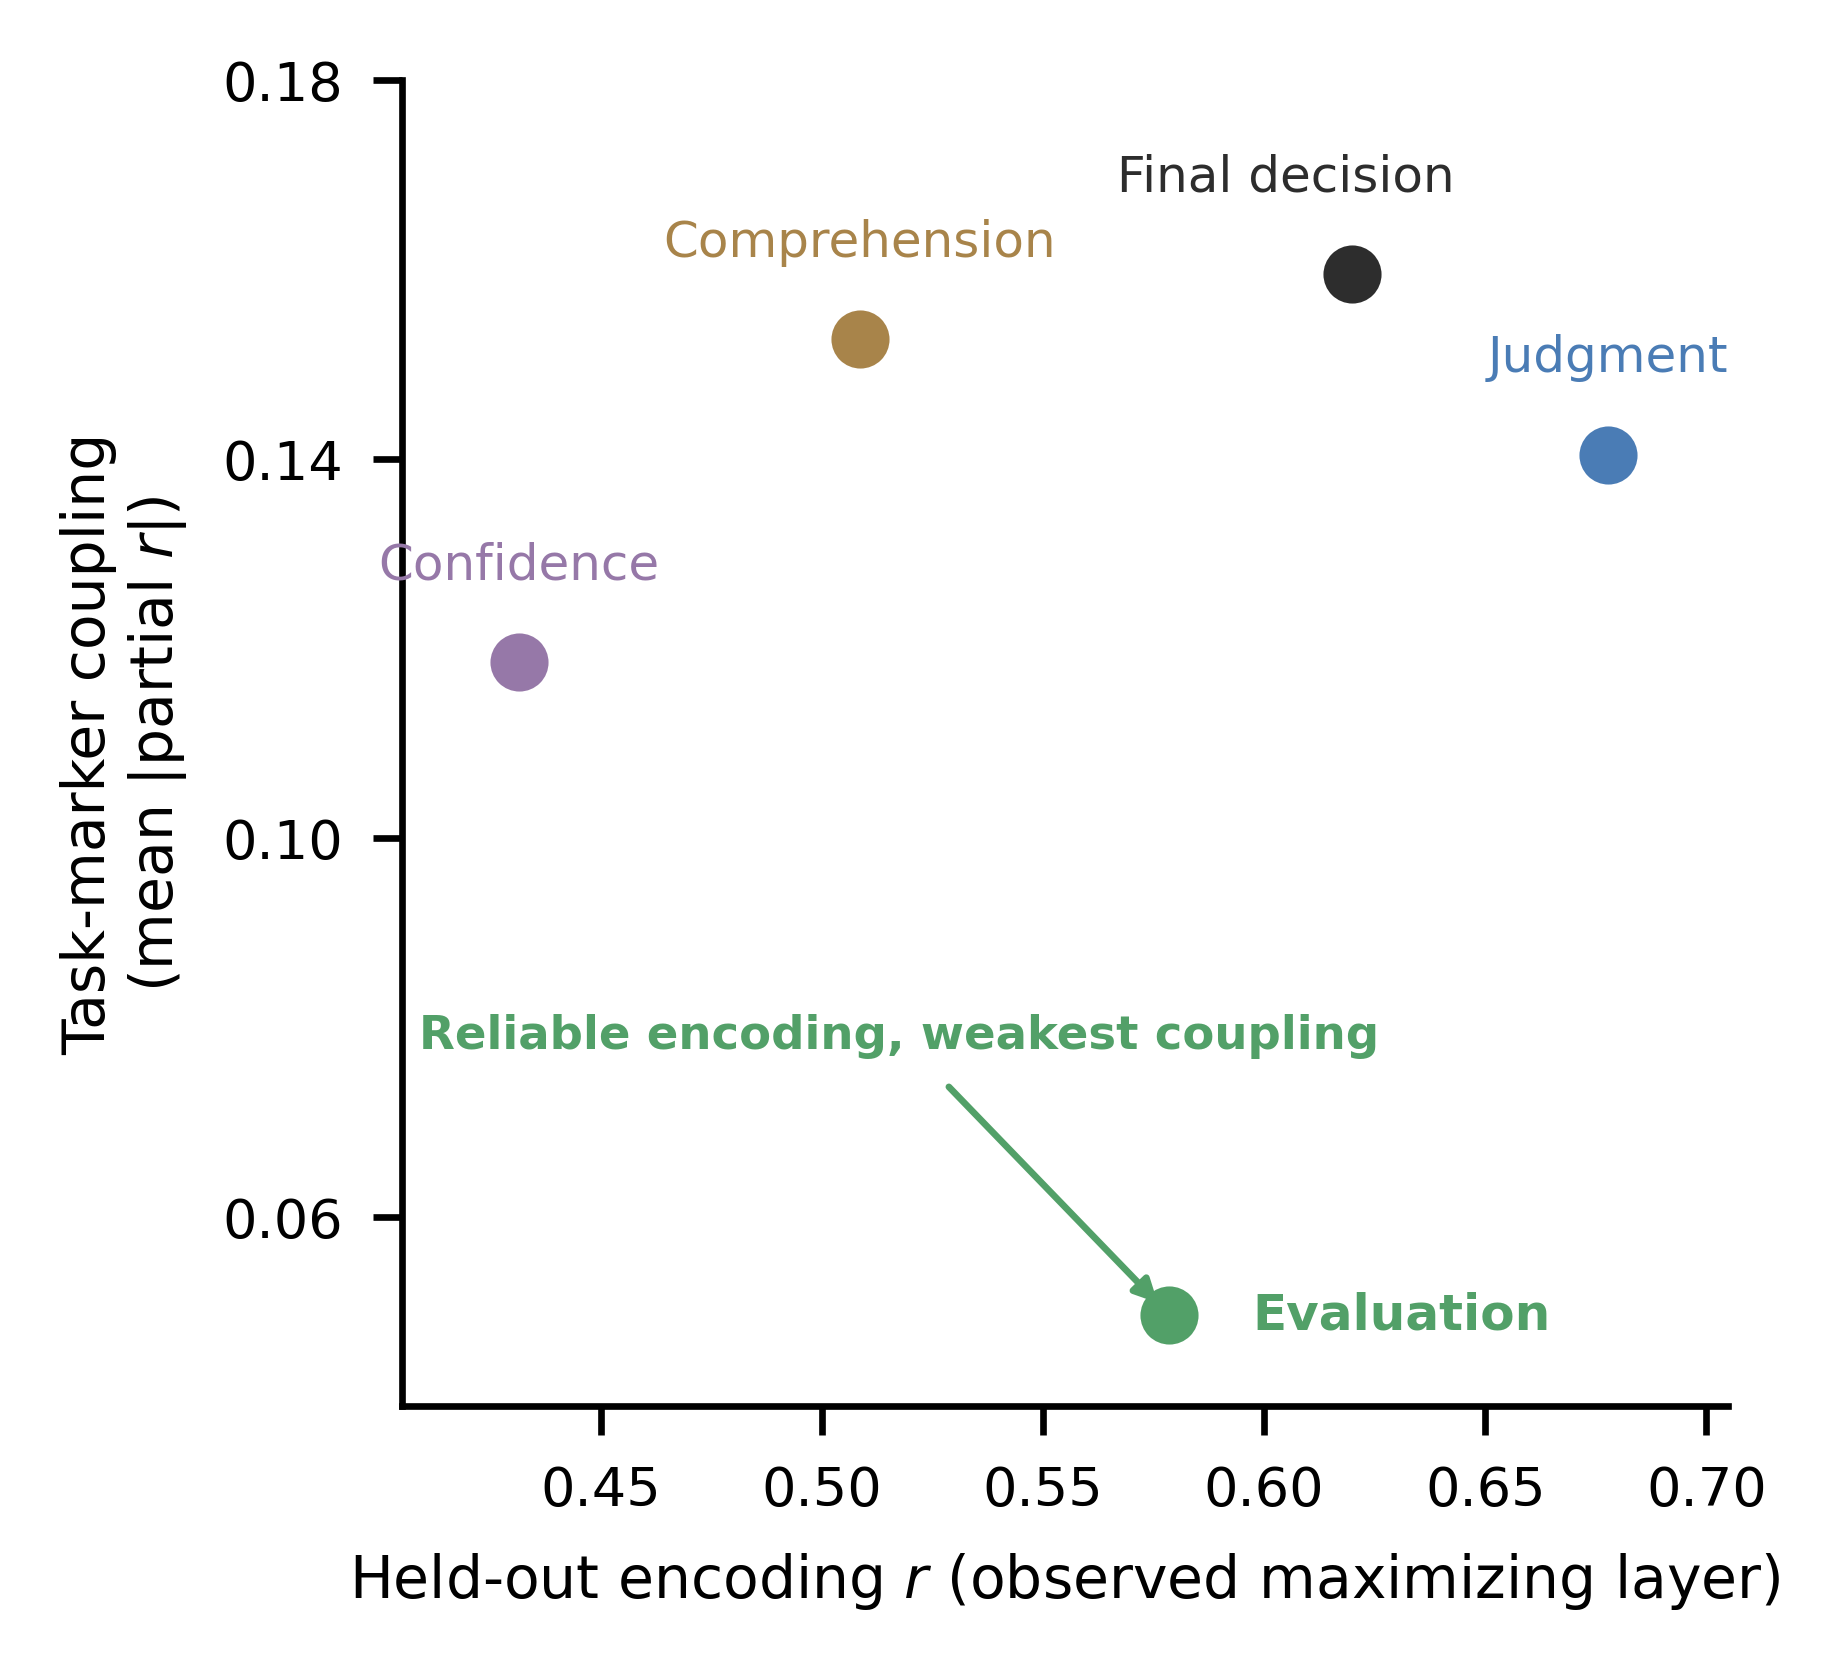

In [27]:
# Draw the final Figure 2 manuscript panel.
FIG2_REVISED_PNG = FIGURE_DIR / "fig2.png"
FIG2_REVISED_PDF = FIGURE_DIR / "fig2.pdf"
fig2r, ax2r = plt.subplots(figsize=(72 * MM, 72 * MM))
fig2r.subplots_adjust(left=.16, bottom=.11, right=.94, top=.94)
label_offsets = {
    "comprehension_continuous": (0, 10),
    "judgment_continuous": (0, 10),
    "final_decision_continuous": (-8, 10),
    "confidence_continuous": (0, 10),
}

for row in figure2_coupling.itertuples():
    color = COLORS[row.dimension]
    ax2r.scatter(row.encoding_r, row.mean_abs_partial_r, s=62, color=color,
                 edgecolor="white", linewidth=.9, zorder=3)
    if row.dimension == "evaluation_continuous":
        ax2r.annotate("Evaluation", (row.encoding_r, row.mean_abs_partial_r),
                      xytext=(10, 0), textcoords="offset points", va="center",
                      fontsize=6, color=color, fontweight="semibold")
        ax2r.annotate("Reliable encoding, weakest coupling",
                      (row.encoding_r, row.mean_abs_partial_r),
                      xytext=(-90, 32), textcoords="offset points", fontsize=5.6,
                      color=color, fontweight="semibold",
                      arrowprops={"arrowstyle": "-|>", "color": color, "lw": .8})
    else:
        dx, dy = label_offsets[row.dimension]
        ax2r.annotate(row.label, (row.encoding_r, row.mean_abs_partial_r),
                      xytext=(dx, dy), textcoords="offset points", ha="center",
                      fontsize=6, color=color)

ax2r.set_xlim(.405, .705)
ax2r.set_ylim(.04, .18)
ax2r.set_box_aspect(1)
ax2r.set_xticks(np.arange(.45, .71, .05))
ax2r.set_yticks([.06, .10, .14, .18])
ax2r.set_xlabel("Held-out encoding $r$ (observed maximizing layer)", fontsize=7)
ax2r.set_ylabel("Task-marker coupling\n(mean $|$partial $r|$)", fontsize=7)
ax2r.tick_params(labelsize=6.5)
ax2r.spines[["top", "right"]].set_visible(False)

fig2r.savefig(FIG2_REVISED_PNG, dpi=600, bbox_inches="tight", facecolor="white")
fig2r.savefig(FIG2_REVISED_PDF, bbox_inches="tight", facecolor="white")
plt.close(fig2r)
print("Saved:", FIG2_REVISED_PNG)
display(Image(filename=str(FIG2_REVISED_PNG)))

## Figure 2 reported outputs

The next cell collects the descriptive coupling coordinates and key inferential quantities into compact tables. Evaluation's relative position is assessed by paired participant resampling; inferential claims use the signed, multiplicity-corrected marker tests rather than the absolute-mean display coordinate.

In [28]:
# Assemble the Figure 2 quantities used in reporting.
figure2_report = figure2_coupling.copy()
figure2_report["evaluation_lowest_bootstrap_rate"] = np.nan
figure2_report.loc[
    figure2_report.dimension == "evaluation_continuous",
    "evaluation_lowest_bootstrap_rate",
] = evaluation_is_lowest
figure2_report.to_csv(FIG2_DIR / "figure2_reported_summary.csv", index=False)

figure2_inference_summary = pd.DataFrame({
    "quantity": [
        "marker_tests_declared",
        "marker_tests_reject_holm_05",
        "evaluation_tests_reject_holm_05",
        "evaluation_lowest_bootstrap_rate",
    ],
    "value": [
        len(figure2_marker_tests),
        int(figure2_marker_tests.reject_holm_05.sum()),
        int(figure2_marker_tests.loc[
            figure2_marker_tests.dimension == "evaluation_continuous",
            "reject_holm_05",
        ].sum()),
        evaluation_is_lowest,
    ],
})
figure2_inference_summary.to_csv(
    FIG2_DIR / "figure2_inference_summary.csv", index=False
)

display(figure2_report.round(4))
display(figure2_inference_summary.round(4))

,dimension,label,observed_max_layer,mean_abs_partial_r,encoding_r,evaluation_lowest_bootstrap_rate
0,comprehension_continuous,Comprehension,13,0.1526,0.5086,NaN
1,confidence_continuous,Confidence,16,0.1186,0.4315,NaN
2,evaluation_continuous,Evaluation,12,0.0497,0.5786,0.9168
3,final_decision_continuous,Final decision,21,0.1595,0.6199,NaN
4,judgment_continuous,Judgment,14,0.1404,0.6778,NaN


,quantity,value
0,marker_tests_declared,10.0000
1,marker_tests_reject_holm_05,6.0000
2,evaluation_tests_reject_holm_05,0.0000
3,evaluation_lowest_bootstrap_rate,0.9168


---

# Figure 3 — vocabulary coupling and layer sensitivity

The focal layers are the observed maximizing layers from Figure 1; vocabulary–win-switch coupling is not used for layer selection. The analysis projects residual-stream activations through Gemma's tied unembedding and constructs:

- **Panel A:** the Evaluation–Final Decision token-coupling landscape;
- **Panel B:** exact rubric specificity for the two token bundles;
- **Panel C:** token-level rubric coupling versus win-switch coupling;
- **Sensitivity analysis:** the complete L0–L25 token-profile result, verifying that the selected layers were defined independently.

In [29]:
# Figure 3 setup — exact token filter and memory-mapped Gemma unembedding rows.
import gc, json, re
from collections import Counter
from huggingface_hub import hf_hub_download
from safetensors import safe_open
from scipy.stats import spearmanr

FIG3_DIR = DATA_DIR
# Focal layers are the Figure 1 observed maximizing layers. Win-switch rate is not used here.
EV_LAYER = int(encoding_maxima.loc[
    encoding_maxima.dimension == "evaluation_continuous", "observed_max_layer"
].iloc[0])
FD_LAYER = int(encoding_maxima.loc[
    encoding_maxima.dimension == "final_decision_continuous", "observed_max_layer"
].iloc[0])
F3_BOOT = 5000
F3_EV, F3_FD = "#52A068", "#2D2D2D"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Figure 3 layers from observed maximizing layers: Evaluation L{EV_LAYER}, Final Decision L{FD_LAYER}")
F3_STOP = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for", "of",
    "is", "was", "were", "be", "it", "i", "you", "he", "she", "we", "they",
    "my", "me", "that", "this", "with", "as", "by", "from", "not", "no", "if",
    "so", "when", "would", "have", "had", "just", "one", "time", "there", "about",
}


def f3_readable_token(token_id):
    token = tokenizer.decode([int(token_id)]).strip().replace("\n", " ")
    if not token or len(token) > 24:
        return None
    return token if sum(char.isalpha() for char in token) >= max(2, len(token) // 2) else None


def f3_is_content(token):
    return token.lower() not in F3_STOP and bool(re.match(r"^[A-Za-z][A-Za-z\-']*$", token))


f3_counts = Counter()
for text in texts:
    f3_counts.update(tokenizer.encode(text, add_special_tokens=False))
f3_eligible = [
    (int(token_id), f3_readable_token(token_id), int(count))
    for token_id, count in f3_counts.items()
    if count >= 5 and f3_readable_token(token_id) and f3_is_content(f3_readable_token(token_id))
]
f3_token_ids = np.array([row[0] for row in f3_eligible], dtype=int)
f3_tokens = [row[1] for row in f3_eligible]
assert len(f3_token_ids) == 241

print("Memory-mapping the 241 required unembedding rows...")
f3_index_path = Path(hf_hub_download(MODEL_NAME, "model.safetensors.index.json"))
f3_weight_map = json.loads(f3_index_path.read_text(encoding="utf-8"))["weight_map"]
f3_embedding_key = next(key for key in f3_weight_map if key.endswith("embed_tokens.weight"))
f3_shard_path = hf_hub_download(MODEL_NAME, f3_weight_map[f3_embedding_key])
with safe_open(f3_shard_path, framework="pt", device="cpu") as weights:
    embedding_slice = weights.get_slice(f3_embedding_key)
    f3_vocab_size = int(embedding_slice.get_shape()[0])
    f3_unembed = torch.cat([
        embedding_slice[token_id:token_id + 1, :].float() for token_id in f3_token_ids
    ]).numpy()
gc.collect()

pd.DataFrame(f3_eligible, columns=["token_id", "token", "corpus_count"]).to_csv(
    FIG3_DIR / "figure3_eligible_content_tokens.csv", index=False
)
print("Eligible content tokens:", len(f3_token_ids), "| vocabulary:", f3_vocab_size,
      "| unembedding slice:", f3_unembed.shape)

Figure 3 layers from observed maximizing layers: Evaluation L12, Final Decision L21
Memory-mapping the 241 required unembedding rows...


Eligible content tokens: 241 | vocabulary: 256000 | unembedding slice: (241, 2304)


In [30]:
# Figure 3 Panels A and C — token and lemma coupling landscapes.
def f3_residualise(values, control=loglen):
    values = np.asarray(values, float)
    design = np.column_stack([np.ones(len(control)), np.asarray(control, float)])
    return values - design @ np.linalg.lstsq(design, values, rcond=None)[0]


def f3_corr(y, x):
    return float(pearsonr(f3_residualise(y), f3_residualise(x)).statistic)


def f3_token_profile(y, logits):
    y0 = f3_residualise(y)
    x0 = f3_residualise(logits)
    denominator = np.linalg.norm(y0) * np.linalg.norm(x0, axis=0)
    return (x0.T @ y0) / denominator


def f3_morph_groups(tokens):
    suffixes = ("s", "es", "ed", "ing", "d")
    parent = list(range(len(tokens)))
    def root(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i
    for i, first in enumerate(tokens):
        for j in range(i + 1, len(tokens)):
            second = tokens[j]
            short, long = sorted((first.lower(), second.lower()), key=len)
            if first.lower() == second.lower() or any(long == short + suffix for suffix in suffixes):
                ri, rj = root(i), root(j)
                if ri != rj:
                    parent[ri] = rj
    groups = {}
    for i in range(len(tokens)):
        groups.setdefault(root(i), []).append(i)
    return list(groups.values())


f3_ev = df["evaluation_continuous"].to_numpy(float)
f3_fd = df["final_decision_continuous"].to_numpy(float)
f3_wsr = df["wsr_avg"].to_numpy(float)
f3_mu03 = df["mu03_avg"].to_numpy(float)
f3_hidden_l12 = f3_residualise(pooled[f"mean_L{EV_LAYER}"].astype(float))
f3_hidden_l21 = f3_residualise(pooled[f"mean_L{FD_LAYER}"].astype(float))
f3_logits_l12 = f3_hidden_l12 @ f3_unembed.T
f3_logits_l21 = f3_hidden_l21 @ f3_unembed.T

f3_landscape = pd.DataFrame({
    "token_id": f3_token_ids,
    "token": f3_tokens,
    "corpus_count": [row[2] for row in f3_eligible],
    "r_ev": f3_token_profile(f3_ev, f3_logits_l12),
    "r_fd": f3_token_profile(f3_fd, f3_logits_l21),
    "r_wsr_l12": f3_token_profile(f3_wsr, f3_logits_l12),
    "r_wsr_l21": f3_token_profile(f3_wsr, f3_logits_l21),
    "r_mu03_l12": f3_token_profile(f3_mu03, f3_logits_l12),
    "r_mu03_l21": f3_token_profile(f3_mu03, f3_logits_l21),
})
f3_landscape["delta"] = f3_landscape.r_ev - f3_landscape.r_fd

f3_lemma_rows = []
for indices in f3_morph_groups(f3_tokens):
    counts = np.array([f3_eligible[i][2] for i in indices])
    members = [f3_tokens[i] for i in indices]
    mass_ev = f3_logits_l12[:, indices].mean(axis=1)
    mass_fd = f3_logits_l21[:, indices].mean(axis=1)
    r_ev, r_fd = f3_corr(f3_ev, mass_ev), f3_corr(f3_fd, mass_fd)
    f3_lemma_rows.append({
        "token": members[int(np.argmax(counts))], "members": "|".join(sorted(members, key=str.lower)),
        "member_indices": indices, "corpus_count": int(counts.sum()),
        "r_ev": r_ev, "r_fd": r_fd, "delta": r_ev - r_fd,
        "r_wsr_l12": f3_corr(f3_wsr, mass_ev), "r_wsr_l21": f3_corr(f3_wsr, mass_fd),
    })
f3_lemmas = pd.DataFrame(f3_lemma_rows).sort_values("corpus_count", ascending=False).reset_index(drop=True)
assert len(f3_landscape) == 241 and len(f3_lemmas) == 207

f3_landscape.to_csv(FIG3_DIR / "figure3_token_landscape.csv", index=False)
f3_lemmas.drop(columns="member_indices").to_csv(FIG3_DIR / "figure3_lemma_landscape.csv", index=False)
print("Panel A lemma channels:", len(f3_lemmas))
print("Panel C content tokens:", len(f3_landscape))

Panel A lemma channels: 207
Panel C content tokens: 241


## Token-filter diagnostics

Intermediate-layer logits are not calibrated probabilities, so an absolute cutoff would not establish whether a token is meaningfully represented. We instead evaluate each token against the exact vocabulary observed in the 486 reflections. At L12 and L21, the next cell reports raw logit distributions and participant-wise ranks for the 241 retained content tokens and every excluded corpus token. It also displays the highest-ranking excluded tokens so that semantically relevant omissions can be inspected directly.

As a selection-sensitivity check, the token-profile analysis is repeated with minimum corpus counts of 1, 2, 5, and 10 while holding the readability and content-word rules fixed. The manuscript analysis uses the prespecified threshold of five occurrences.

In [31]:
# Diagnose retained-token score magnitude, corpus-relative rank, and filter sensitivity.
f3_corpus_ids = np.array(sorted(f3_counts), dtype=int)
f3_corpus_counts = np.array([f3_counts[int(token_id)] for token_id in f3_corpus_ids])
f3_retained_ids = set(f3_token_ids.tolist())
assert len(f3_corpus_ids) == 1143

with safe_open(f3_shard_path, framework="pt", device="cpu") as weights:
    embedding = weights.get_slice(f3_embedding_key)
    f3_corpus_unembed = torch.cat([
        embedding[token_id:token_id + 1, :].float()
        for token_id in f3_corpus_ids
    ]).numpy()


def f3_exclusion_reason(token_id, count):
    token = f3_readable_token(token_id)
    if count < 5:
        return "frequency_below_5"
    if token is None:
        return "unreadable"
    if not f3_is_content(token):
        return "non_content"
    return "retained"


def f3_rank_columns(scores):
    order = np.argsort(-scores, axis=1)
    ranks = np.empty_like(order, dtype=np.int32)
    np.put_along_axis(
        ranks, order, np.arange(1, scores.shape[1] + 1, dtype=np.int32)[None, :], axis=1
    )
    return ranks


f3_filter_rows = []
f3_layer_score_cache = {}
for dimension, layer in [("Evaluation", EV_LAYER), ("Final Decision", FD_LAYER)]:
    raw_hidden = pooled[f"mean_L{layer}"].astype(float)
    raw_scores = raw_hidden @ f3_corpus_unembed.T
    corpus_ranks = f3_rank_columns(raw_scores)
    f3_layer_score_cache[layer] = raw_scores

    for column, (token_id, count) in enumerate(zip(f3_corpus_ids, f3_corpus_counts)):
        readable = f3_readable_token(token_id)
        token = readable or tokenizer.decode([int(token_id)]).strip().replace("\n", " ")
        token_ranks = corpus_ranks[:, column]
        token_scores = raw_scores[:, column]
        f3_filter_rows.append({
            "dimension": dimension,
            "layer": layer,
            "token_id": int(token_id),
            "token": token,
            "corpus_count": int(count),
            "filter_status": f3_exclusion_reason(token_id, count),
            "retained": int(token_id) in f3_retained_ids,
            "mean_raw_logit": token_scores.mean(),
            "median_raw_logit": np.median(token_scores),
            "maximum_raw_logit": token_scores.max(),
            "best_corpus_rank": token_ranks.min(),
            "median_corpus_rank": np.median(token_ranks),
            "participants_top10": int(np.sum(token_ranks <= 10)),
            "participants_top50": int(np.sum(token_ranks <= 50)),
            "participants_top100": int(np.sum(token_ranks <= 100)),
        })

f3_filter_diagnostics = pd.DataFrame(f3_filter_rows)
f3_filter_summary = (
    f3_filter_diagnostics
    .groupby(["dimension", "layer", "filter_status"], as_index=False)
    .agg(
        n_tokens=("token_id", "size"),
        median_best_rank=("best_corpus_rank", "median"),
        median_of_median_ranks=("median_corpus_rank", "median"),
        median_maximum_raw_logit=("maximum_raw_logit", "median"),
        tokens_ever_top10=("participants_top10", lambda values: int(np.sum(values > 0))),
        tokens_ever_top50=("participants_top50", lambda values: int(np.sum(values > 0))),
        tokens_ever_top100=("participants_top100", lambda values: int(np.sum(values > 0))),
        participant_token_top100_hits=("participants_top100", "sum"),
    )
)
f3_filter_summary["participant_token_top100_rate"] = (
    f3_filter_summary.participant_token_top100_hits
    / (f3_filter_summary.n_tokens * len(df))
)

# Repeat the Panel C statistic under broader and narrower frequency thresholds.
f3_filter_robustness_rows = []
for minimum_count in [1, 2, 5, 10]:
    selected_columns = np.array([
        count >= minimum_count
        and f3_readable_token(token_id) is not None
        and f3_is_content(f3_readable_token(token_id))
        for token_id, count in zip(f3_corpus_ids, f3_corpus_counts)
    ])
    for dimension, layer, rubric_scores in [
        ("Evaluation", EV_LAYER, f3_ev),
        ("Final Decision", FD_LAYER, f3_fd),
    ]:
        residual_hidden = f3_residualise(pooled[f"mean_L{layer}"].astype(float))
        selected_logits = residual_hidden @ f3_corpus_unembed[selected_columns].T
        rubric_profile = f3_token_profile(rubric_scores, selected_logits)
        wsr_profile = f3_token_profile(f3_wsr, selected_logits)
        result = spearmanr(rubric_profile, wsr_profile)
        f3_filter_robustness_rows.append({
            "dimension": dimension,
            "layer": layer,
            "minimum_corpus_count": minimum_count,
            "n_content_tokens": int(selected_columns.sum()),
            "spearman_rho": result.statistic,
            "spearman_p": result.pvalue,
            "manuscript_filter": minimum_count == 5,
        })

f3_filter_robustness = pd.DataFrame(f3_filter_robustness_rows)
f3_filter_diagnostics.to_csv(
    FIG3_DIR / "figure3_token_filter_score_diagnostics.csv", index=False
)
f3_filter_summary.to_csv(
    FIG3_DIR / "figure3_token_filter_summary.csv", index=False
)
f3_filter_robustness.to_csv(
    FIG3_DIR / "figure3_token_filter_robustness.csv", index=False
)

print("Retained versus excluded corpus-token diagnostics:")
display(f3_filter_summary.round(4))
print("Highest-ranking excluded corpus tokens at each focal layer:")
display(
    f3_filter_diagnostics.loc[~f3_filter_diagnostics.retained]
    .sort_values(["dimension", "best_corpus_rank", "maximum_raw_logit"])
    .groupby("dimension", as_index=False, group_keys=False)
    .head(15)[[
        "dimension", "layer", "token", "corpus_count", "filter_status",
        "best_corpus_rank", "participants_top100", "maximum_raw_logit",
    ]]
    .round(3)
)
print("Panel C sensitivity to the frequency threshold:")
display(f3_filter_robustness.round(4))

del f3_corpus_unembed, f3_layer_score_cache
gc.collect()

Retained versus excluded corpus-token diagnostics:


,dimension,layer,filter_status,n_tokens,median_best_rank,median_of_median_ranks,median_maximum_raw_logit,tokens_ever_top10,tokens_ever_top50,tokens_ever_top100,participant_token_top100_hits,participant_token_top100_rate
0,Evaluation,12,frequency_below_5,818,167.5,683.25,8.4135,40,167,296,14532,0.0366
1,Evaluation,12,non_content,55,15.0,109.00,19.1920,24,43,44,11107,0.4155
2,Evaluation,12,retained,241,37.0,305.00,14.5538,59,138,174,20200,0.1725
3,Evaluation,12,unreadable,29,90.0,393.50,12.7433,8,12,17,2761,0.1959
4,Final Decision,21,frequency_below_5,818,381.0,694.75,22.6302,4,34,92,8798,0.0221
5,Final Decision,21,non_content,55,19.0,56.00,92.2426,20,40,48,16761,0.6270
6,Final Decision,21,retained,241,121.0,360.50,54.6893,4,56,108,12936,0.1104
7,Final Decision,21,unreadable,29,8.0,60.00,92.7733,16,28,28,10105,0.7170


Highest-ranking excluded corpus tokens at each focal layer:


,dimension,layer,token,corpus_count,filter_status,best_corpus_rank,participants_top100,maximum_raw_logit
132,Evaluation,12,just,95,non_content,1,370,24.313
18,Evaluation,12,of,74,non_content,1,466,26.299
27,Evaluation,12,for,58,non_content,1,405,26.344
17,Evaluation,12,in,109,non_content,1,406,27.460
19,Evaluation,12,to,385,non_content,1,404,28.345
1108,Evaluation,12,,177,unreadable,1,484,30.674
1130,Evaluation,12,',95,unreadable,1,302,69.488
436,Evaluation,12,changes,2,frequency_below_5,2,17,16.871
872,Evaluation,12,staying,4,frequency_below_5,2,94,17.490
120,Evaluation,12,when,57,non_content,2,392,20.526


Panel C sensitivity to the frequency threshold:


,dimension,layer,minimum_corpus_count,n_content_tokens,spearman_rho,spearman_p,manuscript_filter
0,Evaluation,12,1,984,0.3296,0.0000,False
1,Final Decision,21,1,984,-0.6145,0.0000,False
2,Evaluation,12,2,488,0.2052,0.0000,False
3,Final Decision,21,2,488,-0.6465,0.0000,False
4,Evaluation,12,5,241,0.0526,0.4160,True
5,Final Decision,21,5,241,-0.6746,0.0000,True
6,Evaluation,12,10,126,-0.0695,0.4394,False
7,Final Decision,21,10,126,-0.6526,0.0000,False


0

In [32]:
# Figure 3 Panels B and C — exact specificity and profile statistics.
def f3_partial(y, x, control):
    design = np.column_stack([np.ones(len(control)), np.asarray(control, float)])
    yr = np.asarray(y, float) - design @ np.linalg.lstsq(design, np.asarray(y, float), rcond=None)[0]
    xr = np.asarray(x, float) - design @ np.linalg.lstsq(design, np.asarray(x, float), rcond=None)[0]
    return float(pearsonr(yr, xr).statistic)


def f3_profile(y, logits, control):
    design = np.column_stack([np.ones(len(control)), np.asarray(control, float)])
    yr = np.asarray(y, float) - design @ np.linalg.lstsq(design, np.asarray(y, float), rcond=None)[0]
    xr = np.asarray(logits, float) - design @ np.linalg.lstsq(design, np.asarray(logits, float), rcond=None)[0]
    return (xr.T @ yr) / (np.linalg.norm(yr) * np.linalg.norm(xr, axis=0))


def f3_unembedding_rows(token_ids):
    with safe_open(f3_shard_path, framework="pt", device="cpu") as weights:
        embedding = weights.get_slice(f3_embedding_key)
        return torch.cat([embedding[i:i + 1, :].float() for i in sorted(token_ids)]).numpy()


def f3_lexicon_ids(subset):
    words = {word for members in subset.members for word in str(members).split("|")}
    return {token_id for word in words for token_id in tokenizer.encode(word, add_special_tokens=False)}


def f3_bootstrap_r(y, x, rng, n_boot=F3_BOOT):
    draws = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.choice(len(y), size=len(y), replace=True)
        draws[b] = f3_partial(y[idx], x[idx], loglen[idx])
    observed = f3_partial(y, x, loglen)
    tail = np.mean(draws <= 0) if observed >= 0 else np.mean(draws >= 0)
    return observed, np.percentile(draws, 2.5), np.percentile(draws, 97.5), min(1.0, max(2 * tail, 1 / (n_boot + 1)))


upper_right = f3_lemmas[(f3_lemmas.r_ev > 0) & (f3_lemmas.r_fd > 0)]
f3_bundles = {
    "EV-lean": upper_right[upper_right.delta > 0],
    "FD-lean": upper_right[upper_right.delta < 0],
}
f3_bundle_setup = []
for label, subset in f3_bundles.items():
    layer = EV_LAYER if label == "EV-lean" else FD_LAYER
    hidden = f3_hidden_l12 if label == "EV-lean" else f3_hidden_l21
    matched, crossed = (f3_ev, f3_fd) if label == "EV-lean" else (f3_fd, f3_ev)
    token_ids = f3_lexicon_ids(subset)
    weights = f3_unembedding_rows(token_ids)
    mass = (hidden @ weights.T).mean(axis=1)
    f3_bundle_setup.append((label, subset, layer, matched, crossed, token_ids, weights, mass))

# Preserve the canonical random-number sequence: four coupling intervals precede the two contrasts.
f3_rng = np.random.default_rng(SEED)
f3_coupling_rows = []
for label, subset, layer, matched, crossed, token_ids, weights, mass in f3_bundle_setup:
    for target, scores, coupling_type in [
        ("matched", matched, "matched"), ("crossed", crossed, "cross")
    ]:
        estimate, low, high, p_value = f3_bootstrap_r(scores, mass, f3_rng)
        f3_coupling_rows.append({
            "bundle": label, "layer": layer, "target": target, "coupling_type": coupling_type,
            "n_lemmas": len(subset), "n_subwords": len(token_ids), "partial_r": estimate,
            "ci95_low": low, "ci95_high": high, "p_boot_two_sided": p_value,
        })
f3_bundle_couplings = pd.DataFrame(f3_coupling_rows)

f3_specificity_rows = []
for label, subset, layer, matched, crossed, token_ids, weights, mass in f3_bundle_setup:
    observed = f3_partial(matched, mass, loglen) - f3_partial(crossed, mass, loglen)
    draws = np.empty(F3_BOOT)
    for b in range(F3_BOOT):
        idx = f3_rng.choice(len(df), size=len(df), replace=True)
        draws[b] = f3_partial(matched[idx], mass[idx], loglen[idx]) - f3_partial(crossed[idx], mass[idx], loglen[idx])
    tail = np.mean(draws <= 0) if observed >= 0 else np.mean(draws >= 0)

    holdout_differences = []
    for split_seed in range(20):
        idx = np.random.default_rng(split_seed).choice(len(df), size=len(df) // 2, replace=False)
        hidden = f3_residualise(pooled[f"mean_L{layer}"].astype(float)[idx], loglen[idx])
        split_mass = (hidden @ weights.T).mean(axis=1)
        holdout_differences.append(
            f3_partial(matched[idx], split_mass, loglen[idx]) - f3_partial(crossed[idx], split_mass, loglen[idx])
        )
    holdout_differences = np.array(holdout_differences)
    f3_specificity_rows.append({
        "bundle": label, "layer": layer, "n_lemmas": len(subset), "n_subwords": len(token_ids),
        "partial_r_diff": observed, "ci95_low": np.percentile(draws, 2.5),
        "ci95_high": np.percentile(draws, 97.5),
        "p_boot_two_sided": min(1.0, max(2 * tail, 1 / (F3_BOOT + 1))),
        "holdout_mean_diff": holdout_differences.mean(),
        "holdout_positive_splits": int(np.sum(holdout_differences > 0)),
        "holdout_n_splits": len(holdout_differences),
    })
f3_specificity = pd.DataFrame(f3_specificity_rows)

f3_profile_rows = []
for label, layer, scores, logits, rubric_column, wsr_column in [
    ("Evaluation", EV_LAYER, f3_ev, f3_logits_l12, "r_ev", "r_wsr_l12"),
    ("Final Decision", FD_LAYER, f3_fd, f3_logits_l21, "r_fd", "r_wsr_l21"),
]:
    rho, p_value = spearmanr(f3_landscape[rubric_column], f3_landscape[wsr_column])
    boot = np.empty(200)
    for b in range(200):
        idx = f3_rng.choice(len(df), size=len(df), replace=True)
        boot[b] = spearmanr(
            f3_profile(scores[idx], logits[idx], loglen[idx]),
            f3_profile(f3_wsr[idx], logits[idx], loglen[idx]),
        ).statistic
    f3_profile_rows.append({
        "dimension": label, "layer": layer, "n_tokens": len(f3_landscape),
        "spearman_rho": rho, "spearman_p": p_value,
        "bootstrap_ci95_low": np.percentile(boot, 2.5),
        "bootstrap_ci95_high": np.percentile(boot, 97.5),
    })
f3_profiles = pd.DataFrame(f3_profile_rows)

f3_bundle_couplings.to_csv(FIG3_DIR / "figure3_bundle_couplings.csv", index=False)
f3_specificity.to_csv(FIG3_DIR / "figure3_rubric_specificity.csv", index=False)
f3_profiles.to_csv(FIG3_DIR / "figure3_token_profile_statistics.csv", index=False)
print("Panel B rubric specificity:")
display(f3_specificity.round(4))
print("Panel C token-profile statistics:")
display(f3_profiles.round(4))

Panel B rubric specificity:


,bundle,layer,n_lemmas,n_subwords,partial_r_diff,ci95_low,ci95_high,p_boot_two_sided,holdout_mean_diff,holdout_positive_splits,holdout_n_splits
0,EV-lean,12,11,16,0.1115,0.0094,0.2171,0.0288,0.1389,20,20
1,FD-lean,21,18,24,-0.0400,-0.1220,0.0503,0.3668,-0.0443,2,20


Panel C token-profile statistics:


,dimension,layer,n_tokens,spearman_rho,spearman_p,bootstrap_ci95_low,bootstrap_ci95_high
0,Evaluation,12,241,0.0526,0.416,-0.3825,0.3892
1,Final Decision,21,241,-0.6746,0.000,-0.7950,-0.3442


## Full-vocabulary semantic audit

The corpus-restricted diagnostic cannot detect meaningful vocabulary directions that never appear in the reflections. We therefore compute the same length-controlled token–rubric coupling over all 256,000 Gemma vocabulary directions at Evaluation L12 and Final Decision L21. The calculation is streamed in chunks and does not materialize the full participant-by-vocabulary logit matrix.

For each dimension, we export the strongest positive and negative standalone English content-token directions (English Zipf frequency $\geq 3$), deduplicated by lowercase form, and record whether each token occurred in the reflection corpus or passed the manuscript filter. Agreement with the 241-token Figure 3 calculation is checked numerically before interpreting the expanded vocabulary.

In [33]:
# Scan all Gemma vocabulary directions without constructing a participant-by-vocabulary matrix.
from wordfreq import zipf_frequency

F3_VOCAB_CHUNK = 4096
F3_TOP_DIRECTIONS = 20
F3_MIN_ENGLISH_ZIPF = 3.0
F3_FULL_VOCAB_CACHE = DATA_DIR / "figure3_full_vocabulary_couplings.npz"

f3_full_specs = {
    "Evaluation": {
        "layer": EV_LAYER,
        "hidden": f3_residualise(pooled[f"mean_L{EV_LAYER}"].astype(float)),
        "scores": f3_residualise(f3_ev),
    },
    "Final Decision": {
        "layer": FD_LAYER,
        "hidden": f3_residualise(pooled[f"mean_L{FD_LAYER}"].astype(float)),
        "scores": f3_residualise(f3_fd),
    },
}
f3_tensors = None
if F3_FULL_VOCAB_CACHE.exists() and not RECOMPUTE_FULL_VOCAB:
    with np.load(F3_FULL_VOCAB_CACHE) as cached_couplings:
        f3_full_couplings = {
            "Evaluation": np.array(cached_couplings["evaluation_l12"], copy=True),
            "Final Decision": np.array(cached_couplings["final_decision_l21"], copy=True),
        }
    print("Loaded full-vocabulary couplings:", F3_FULL_VOCAB_CACHE)
else:
    f3_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Full-vocabulary coupling device:", f3_device)
    f3_full_couplings = {
        dimension: np.empty(f3_vocab_size, dtype=np.float32)
        for dimension in f3_full_specs
    }
    f3_tensors = {
        dimension: (
            torch.as_tensor(spec["hidden"], dtype=torch.float32, device=f3_device),
            torch.as_tensor(spec["scores"], dtype=torch.float32, device=f3_device),
        )
        for dimension, spec in f3_full_specs.items()
    }
    f3_score_norms = {
        dimension: torch.linalg.vector_norm(scores)
        for dimension, (_, scores) in f3_tensors.items()
    }

    with safe_open(f3_shard_path, framework="pt", device="cpu") as weights:
        embedding = weights.get_slice(f3_embedding_key)
        for start in range(0, f3_vocab_size, F3_VOCAB_CHUNK):
            stop = min(start + F3_VOCAB_CHUNK, f3_vocab_size)
            unembedding_chunk = embedding[start:stop, :].float().to(f3_device)
            for dimension, (hidden, scores) in f3_tensors.items():
                logits = hidden @ unembedding_chunk.T
                denominator = (
                    torch.linalg.vector_norm(logits, dim=0)
                    * f3_score_norms[dimension]
                )
                coupling = (logits.T @ scores) / denominator.clamp_min(1e-12)
                f3_full_couplings[dimension][start:stop] = coupling.detach().cpu().numpy()
            if start == 0 or stop == f3_vocab_size or stop % (F3_VOCAB_CHUNK * 10) == 0:
                print(f"Processed vocabulary directions: {stop:,}/{f3_vocab_size:,}")
            del unembedding_chunk, logits, coupling

    np.savez_compressed(
        F3_FULL_VOCAB_CACHE,
        evaluation_l12=f3_full_couplings["Evaluation"],
        final_decision_l21=f3_full_couplings["Final Decision"],
    )
    print("Saved full-vocabulary couplings:", F3_FULL_VOCAB_CACHE)

# Confirm that the full scan exactly recovers the manuscript token calculations.
f3_validation_rows = []
for dimension, column in [("Evaluation", "r_ev"), ("Final Decision", "r_fd")]:
    expected = f3_landscape.set_index("token_id").loc[f3_token_ids, column].to_numpy()
    recovered = f3_full_couplings[dimension][f3_token_ids]
    maximum_error = float(np.max(np.abs(expected - recovered)))
    f3_validation_rows.append({
        "dimension": dimension,
        "n_validated_tokens": len(f3_token_ids),
        "maximum_absolute_error": maximum_error,
    })
    assert maximum_error < 1e-5
f3_full_validation = pd.DataFrame(f3_validation_rows)


def f3_top_readable_directions(dimension, pole, n=F3_TOP_DIRECTIONS):
    coupling = f3_full_couplings[dimension]
    order = np.argsort(-coupling) if pole == "positive" else np.argsort(coupling)
    records, seen_words = [], set()
    for vocabulary_rank, token_id in enumerate(order, start=1):
        token = f3_readable_token(token_id)
        piece = str(tokenizer.convert_ids_to_tokens(int(token_id)))
        if token is None or not f3_is_content(token) or not piece.startswith("▁"):
            continue
        normalized = token.lower()
        english_frequency = zipf_frequency(normalized, "en")
        if english_frequency < F3_MIN_ENGLISH_ZIPF or normalized in seen_words:
            continue
        seen_words.add(normalized)
        records.append({
            "dimension": dimension,
            "layer": f3_full_specs[dimension]["layer"],
            "pole": pole,
            "readable_rank": len(records) + 1,
            "full_vocabulary_rank": vocabulary_rank,
            "token_id": int(token_id),
            "token": token,
            "english_zipf_frequency": english_frequency,
            "coupling_r": float(coupling[token_id]),
            "occurred_in_reflections": int(token_id) in f3_counts,
            "corpus_count": int(f3_counts.get(int(token_id), 0)),
            "passed_manuscript_filter": int(token_id) in f3_retained_ids,
        })
        if len(records) == n:
            break
    return records


f3_full_direction_rows = []
for dimension in f3_full_specs:
    for pole in ["positive", "negative"]:
        f3_full_direction_rows.extend(
            f3_top_readable_directions(dimension, pole)
        )
f3_full_directions = pd.DataFrame(f3_full_direction_rows)
f3_full_summary = (
    f3_full_directions
    .groupby(["dimension", "layer", "pole"], as_index=False)
    .agg(
        n_reported=("token_id", "size"),
        n_occurred_in_reflections=("occurred_in_reflections", "sum"),
        n_passed_manuscript_filter=("passed_manuscript_filter", "sum"),
        strongest_coupling=("coupling_r", lambda values: values.iloc[0]),
        weakest_reported_coupling=("coupling_r", lambda values: values.iloc[-1]),
    )
)

f3_full_directions.to_csv(
    DATA_DIR / "figure3_full_vocabulary_top_directions.csv", index=False
)
f3_full_summary.to_csv(
    DATA_DIR / "figure3_full_vocabulary_summary.csv", index=False
)
f3_full_validation.to_csv(
    DATA_DIR / "figure3_full_vocabulary_validation.csv", index=False
)

display(f3_full_validation)
display(f3_full_summary.round(4))
for dimension in f3_full_specs:
    print(f"{dimension}: strongest readable full-vocabulary directions")
    display(
        f3_full_directions.query("dimension == @dimension")[[
            "pole", "readable_rank", "token", "english_zipf_frequency", "coupling_r",
            "occurred_in_reflections", "corpus_count", "passed_manuscript_filter",
        ]].round(4)
    )

if f3_tensors is not None:
    for hidden, scores in f3_tensors.values():
        del hidden, scores
del f3_tensors
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

Loaded full-vocabulary couplings: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\data\figure3_full_vocabulary_couplings.npz


,dimension,n_validated_tokens,maximum_absolute_error
0,Evaluation,241,1.533943e-07
1,Final Decision,241,1.291293e-07


,dimension,layer,pole,n_reported,n_occurred_in_reflections,n_passed_manuscript_filter,strongest_coupling,weakest_reported_coupling
0,Evaluation,12,negative,20,3,1,-0.4244,-0.3599
1,Evaluation,12,positive,20,0,0,0.4449,0.4152
2,Final Decision,21,negative,20,2,0,-0.4009,-0.2847
3,Final Decision,21,positive,20,0,0,0.4871,0.4192


Evaluation: strongest readable full-vocabulary directions


,pole,readable_rank,token,english_zipf_frequency,coupling_r,occurred_in_reflections,corpus_count,passed_manuscript_filter
0,positive,1,juvenile,3.88,0.4449,False,0,False
1,positive,2,cease,4.03,0.4368,False,0,False
2,positive,3,blockade,3.57,0.4342,False,0,False
3,positive,4,misdemeanor,3.38,0.4308,False,0,False
4,positive,5,prohibiting,3.32,0.4273,False,0,False
5,positive,6,prosecute,3.54,0.4259,False,0,False
6,positive,7,discontinue,3.11,0.4247,False,0,False
7,positive,8,severity,3.71,0.4242,False,0,False
8,positive,9,Hz,3.34,0.4213,False,0,False
9,positive,10,warns,3.73,0.4204,False,0,False


Final Decision: strongest readable full-vocabulary directions


,pole,readable_rank,token,english_zipf_frequency,coupling_r,occurred_in_reflections,corpus_count,passed_manuscript_filter
40,positive,1,horizontal,3.90,0.4871,False,0,False
41,positive,2,silver,4.81,0.4560,False,0,False
42,positive,3,shopping,4.68,0.4483,False,0,False
43,positive,4,smashed,3.84,0.4437,False,0,False
44,positive,5,vertical,4.15,0.4373,False,0,False
45,positive,6,orange,4.62,0.4348,False,0,False
46,positive,7,House,5.71,0.4326,False,0,False
47,positive,8,Cooper,4.26,0.4279,False,0,False
48,positive,9,McC,3.06,0.4249,False,0,False
49,positive,10,downtown,4.40,0.4249,False,0,False


6

Saved: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\figures\fig3.png


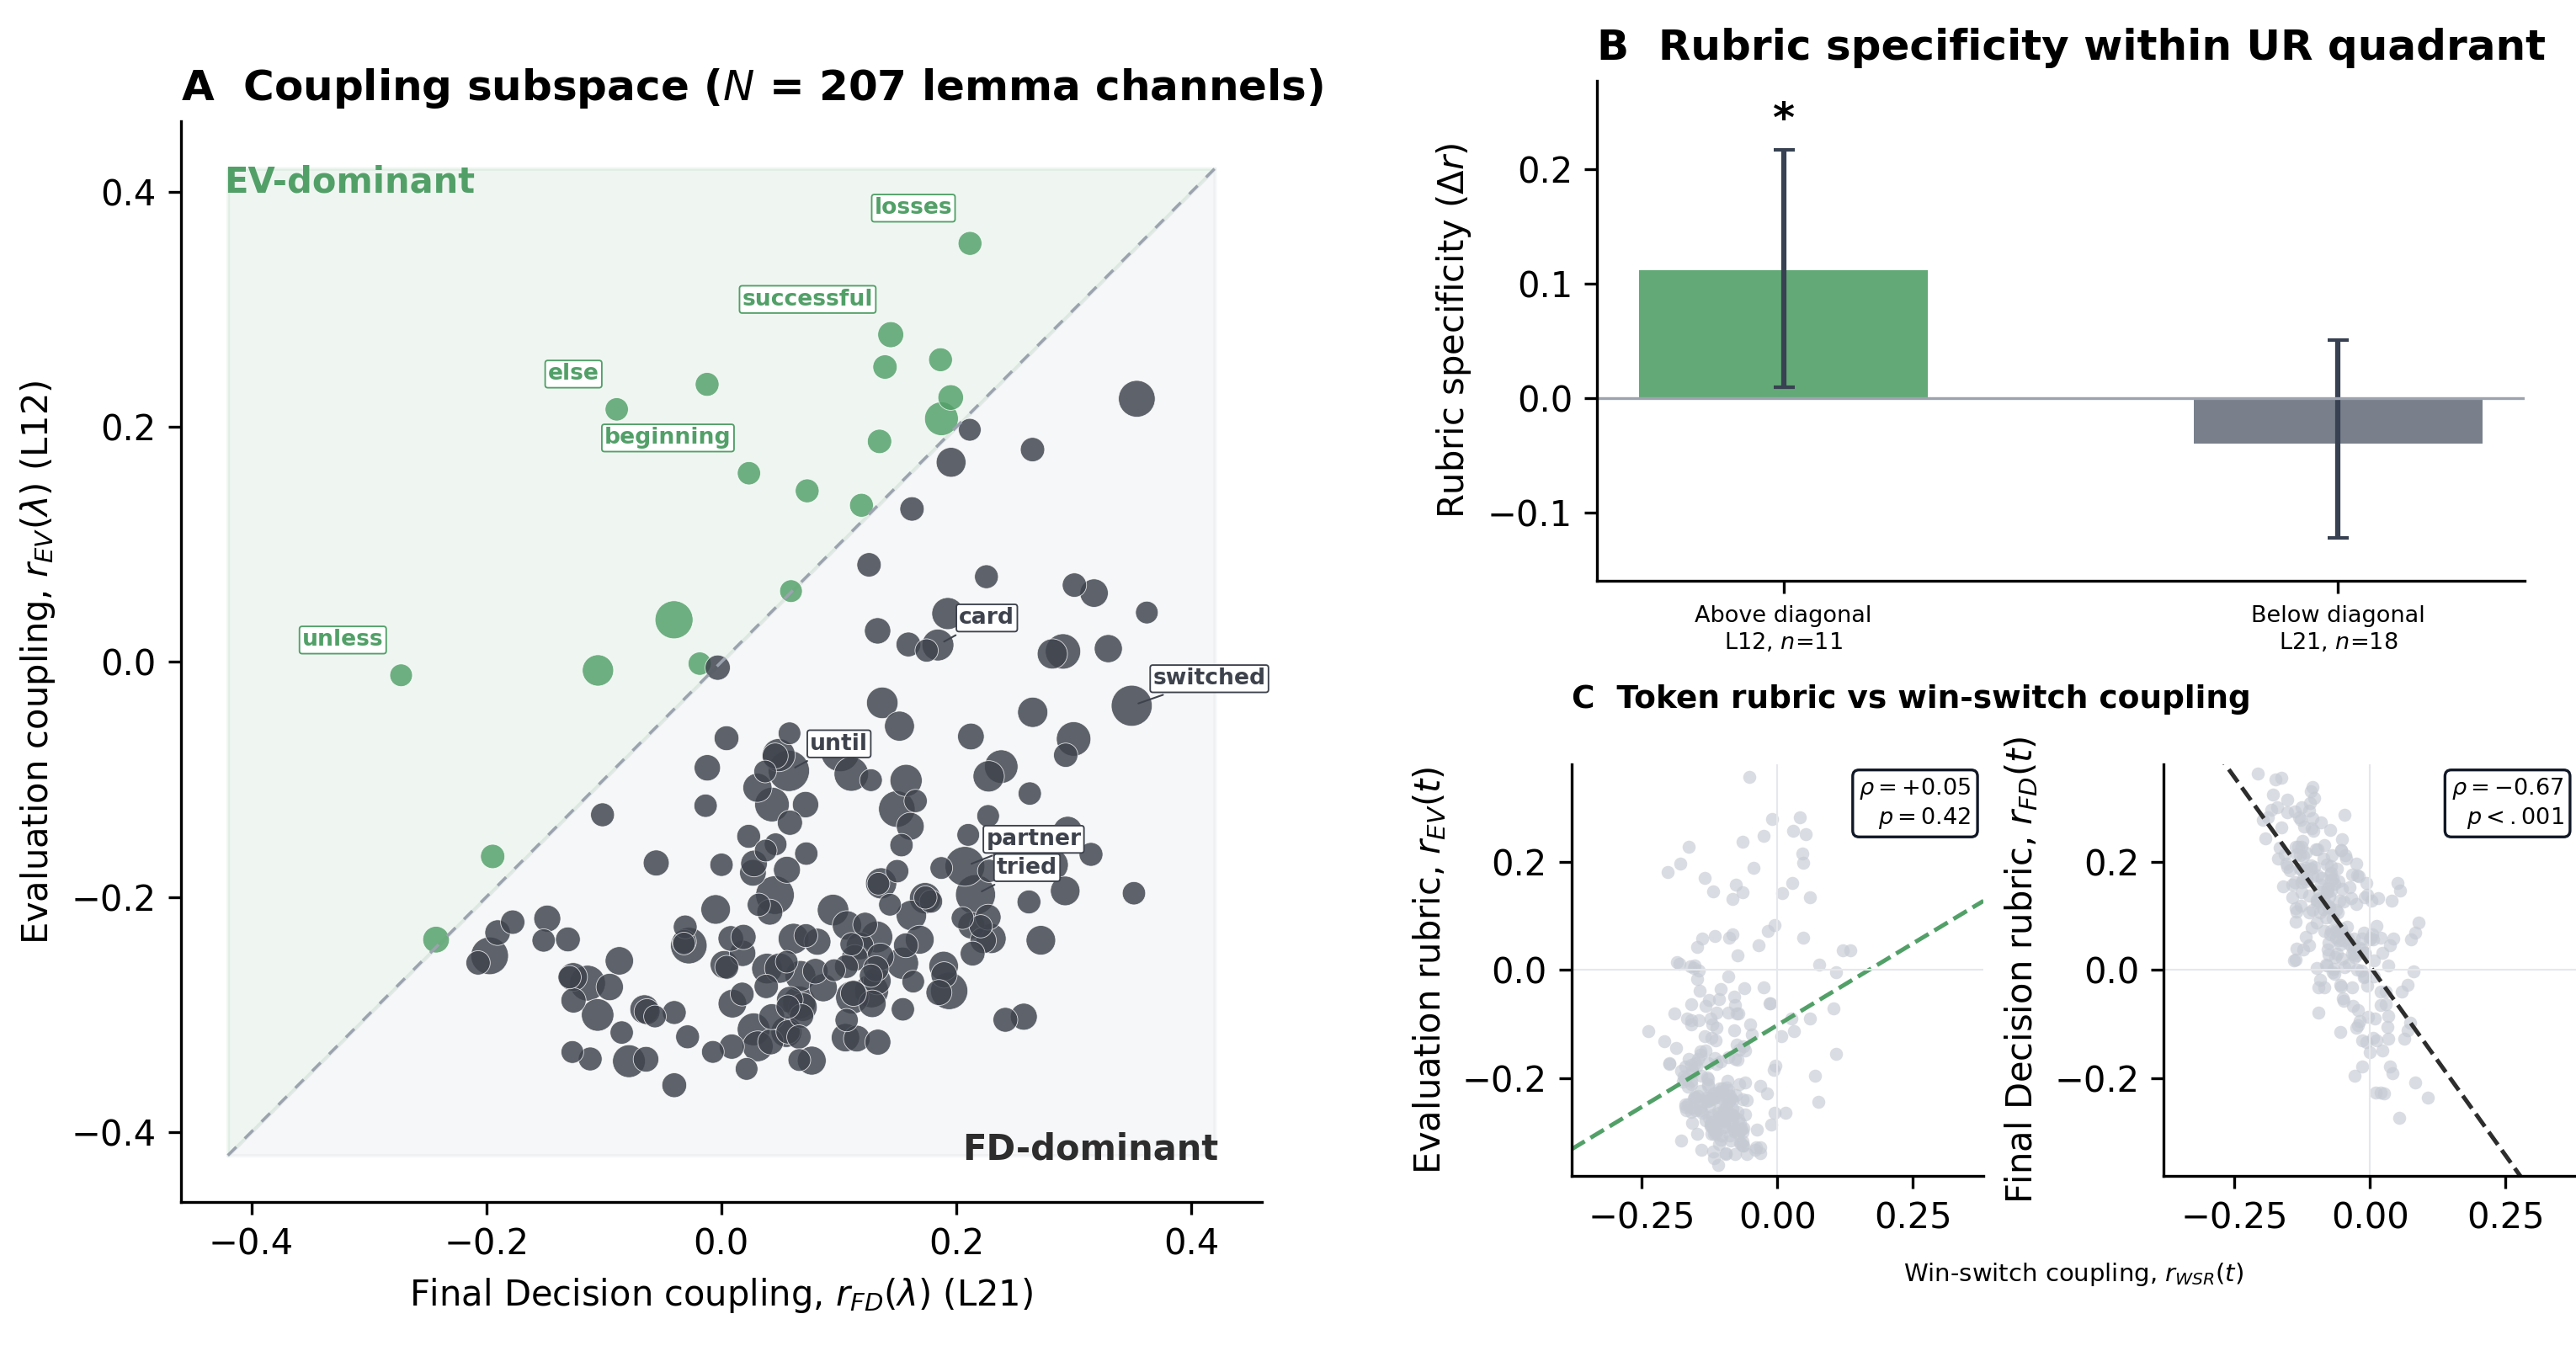

In [34]:
# Draw the three-panel Figure 3 from the computed tables.
FIG3_PNG = FIGURE_DIR / "fig3.png"
FIG3_PDF = FIGURE_DIR / "fig3.pdf"
fig3 = plt.figure(figsize=(10.2, 5.35))
ax_a = fig3.add_axes([.07, .11, .42, .80])
ax_b = fig3.add_axes([.62, .57, .36, .37])
ax_ev = fig3.add_axes([.61, .12, .16, .324])
ax_fd = fig3.add_axes([.84, .12, .16, .324], sharex=ax_ev)

# Panel A — lemma coupling plane.
limit = .42
line = np.linspace(-limit, limit, 200)
ev_mask = f3_lemmas.delta > 0
sizes = 18 + 120 * np.sqrt(f3_lemmas.corpus_count / f3_lemmas.corpus_count.max())
ax_a.fill_between(line, line, limit, color=F3_EV, alpha=.09)
ax_a.fill_between(line, -limit, line, color="#B8BFCA", alpha=.12)
ax_a.plot(line, line, color="#9CA3AF", lw=.85, ls=(0, (4, 4)))
ax_a.scatter(f3_lemmas.loc[ev_mask, "r_fd"], f3_lemmas.loc[ev_mask, "r_ev"],
             s=sizes[ev_mask], color=F3_EV, alpha=.82, edgecolor="white", linewidth=.2)
ax_a.scatter(f3_lemmas.loc[~ev_mask, "r_fd"], f3_lemmas.loc[~ev_mask, "r_ev"],
             s=sizes[~ev_mask], color="#3D424C", alpha=.82, edgecolor="white", linewidth=.2)
label_tokens = ["losses", "successful", "else", "beginning", "unless", "until",
                "card", "partner", "switched", "tried"]
for row in f3_lemmas[f3_lemmas.token.isin(label_tokens)].itertuples():
    color = F3_EV if row.delta > 0 else "#3D424C"
    dx = -.015 if row.delta > 0 else .018
    dy = .025 if row.delta > 0 else .018
    ax_a.annotate(row.token, (row.r_fd, row.r_ev), xytext=(row.r_fd + dx, row.r_ev + dy),
                  fontsize=6.4, color=color, fontweight="bold",
                  ha="right" if dx < 0 else "left",
                  bbox={"boxstyle": "round,pad=.12", "fc": "white", "ec": color, "lw": .45},
                  arrowprops=None if row.delta > 0 else {"arrowstyle": "-", "color": color, "lw": .5})
ax_a.set(xlim=(-.46, .46), ylim=(-.46, .46),
         xlabel=fr"Final Decision coupling, $r_{{FD}}(\lambda)$ (L{FD_LAYER})",
         ylabel=fr"Evaluation coupling, $r_{{EV}}(\lambda)$ (L{EV_LAYER})")
ax_a.set_aspect("equal")
ax_a.set_title(f"A  Coupling subspace ($N$ = {len(f3_lemmas)} lemma channels)", loc="left", fontweight="bold")
ax_a.text(.04, .96, "EV-dominant", transform=ax_a.transAxes, color=F3_EV, fontweight="bold", va="top")
ax_a.text(.96, .04, "FD-dominant", transform=ax_a.transAxes, color=F3_FD, fontweight="bold", ha="right")

# Panel B — matched-minus-crossed rubric specificity.
colors = [F3_EV, "#6B7280"]
for x, row in enumerate(f3_specificity.itertuples()):
    value = row.partial_r_diff
    ax_b.bar(x, value, width=.52, color=colors[x], alpha=.9)
    ax_b.errorbar(x, value, yerr=[[value - row.ci95_low], [row.ci95_high - value]],
                  fmt="none", color="#374151", capsize=3)
    if row.ci95_low > 0 or row.ci95_high < 0:
        ax_b.text(x, row.ci95_high + .015, "*", ha="center", fontsize=12, fontweight="bold")
ax_b.axhline(0, color="#9CA3AF", lw=.8)
ax_b.set_xticks([0, 1], [f"Above diagonal\nL{EV_LAYER}, $n$={len(f3_bundles['EV-lean'])}",
                         f"Below diagonal\nL{FD_LAYER}, $n$={len(f3_bundles['FD-lean'])}"], fontsize=6.5)
ax_b.set_ylabel(r"Rubric specificity ($\Delta r$)")
ax_b.set_title("B  Rubric specificity within UR quadrant", loc="left", fontweight="bold")
ax_b.set_ylim(-.16, max(.15, f3_specificity.ci95_high.max() + .06))

# Panel C — token-profile concordance with win-switch coupling.
def f3_profile_panel(ax, x, y, row, ylabel, color):
    ax.scatter(x, y, s=14, color="#C5CAD3", alpha=.65, linewidth=0)
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(-.38, .38, 100)
    ax.plot(xs, slope * xs + intercept, color=color, lw=1.2, ls="--")
    ax.axhline(0, color="#E5E7EB", lw=.5)
    ax.axvline(0, color="#E5E7EB", lw=.5)
    p_text = "$p < .001$" if row.spearman_p < .001 else f"$p = {row.spearman_p:.2f}$"
    ax.text(.97, .97, f"$\\rho = {row.spearman_rho:+.2f}$\n{p_text}", transform=ax.transAxes,
            ha="right", va="top", fontsize=6.5,
            bbox={"boxstyle": "round,pad=.28", "fc": "white", "ec": "#111827", "lw": .8})
    ax.set(xlim=(-.38, .38), ylim=(-.38, .38), ylabel=ylabel)
    ax.set_aspect("equal")

f3_profile_panel(ax_ev, f3_landscape.r_wsr_l12, f3_landscape.r_ev,
                 f3_profiles.iloc[0], r"Evaluation rubric, $r_{EV}(t)$", F3_EV)
f3_profile_panel(ax_fd, f3_landscape.r_wsr_l21, f3_landscape.r_fd,
                 f3_profiles.iloc[1], r"Final Decision rubric, $r_{FD}(t)$", F3_FD)
fig3.text(.61, .476, "C  Token rubric vs win-switch coupling", fontsize=9, fontweight="bold")
fig3.text(.805, .052, r"Win-switch coupling, $r_{WSR}(t)$", fontsize=7, ha="center")
for ax in (ax_a, ax_b, ax_ev, ax_fd):
    ax.spines[["top", "right"]].set_visible(False)

fig3.savefig(FIG3_PNG, dpi=300, facecolor="white")
fig3.savefig(FIG3_PDF, facecolor="white")
plt.close(fig3)
print("Saved:", FIG3_PNG)
display(Image(filename=str(FIG3_PNG)))

## Figure 3 main-analysis checkpoint

The main analysis is complete when the notebook reports the eligible content-token and lemma-channel counts, Panel B specificity estimates, and both Panel C profile correlations before displaying the three-panel figure. No reported statistic is copied from manuscript prose.

---

## Independent layer selection and complete sensitivity analysis

The Evaluation and Final Decision layers are recovered from the Figure 1 encoding analysis, which uses rubric prediction and no win-switch information. We then recompute the same eligible-token profile correlation at every layer from L0 to L25. This separates the selection rule from the tested outcome and shows whether the result depends on a single layer.

In [35]:
# Verify independent layer selection and compute complete L0–L25 sensitivity.
f3_maximum_table = encoding_maxima[
    encoding_maxima.dimension.isin(["evaluation_continuous", "final_decision_continuous"])
].copy()
f3_selected_layers = dict(zip(
    f3_maximum_table.dimension, f3_maximum_table.observed_max_layer.astype(int)
))
f3_selected_ev = f3_selected_layers["evaluation_continuous"]
f3_selected_fd = f3_selected_layers["final_decision_continuous"]
assert (f3_selected_ev, f3_selected_fd) == (12, 21)

f3_layer_rows = []
for layer in layers:
    hidden = f3_residualise(pooled[f"mean_L{layer}"].astype(float))
    logits = hidden @ f3_unembed.T
    ev_profile = f3_profile(f3_ev, logits, loglen)
    fd_profile = f3_profile(f3_fd, logits, loglen)
    wsr_profile = f3_profile(f3_wsr, logits, loglen)
    ev_test = spearmanr(ev_profile, wsr_profile)
    fd_test = spearmanr(fd_profile, wsr_profile)
    ev_fd_test = spearmanr(ev_profile, fd_profile)
    f3_layer_rows.append({
        "layer": int(layer), "n_tokens": len(f3_token_ids),
        "ev_wsr_rho": ev_test.statistic, "ev_wsr_p": ev_test.pvalue,
        "fd_wsr_rho": fd_test.statistic, "fd_wsr_p": fd_test.pvalue,
        "ev_fd_rho": ev_fd_test.statistic, "ev_fd_p": ev_fd_test.pvalue,
        "ev_encoding_maximum": layer == f3_selected_ev,
        "fd_encoding_maximum": layer == f3_selected_fd,
        "near_ev_maximum": abs(layer - f3_selected_ev) <= 2,
        "near_fd_maximum": abs(layer - f3_selected_fd) <= 2,
    })
f3_layer_sensitivity = pd.DataFrame(f3_layer_rows)
f3_layer_sensitivity.to_csv(
    FIG3_DIR / "figure3_token_profile_layer_sensitivity.csv", index=False
)

f3_selected_validation = pd.DataFrame([
    {
        "dimension": "Evaluation", "selection_source": "Figure 1 observed maximizing layer",
        "selected_layer": f3_selected_ev,
        "encoding_r": encoding_maxima.loc[
            encoding_maxima.dimension == "evaluation_continuous", "observed_max_r"
        ].iloc[0],
        "token_profile_wsr_rho": f3_layer_sensitivity.loc[
            f3_layer_sensitivity.layer == f3_selected_ev, "ev_wsr_rho"
        ].iloc[0],
        "token_profile_wsr_p": f3_layer_sensitivity.loc[
            f3_layer_sensitivity.layer == f3_selected_ev, "ev_wsr_p"
        ].iloc[0],
    },
    {
        "dimension": "Final Decision", "selection_source": "Figure 1 observed maximizing layer",
        "selected_layer": f3_selected_fd,
        "encoding_r": encoding_maxima.loc[
            encoding_maxima.dimension == "final_decision_continuous", "observed_max_r"
        ].iloc[0],
        "token_profile_wsr_rho": f3_layer_sensitivity.loc[
            f3_layer_sensitivity.layer == f3_selected_fd, "fd_wsr_rho"
        ].iloc[0],
        "token_profile_wsr_p": f3_layer_sensitivity.loc[
            f3_layer_sensitivity.layer == f3_selected_fd, "fd_wsr_p"
        ].iloc[0],
    },
])
f3_selected_validation.to_csv(
    FIG3_DIR / "figure3_selected_layer_validation.csv", index=False
)

print("Layers selected without win-switch data:")
display(f3_selected_validation.round(4))
print("Final Decision sensitivity around its L21 observed maximizing layer:")
display(f3_layer_sensitivity.query("near_fd_maximum")[[
    "layer", "fd_wsr_rho", "fd_wsr_p"
]].round(4))

Layers selected without win-switch data:


,dimension,selection_source,selected_layer,encoding_r,token_profile_wsr_rho,token_profile_wsr_p
0,Evaluation,Figure 1 observed maximizing layer,12,0.5786,0.0526,0.416
1,Final Decision,Figure 1 observed maximizing layer,21,0.6199,-0.6746,0.000


Final Decision sensitivity around its L21 observed maximizing layer:


,layer,fd_wsr_rho,fd_wsr_p
19,19,-0.6968,0.0
20,20,-0.7055,0.0
21,21,-0.6746,0.0
22,22,-0.6579,0.0
23,23,-0.6587,0.0


Saved: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\figures\fig3_layer_sensitivity.png


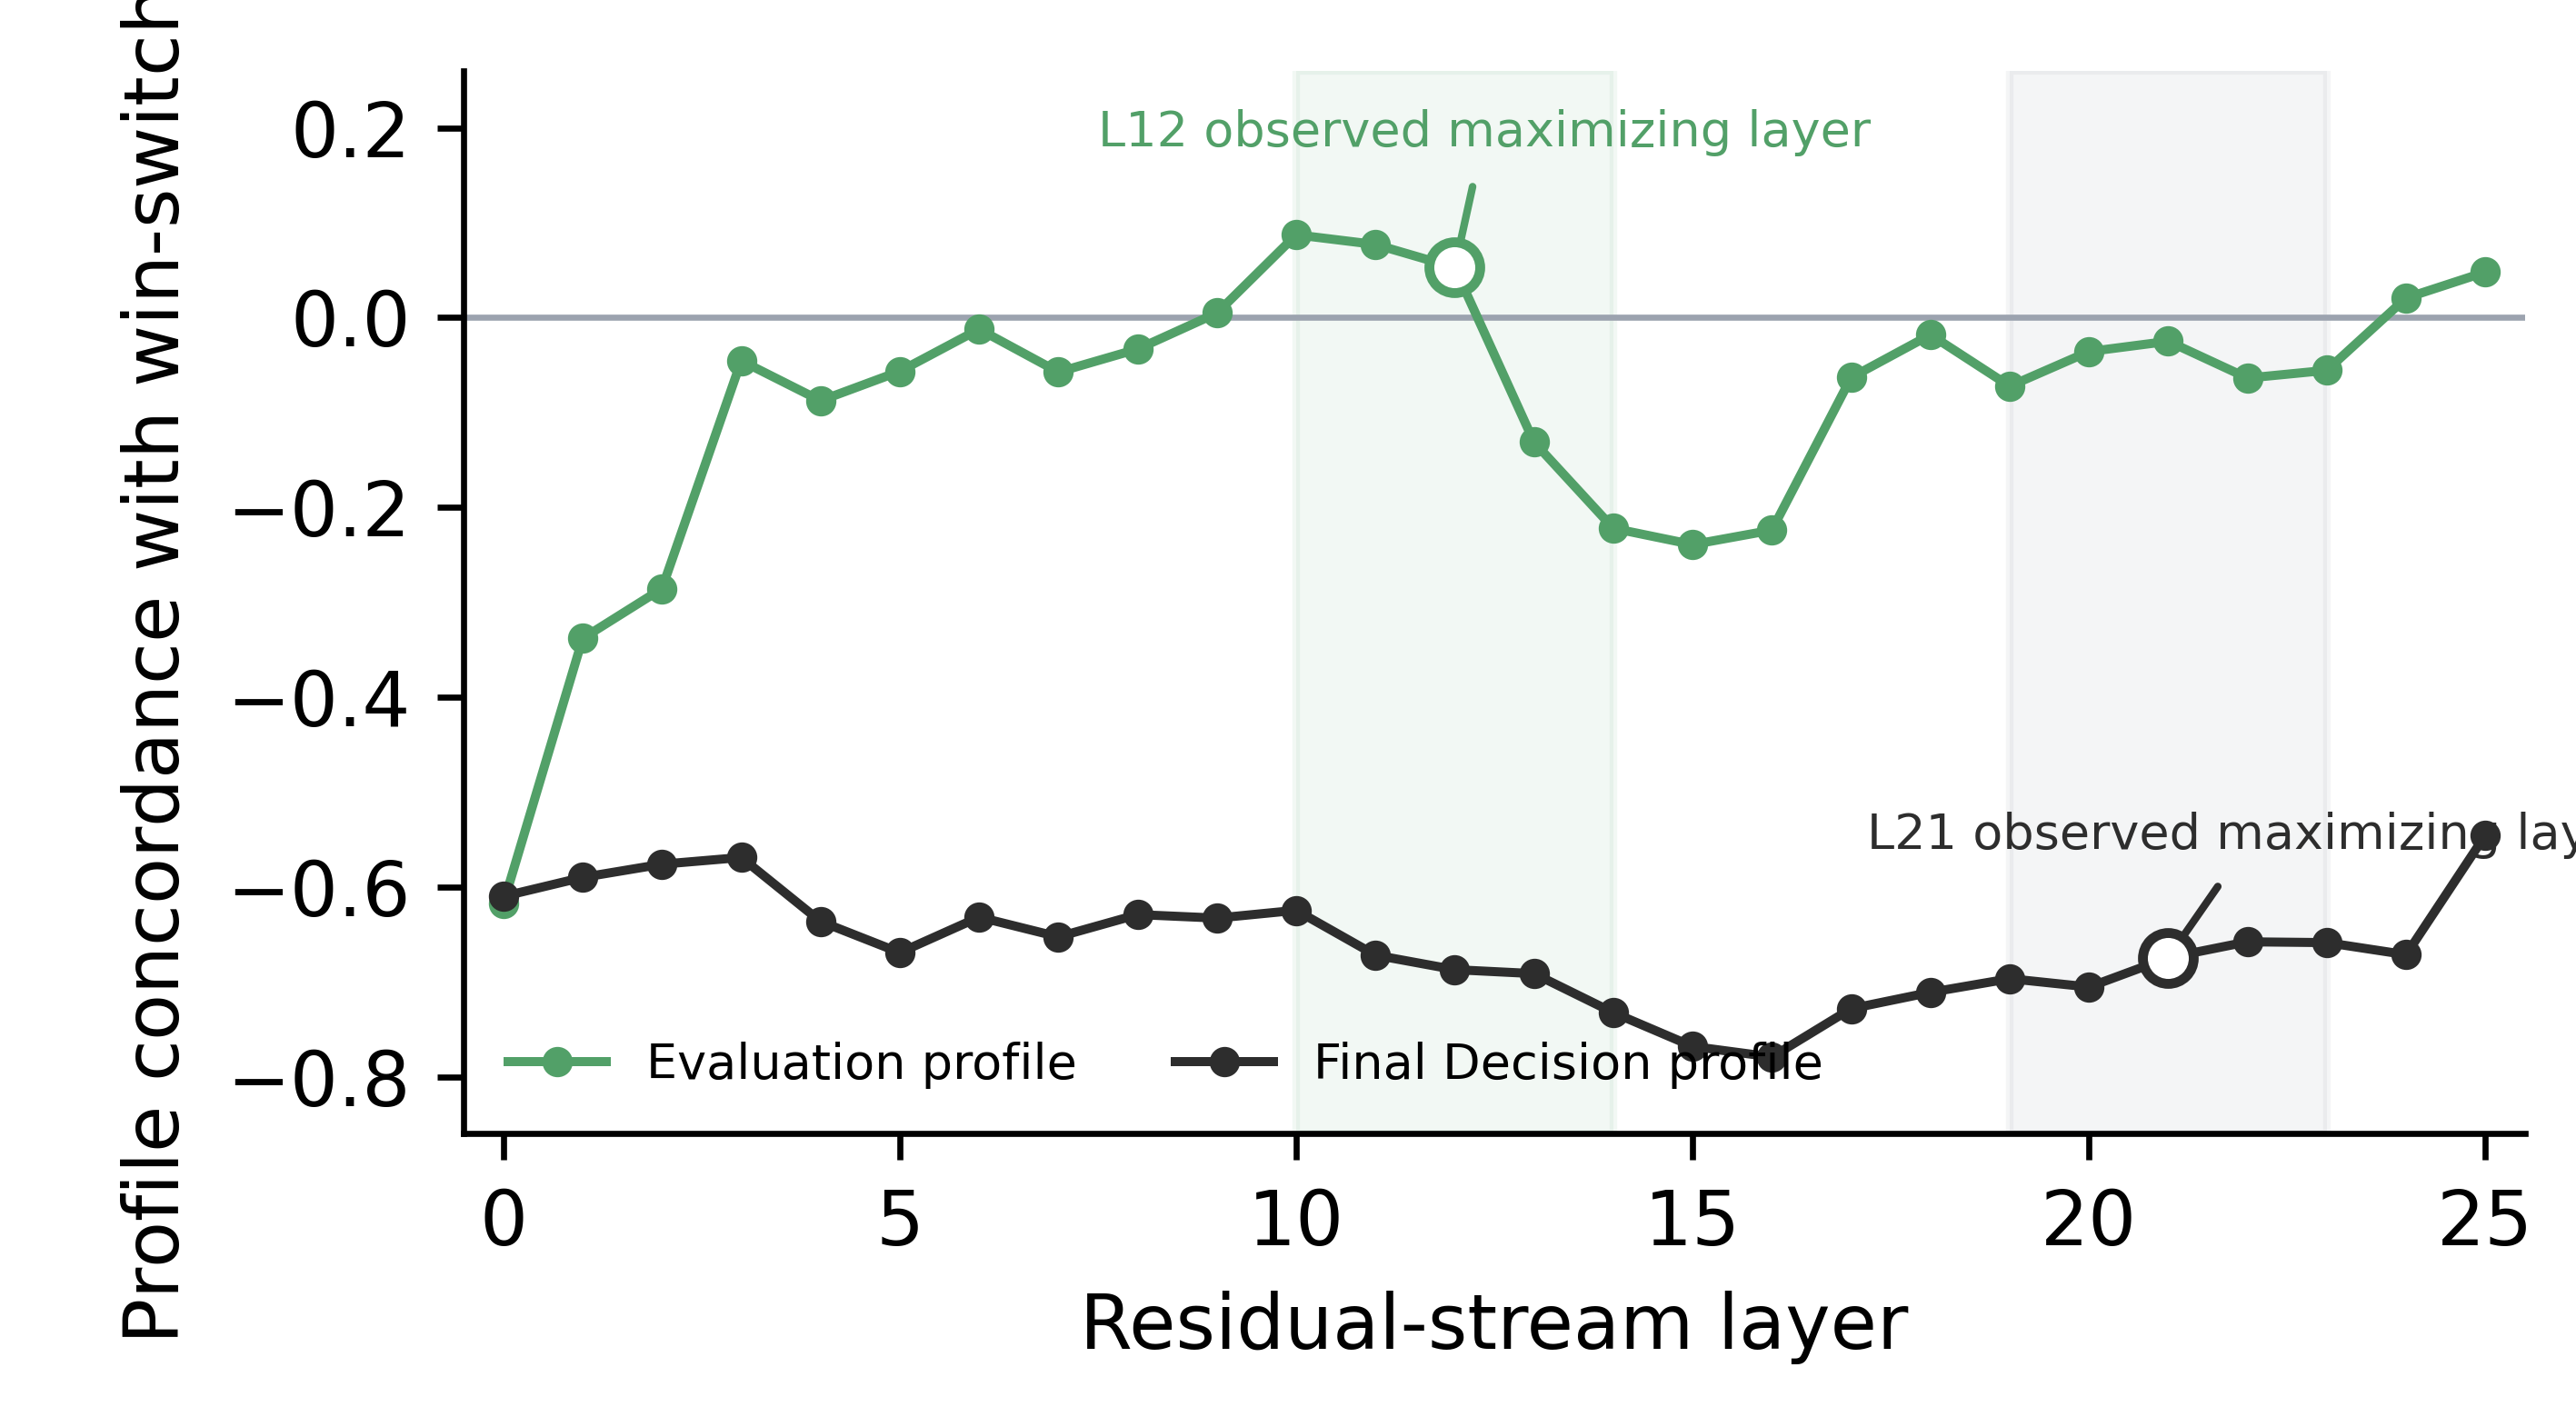

In [36]:
# Appendix figure — layer sensitivity of the token-profile result.
FIG3_SENSITIVITY_PNG = FIGURE_DIR / "fig3_layer_sensitivity.png"
FIG3_SENSITIVITY_PDF = FIGURE_DIR / "fig3_layer_sensitivity.pdf"
fig3s, ax3s = plt.subplots(figsize=(120 * MM, 66 * MM))
fig3s.subplots_adjust(left=.18, bottom=.20, right=.98, top=.95)
ax3s.axhline(0, color="#9CA3AF", lw=.8)
ax3s.axvspan(f3_selected_ev - 2, f3_selected_ev + 2, color=F3_EV, alpha=.07)
ax3s.axvspan(f3_selected_fd - 2, f3_selected_fd + 2, color="#6B7280", alpha=.07)
ax3s.plot(f3_layer_sensitivity.layer, f3_layer_sensitivity.ev_wsr_rho,
          marker="o", ms=3, lw=1.2, color=F3_EV, label="Evaluation profile")
ax3s.plot(f3_layer_sensitivity.layer, f3_layer_sensitivity.fd_wsr_rho,
          marker="o", ms=3, lw=1.2, color=F3_FD, label="Final Decision profile")
ev_selected_rho = f3_layer_sensitivity.loc[
    f3_layer_sensitivity.layer == f3_selected_ev, "ev_wsr_rho"
].iloc[0]
fd_selected_rho = f3_layer_sensitivity.loc[
    f3_layer_sensitivity.layer == f3_selected_fd, "fd_wsr_rho"
].iloc[0]
ax3s.scatter(f3_selected_ev, ev_selected_rho,
             s=45, facecolor="white", edgecolor=F3_EV, linewidth=1.3, zorder=4)
ax3s.scatter(f3_selected_fd, fd_selected_rho,
             s=45, facecolor="white", edgecolor=F3_FD, linewidth=1.3, zorder=4)
ax3s.annotate(f"L{f3_selected_ev} observed maximizing layer", (f3_selected_ev, ev_selected_rho), xytext=(7.5, .18),
              arrowprops={"arrowstyle": "-", "color": F3_EV}, color=F3_EV, fontsize=6.5)
ax3s.annotate(f"L{f3_selected_fd} observed maximizing layer", (f3_selected_fd, fd_selected_rho), xytext=(17.2, -.56),
              arrowprops={"arrowstyle": "-", "color": F3_FD}, color=F3_FD, fontsize=6.5)
ax3s.set(xlim=(-.5, 25.5), ylim=(-.86, .26), xlabel="Residual-stream layer",
         ylabel=r"Profile concordance with win-switch ($\rho$)")
ax3s.set_xticks([0, 5, 10, 15, 20, 25])
ax3s.legend(frameon=False, fontsize=6.5, ncol=2, loc="lower left")
ax3s.spines[["top", "right"]].set_visible(False)
fig3s.savefig(FIG3_SENSITIVITY_PNG, dpi=600, facecolor="white")
fig3s.savefig(FIG3_SENSITIVITY_PDF, facecolor="white")
plt.close(fig3s)
print("Saved:", FIG3_SENSITIVITY_PNG)
display(Image(filename=str(FIG3_SENSITIVITY_PNG)))

## Figure 3 reported outputs

The next cell reports selected-layer token-profile associations, rubric-specificity estimates, and neighborhood sensitivity around the Final Decision observed maximizing layer. The focal layers remain defined by Figure 1 encoding, not by vocabulary or win-switch results.

In [37]:
# Assemble the Figure 3 quantities used in reporting.
ev_selected = f3_selected_validation.query("dimension == 'Evaluation'").iloc[0]
fd_selected = f3_selected_validation.query("dimension == 'Final Decision'").iloc[0]
ev_specificity = f3_specificity.query("bundle == 'EV-lean'").iloc[0]
fd_specificity = f3_specificity.query("bundle == 'FD-lean'").iloc[0]
fd_near = f3_layer_sensitivity.query("near_fd_maximum").fd_wsr_rho

figure3_report = pd.DataFrame({
    "quantity": [
        "eligible_content_tokens",
        "lemma_channels",
        "evaluation_selected_layer",
        "evaluation_token_profile_wsr_rho",
        "evaluation_token_profile_wsr_p",
        "final_decision_selected_layer",
        "final_decision_token_profile_wsr_rho",
        "final_decision_token_profile_wsr_p",
        "evaluation_bundle_specificity_delta_r",
        "final_decision_bundle_specificity_delta_r",
        "final_decision_near_maximum_rho_min",
        "final_decision_near_maximum_rho_max",
        "final_decision_near_maximum_rho_median",
    ],
    "value": [
        len(f3_landscape),
        len(f3_lemmas),
        ev_selected.selected_layer,
        ev_selected.token_profile_wsr_rho,
        ev_selected.token_profile_wsr_p,
        fd_selected.selected_layer,
        fd_selected.token_profile_wsr_rho,
        fd_selected.token_profile_wsr_p,
        ev_specificity.partial_r_diff,
        fd_specificity.partial_r_diff,
        fd_near.min(),
        fd_near.max(),
        fd_near.median(),
    ],
})

filter_report_rows = []
for dimension in ["Evaluation", "Final Decision"]:
    retained_summary = f3_filter_summary.query(
        "dimension == @dimension and filter_status == 'retained'"
    ).iloc[0]
    robustness = f3_filter_robustness.query("dimension == @dimension")
    prefix = dimension.lower().replace(" ", "_")
    filter_report_rows.extend([
        {"quantity": f"{prefix}_retained_tokens_ever_top100",
         "value": retained_summary.tokens_ever_top100},
        {"quantity": f"{prefix}_retained_participant_token_top100_rate",
         "value": retained_summary.participant_token_top100_rate},
        {"quantity": f"{prefix}_filter_sensitivity_rho_min",
         "value": robustness.spearman_rho.min()},
        {"quantity": f"{prefix}_filter_sensitivity_rho_max",
         "value": robustness.spearman_rho.max()},
    ])
figure3_report = pd.concat(
    [figure3_report, pd.DataFrame(filter_report_rows)], ignore_index=True
)
figure3_report.to_csv(FIG3_DIR / "figure3_reported_summary.csv", index=False)
display(figure3_report.round(5))

,quantity,value
0,eligible_content_tokens,241.00000
1,lemma_channels,207.00000
2,evaluation_selected_layer,12.00000
3,evaluation_token_profile_wsr_rho,0.05263
4,evaluation_token_profile_wsr_p,0.41599
5,final_decision_selected_layer,21.00000
6,final_decision_token_profile_wsr_rho,-0.67463
7,final_decision_token_profile_wsr_p,0.00000
8,evaluation_bundle_specificity_delta_r,0.11149
9,final_decision_bundle_specificity_delta_r,-0.03998


## Figure 3 reproducibility checkpoint

This section is complete when the main figure, corpus-token score and rank diagnostics, frequency-threshold robustness table, full-vocabulary semantic audit, selected-layer validation table, exported statistics, and 26-layer sensitivity figure appear above.

---

# Figure 4 — activation patching and specificity controls

Figure 4 asks whether injecting Final-Decision-dominant geometry into Evaluation-dominant reflections changes a fixed layer-25 win-switch readout. Effects are reported in predicted residualized win-switch-rate proportion units. Pair-level live-forward outputs support three distinct analyses:

1. **Directionality:** compare the focal intervention with its reversed direction.
2. **Random-direction unusualness:** compare with 100 isotropic Gaussian directions.
3. **Contrast specificity:** compare with all nine other pairwise MP contrasts.

Layer-wise inference controls the complete 26-layer family with an exact sign-flip max-statistic procedure.

In [38]:
# Figure 4 paths and checkpointed pair-level live-forward outputs.
FIG4_DIR = DATA_DIR
FIG4_REQUIRED_CACHE = {
    "empirical": DATA_DIR / "empirical_pair_effects.csv",
    "specificity": DATA_DIR / "specificity_l19_pair_effects.csv",
    "random": DATA_DIR / "random_direction_l19_pair_effects.csv",
}
for name, path in FIG4_REQUIRED_CACHE.items():
    print(f"{name:>11} cache:", path, "[present]" if path.exists() else "[missing]")

  empirical cache: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\data\empirical_pair_effects.csv [present]
specificity cache: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\data\specificity_l19_pair_effects.csv [present]
     random cache: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\data\random_direction_l19_pair_effects.csv [present]


## Pair-level live-forward cache

Rerunning Gemma for every patched pair, layer, contrast, and random direction is the expensive part of Figure 4. The repository therefore includes the complete pair-level patched and unpatched predictions used in the manuscript. The next cell validates these inputs before reproducing every downstream statistic and visualization.

In [39]:
# Validate the complete pair-level inputs used by every Figure 4 analysis.
assert all(path.is_file() for path in FIG4_REQUIRED_CACHE.values())
cache_counts = {
    name: len(pd.read_csv(path)) for name, path in FIG4_REQUIRED_CACHE.items()
}
assert cache_counts == {"empirical": 780, "specificity": 150, "random": 1500}
print("Complete pair-level live-forward cache:", cache_counts)

Complete pair-level live-forward cache: {'empirical': 780, 'specificity': 150, 'random': 1500}


In [40]:
# Load the validated pair-level inputs used by every Figure 4 analysis.
figure4_pairs = {
    name: pd.read_csv(path) for name, path in FIG4_REQUIRED_CACHE.items()
}

In [41]:
# Validate the structure and experimental coverage of each cache.
assert figure4_pairs["empirical"].patch_layer.nunique() == 26
assert set(figure4_pairs["empirical"].condition) == {
    "main", "reversed_directionality"
}
assert all(
    count == 26
    for count in figure4_pairs["empirical"].groupby("condition").patch_layer.nunique()
)
assert figure4_pairs["specificity"].contrast_id.nunique() == 10
assert figure4_pairs["random"].random_rep.nunique() == 100

figure4_cache_summary = pd.DataFrame([
    {"cache": name, "rows": len(table), "columns": len(table.columns)}
    for name, table in figure4_pairs.items()
])
display(figure4_cache_summary)

,cache,rows,columns
0,empirical,780,12
1,specificity,150,14
2,random,1500,12


## Fixed readout and interpretable units

The layer-25 ridge readout is fitted without normalizing its coefficients. Both activation coordinates and win-switch rate are length-residualized; activation coordinates are then standardized with the fitted training scaler. A patch effect is the patched-minus-unpatched difference in this fixed ridge prediction and is therefore expressed as a change in predicted residualized win-switch-rate proportion, not arbitrary projection units. We report the observed and residualized WSR distributions alongside in-sample and out-of-fold readout diagnostics.

In [42]:
# Rebuild the fixed readout and report its scale diagnostics.
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import make_pipeline

f4_h25 = pooled["mean_L25"].astype(float)
f4_wsr_raw = df["wsr_avg"].to_numpy(float)
f4_h25_res = residualise(f4_h25, loglen)
f4_wsr_res = residualise(f4_wsr_raw, loglen)
f4_scaler = StandardScaler().fit(f4_h25_res)
f4_x = f4_scaler.transform(f4_h25_res)
f4_alpha = float(RidgeCV(alphas=np.logspace(-1, 5, 13)).fit(f4_x, f4_wsr_res).alpha_)
f4_ridge = Ridge(alpha=f4_alpha).fit(f4_x, f4_wsr_res)
f4_fitted = f4_ridge.predict(f4_x)
f4_oof = cross_val_predict(
    make_pipeline(StandardScaler(), Ridge(alpha=f4_alpha)), f4_h25_res, f4_wsr_res,
    cv=KFold(5, shuffle=True, random_state=SEED),
)

f4_descriptives = pd.DataFrame([
    {"variable": name, "n": len(values), "mean": values.mean(), "sd": values.std(ddof=1),
     "min": values.min(), "median": np.median(values), "max": values.max()}
    for name, values in [("raw_wsr", f4_wsr_raw), ("length_residualized_wsr", f4_wsr_res)]
])
f4_readout_stats = pd.DataFrame([
    {"evaluation": name, "ridge_alpha": f4_alpha,
     "r": pearsonr(f4_wsr_res, prediction).statistic,
     "r2": r2_score(f4_wsr_res, prediction),
     "rmse": mean_squared_error(f4_wsr_res, prediction) ** .5,
     "coefficient_l2_norm_unnormalized": np.linalg.norm(f4_ridge.coef_)}
    for name, prediction in [("in_sample", f4_fitted), ("5fold_fixed_alpha", f4_oof)]
])
f4_descriptives.to_csv(FIG4_DIR / "figure4_wsr_descriptives.csv", index=False)
f4_readout_stats.to_csv(FIG4_DIR / "figure4_readout_diagnostics.csv", index=False)
display(f4_descriptives.round(4))
display(f4_readout_stats.round(4))

,variable,n,mean,sd,min,median,max
0,raw_wsr,486,0.0958,0.1654,0.00,0.0202,0.9896
1,length_residualized_wsr,486,-0.0000,0.1563,-0.19,-0.0470,0.9564


,evaluation,ridge_alpha,r,r2,rmse,coefficient_l2_norm_unnormalized
0,in_sample,0.1,0.8810,0.7761,0.0739,0.1291
1,5fold_fixed_alpha,0.1,0.2716,-0.1935,0.1706,0.1291


## Familywise inference across patch layers

A pointwise interval at each layer does not control the chance of finding at least one apparently nonzero layer in a 26-layer sweep. We enumerate all $2^{15}=32{,}768$ paired sign assignments; the maximum absolute studentized statistic across the 26 layers supplies an exact familywise-adjusted $p$ value for every layer.

In [43]:
# Aggregate pair effects and apply exact max-|t| familywise inference.
import hashlib

f4_pair_effects = figure4_pairs["empirical"].copy()
f4_primary_pairs = f4_pair_effects.query("condition == 'main'")
f4_matrix = f4_primary_pairs.pivot(
    index="pair_id", columns="patch_layer", values="delta_wsr_predicted"
).sort_index(axis=1).to_numpy()
assert f4_matrix.shape == (15, 26)


def f4_stable_seed(*parts):
    payload = "|".join(map(str, (SEED, *parts))).encode()
    return int.from_bytes(hashlib.sha256(payload).digest()[:4], "little")


def f4_bootstrap_interval(values, seed, n_boot=5000):
    rng = np.random.default_rng(seed)
    means = values[rng.integers(0, len(values), size=(n_boot, len(values)))].mean(axis=1)
    return np.percentile(means, [2.5, 97.5])


def f4_exact_signflip_maxstat(matrix):
    n_pairs, n_layers = matrix.shape
    mean = matrix.mean(axis=0)
    se = matrix.std(axis=0, ddof=1) / np.sqrt(n_pairs)
    observed_t = mean / se
    raw_exceed = np.zeros(n_layers, dtype=int)
    max_exceed = np.zeros(n_layers, dtype=int)
    total = 1 << n_pairs
    bits = np.arange(n_pairs, dtype=np.uint64)
    for start in range(0, total, 4096):
        codes = np.arange(start, min(start + 4096, total), dtype=np.uint64)
        signs = (((codes[:, None] >> bits) & 1) * 2 - 1).astype(np.int8)
        perm_mean = signs @ matrix / n_pairs
        variance = (
            np.square(matrix).sum(0)[None, :] - n_pairs * perm_mean ** 2
        ) / (n_pairs - 1)
        perm_t = perm_mean / np.sqrt(np.maximum(variance, 0) / n_pairs)
        abs_t = np.abs(perm_t)
        raw_exceed += (
            abs_t >= np.abs(observed_t)[None, :] - 1e-12
        ).sum(0)
        max_exceed += (
            abs_t.max(1)[:, None] >= np.abs(observed_t)[None, :] - 1e-12
        ).sum(0)
    return pd.DataFrame({
        "patch_layer": np.arange(n_layers),
        "mean_delta": mean,
        "se": se,
        "t_stat": observed_t,
        "p_signflip_exact": raw_exceed / total,
        "p_maxstat_fwer_exact": max_exceed / total,
        "n_sign_patterns": total,
    })


f4_layer_inference = f4_exact_signflip_maxstat(f4_matrix)
f4_intervals = np.array([
    f4_bootstrap_interval(
        f4_matrix[:, layer], f4_stable_seed("bootstrap", "main", layer)
    )
    for layer in range(26)
])
f4_layer_inference[["ci95_low", "ci95_high"]] = f4_intervals
f4_layer_inference.to_csv(FIG4_DIR / "figure4_layer_inference.csv", index=False)
print("Layers surviving 26-layer FWER correction:",
      int((f4_layer_inference.p_maxstat_fwer_exact < .05).sum()))
display(f4_layer_inference.nsmallest(5, "p_maxstat_fwer_exact").round(4))

Layers surviving 26-layer FWER correction: 0


,patch_layer,mean_delta,se,t_stat,p_signflip_exact,p_maxstat_fwer_exact,n_sign_patterns,ci95_low,ci95_high
19,19,-0.1168,0.0404,-2.8885,0.0081,0.0715,32768,-0.1951,-0.0426
17,17,-0.1013,0.0357,-2.8365,0.0065,0.0795,32768,-0.1689,-0.0384
18,18,-0.1078,0.0400,-2.6967,0.0138,0.1039,32768,-0.1864,-0.0329
16,16,-0.0941,0.0376,-2.5033,0.0106,0.1447,32768,-0.1718,-0.0279
20,20,-0.1195,0.0486,-2.4580,0.0229,0.1560,32768,-0.2176,-0.0307


## Directionality and specificity controls

Reversing the Final Decision–Evaluation intervention establishes that the effect depends on direction, but does not show that this contrast is unique. At L19, we compare the empirical effect with 100 independent isotropic Gaussian directions normalized within pair to the empirical intervention norm and with all nine other pairwise MP contrasts.

- **Reversed intervention:** does the sign depend on patch direction?
- **Random directions:** is the empirical direction unusual among equally large arbitrary directions?
- **Other MP contrasts:** is the effect unique to Final Decision versus Evaluation?

In [44]:
# Compute random-direction and cross-dimension controls from pair effects.
f4_specificity_pairs = figure4_pairs["specificity"].copy()
f4_random_pairs = figure4_pairs["random"].copy()

f4_specificity_rows = []
for contrast_id, group in f4_specificity_pairs.groupby("contrast_id", sort=True):
    values = group.delta_wsr_predicted.to_numpy(float)
    low, high = f4_bootstrap_interval(
        values, f4_stable_seed("specificity", contrast_id)
    )
    first = group.iloc[0]
    f4_specificity_rows.append({
        "contrast_id": contrast_id,
        "col_a": first.col_a,
        "col_b": first.col_b,
        "n_pairs": len(values),
        "mean_delta": values.mean(),
        "ci95_low": low,
        "ci95_high": high,
        "ci_excludes_zero": (low > 0) or (high < 0),
    })
f4_specificity = pd.DataFrame(f4_specificity_rows)

f4_random_means = f4_random_pairs.groupby("random_rep").delta_wsr_predicted.mean()
f4_l19 = f4_layer_inference.query("patch_layer == 19").iloc[0]
f4_random_p = (
    1 + np.sum(np.abs(f4_random_means) >= abs(f4_l19.mean_delta))
) / (1 + len(f4_random_means))
f4_random_summary = pd.DataFrame([{
    "observed_mean_delta": f4_l19.mean_delta,
    "n_random": len(f4_random_means),
    "null_mean": f4_random_means.mean(),
    "null_sd": f4_random_means.std(ddof=1),
    "monte_carlo_two_sided_p": f4_random_p,
}])

f4_specificity.to_csv(
    FIG4_DIR / "figure4_l19_cross_dimension_specificity.csv", index=False
)
f4_random_means.rename("mean_delta").to_csv(
    FIG4_DIR / "figure4_l19_random_direction_null.csv"
)
f4_random_summary.to_csv(
    FIG4_DIR / "figure4_l19_random_direction_summary.csv", index=False
)
print("Other MP contrasts with bootstrap intervals excluding zero:",
      int(f4_specificity.query(
          "contrast_id != 'final_decision_continuous__minus__evaluation_continuous'"
      ).ci_excludes_zero.sum()), "/ 9")
display(f4_random_summary.round(4))
display(f4_specificity.round(4))

Other MP contrasts with bootstrap intervals excluding zero: 2 / 9


,observed_mean_delta,n_random,null_mean,null_sd,monte_carlo_two_sided_p
0,-0.1168,100,0.0038,0.04,0.0198


,contrast_id,col_a,col_b,n_pairs,mean_delta,ci95_low,ci95_high,ci_excludes_zero
0,comprehension_continuous__minus__confidence_co...,comprehension_continuous,confidence_continuous,15,0.0125,-0.0677,0.0901,False
1,comprehension_continuous__minus__evaluation_co...,comprehension_continuous,evaluation_continuous,15,-0.0094,-0.0573,0.0373,False
2,comprehension_continuous__minus__final_decisio...,comprehension_continuous,final_decision_continuous,15,0.1204,0.0216,0.2370,True
3,comprehension_continuous__minus__judgment_cont...,comprehension_continuous,judgment_continuous,15,-0.0355,-0.1289,0.0716,False
4,evaluation_continuous__minus__confidence_conti...,evaluation_continuous,confidence_continuous,15,-0.0282,-0.0916,0.0239,False
5,final_decision_continuous__minus__confidence_c...,final_decision_continuous,confidence_continuous,15,0.0400,-0.0087,0.0932,False
6,final_decision_continuous__minus__evaluation_c...,final_decision_continuous,evaluation_continuous,15,-0.1168,-0.1991,-0.0427,True
7,judgment_continuous__minus__confidence_continuous,judgment_continuous,confidence_continuous,15,0.0284,-0.0310,0.0941,False
8,judgment_continuous__minus__evaluation_continuous,judgment_continuous,evaluation_continuous,15,0.0172,-0.0549,0.0767,False
9,judgment_continuous__minus__final_decision_con...,judgment_continuous,final_decision_continuous,15,0.1127,0.0491,0.1898,True


## Figure 4 manuscript panel

The vertical scale is expressed in predicted residualized win-switch-rate proportion units and the statistical annotation reflects the declared 26-layer family. Pointwise participant-pair bootstrap bands are uncertainty summaries; they are not marked as layerwise discoveries.

Saved: C:\Users\ps967\Desktop\PhD\side-quest\mp-llm-geometry\figures\fig4.png


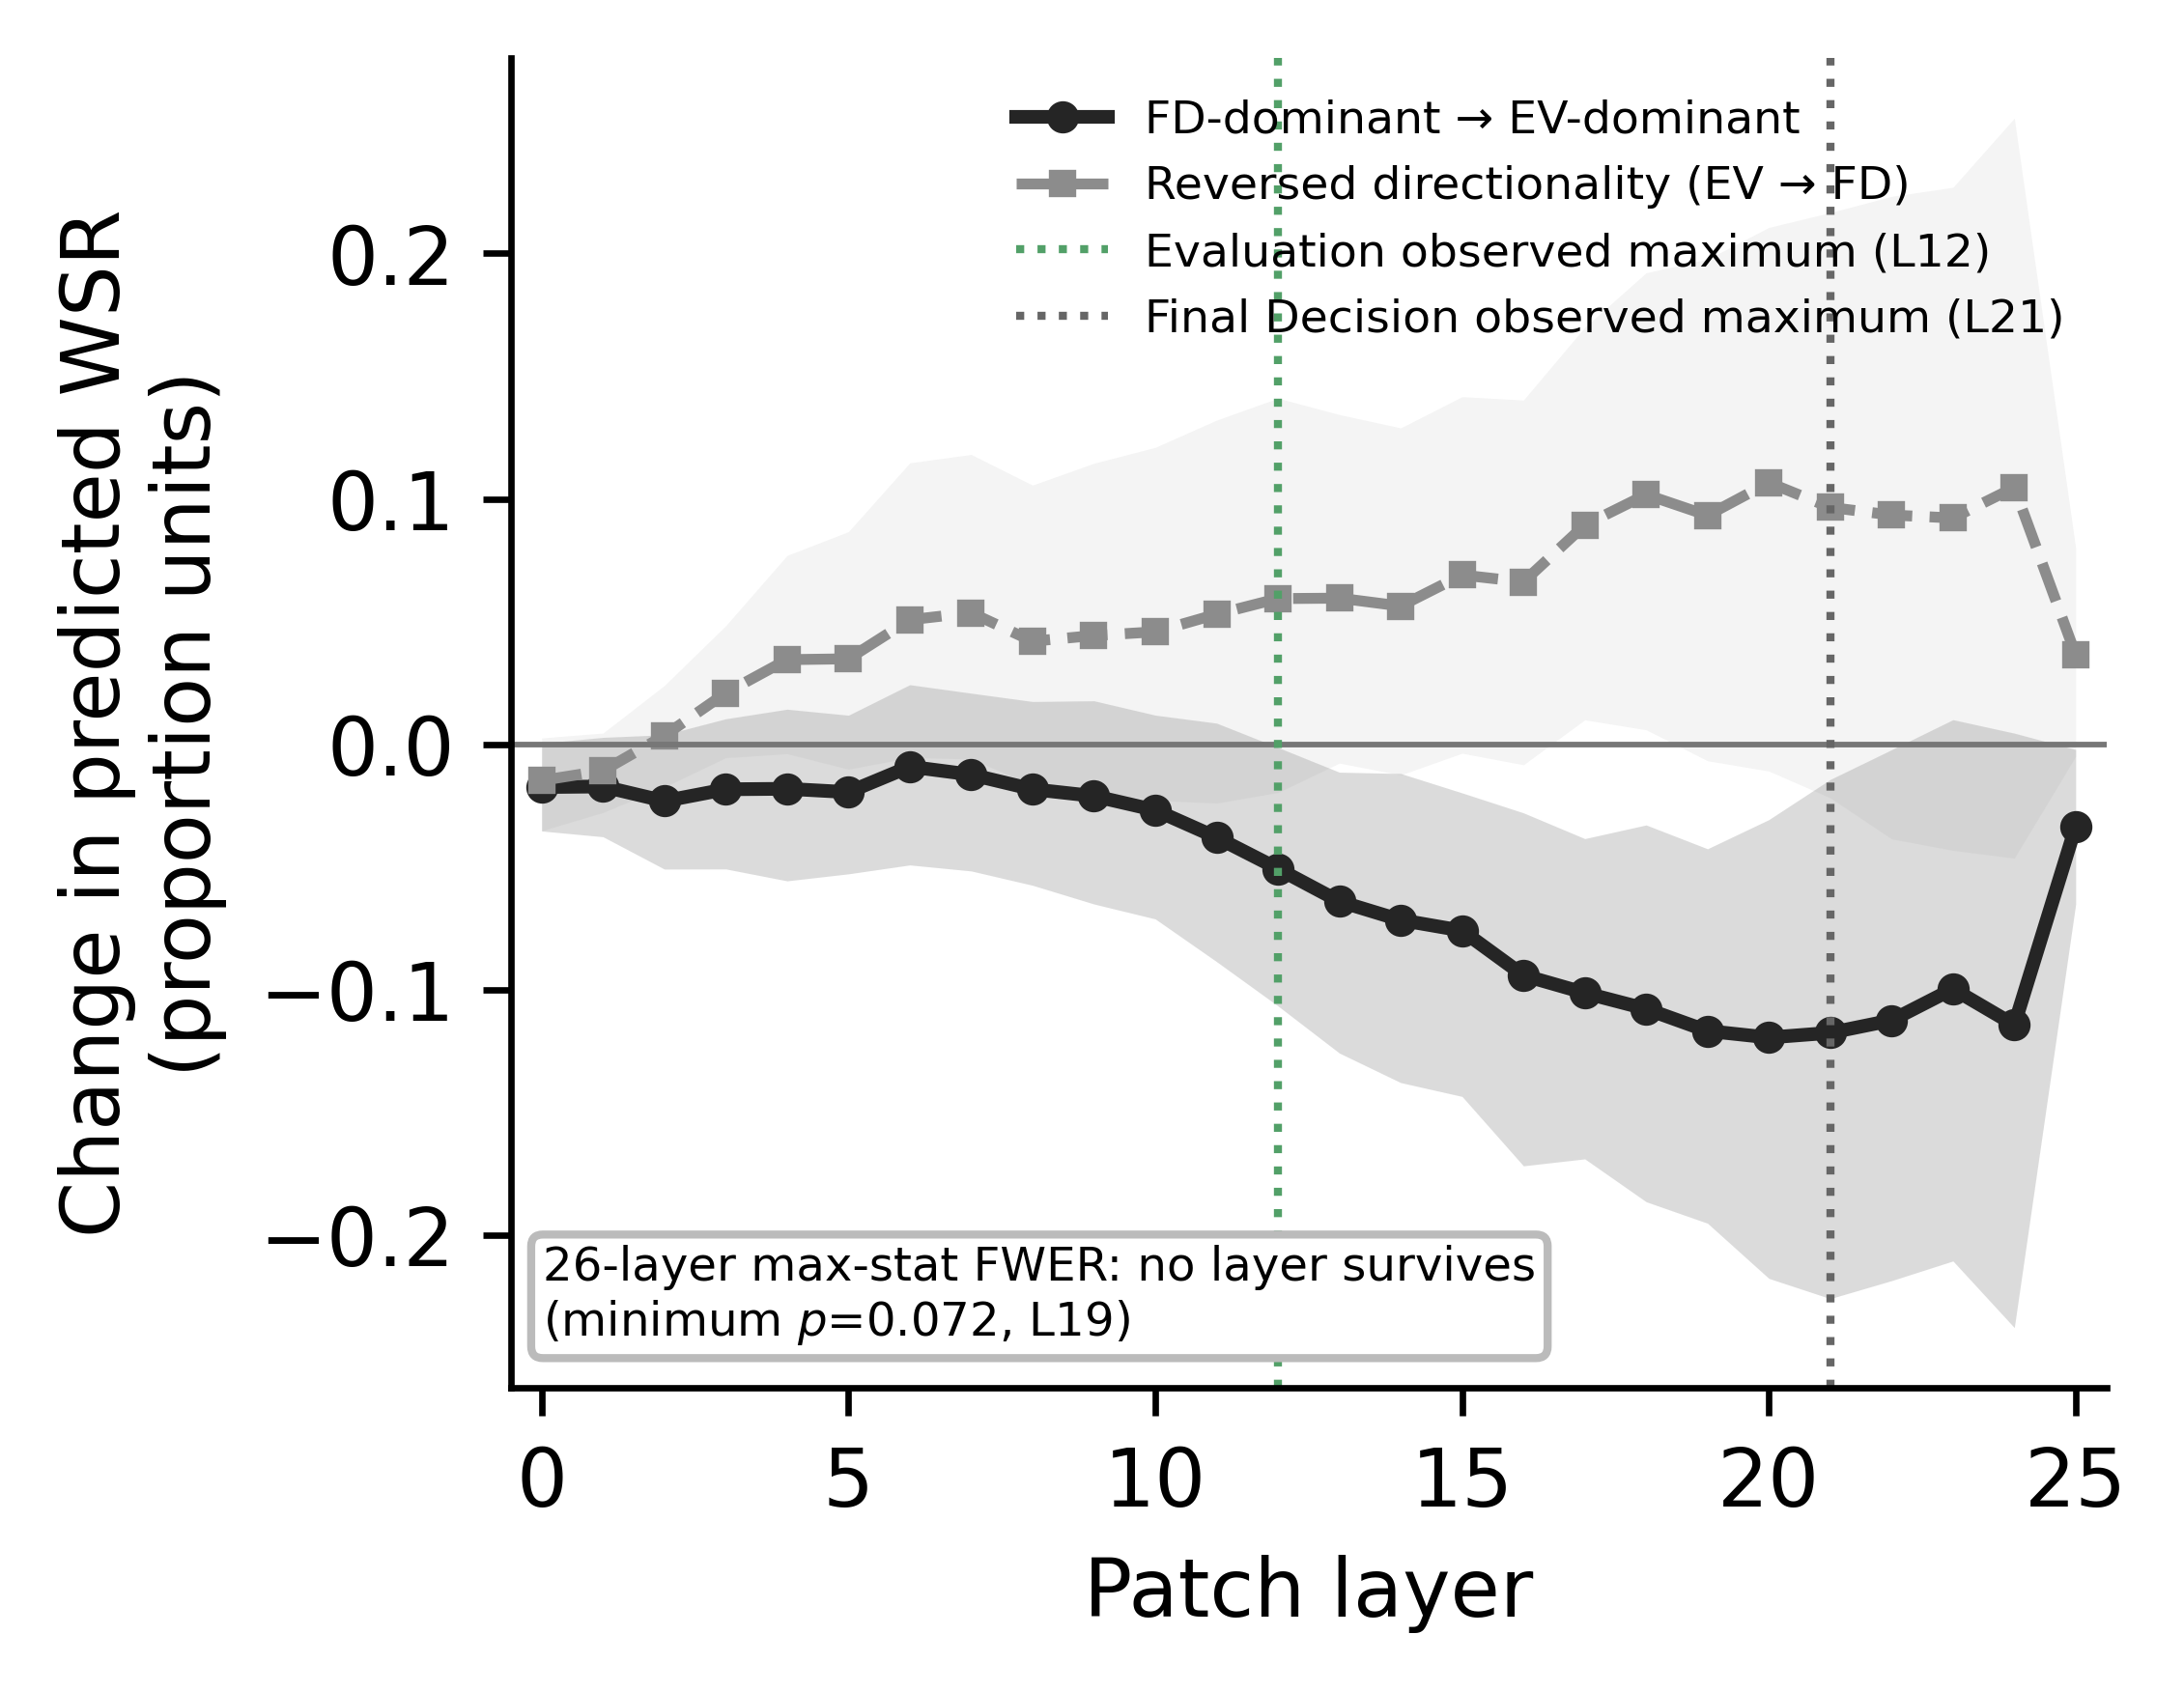

In [45]:
# Draw the Figure 4 manuscript panel from pair-level live-forward effects.
f4_aggregate_rows = []
for (condition, layer), group in f4_pair_effects.groupby(
    ["condition", "patch_layer"], sort=True
):
    values = group.delta_wsr_predicted.to_numpy(float)
    low, high = f4_bootstrap_interval(
        values, f4_stable_seed("bootstrap", condition, layer)
    )
    f4_aggregate_rows.append({
        "condition": condition,
        "patch_layer": int(layer),
        "mean_delta": values.mean(),
        "ci95_low": low,
        "ci95_high": high,
    })
f4_aggregate = pd.DataFrame(f4_aggregate_rows).merge(
    f4_layer_inference[[
        "patch_layer", "p_signflip_exact", "p_maxstat_fwer_exact"
    ]],
    on="patch_layer", how="left",
)
f4_aggregate.to_csv(FIG4_DIR / "figure4_layer_sweep.csv", index=False)

f4_main = f4_aggregate.query("condition == 'main'").sort_values("patch_layer")
f4_reverse = f4_aggregate.query(
    "condition == 'reversed_directionality'"
).sort_values("patch_layer")
min_fwer = f4_main.loc[f4_main.p_maxstat_fwer_exact.idxmin()]
FIG4_PNG = FIGURE_DIR / "fig4.png"
FIG4_PDF = FIGURE_DIR / "fig4.pdf"

fig4r, ax4r = plt.subplots(figsize=(92 * MM, 72 * MM))
fig4r.subplots_adjust(left=.22, bottom=.16, right=.98, top=.97)
ax4r.fill_between(
    f4_main.patch_layer, f4_main.ci95_low, f4_main.ci95_high,
    color="#252525", alpha=.16, linewidth=0,
)
ax4r.fill_between(
    f4_reverse.patch_layer, f4_reverse.ci95_low, f4_reverse.ci95_high,
    color="#969696", alpha=.10, linewidth=0,
)
ax4r.plot(
    f4_main.patch_layer, f4_main.mean_delta, color="#252525", lw=1.7,
    marker="o", ms=3, label="FD-dominant → EV-dominant",
)
ax4r.plot(
    f4_reverse.patch_layer, f4_reverse.mean_delta, color="#8C8C8C", lw=1.35,
    ls="--", marker="s", ms=2.5, label="Reversed directionality (EV → FD)",
)
ax4r.axhline(0, color="#777777", lw=.7)
ax4r.axvline(
    EV_LAYER, color=F3_EV, lw=1, ls=":",
    label=f"Evaluation observed maximum (L{EV_LAYER})",
)
ax4r.axvline(
    FD_LAYER, color="#666666", lw=1, ls=":",
    label=f"Final Decision observed maximum (L{FD_LAYER})",
)
ax4r.set(
    xlim=(-.5, 25.5),
    xlabel="Patch layer",
    ylabel="Change in predicted WSR\n(proportion units)",
)
ax4r.set_xticks([0, 5, 10, 15, 20, 25])
ax4r.legend(frameon=False, fontsize=5.7, loc="upper right")
ax4r.text(
    .02, .04,
    f"26-layer max-stat FWER: no layer survives\n"
    f"(minimum $p$={min_fwer.p_maxstat_fwer_exact:.3f}, "
    f"L{int(min_fwer.patch_layer)})",
    transform=ax4r.transAxes, fontsize=5.8,
    bbox={
        "boxstyle": "round,pad=.25", "facecolor": "white",
        "edgecolor": "#BBBBBB",
    },
)
ax4r.spines[["top", "right"]].set_visible(False)
fig4r.savefig(FIG4_PNG, dpi=600, bbox_inches="tight", facecolor="white")
fig4r.savefig(FIG4_PDF, bbox_inches="tight", facecolor="white")
plt.close(fig4r)
print("Saved:", FIG4_PNG)
display(Image(filename=str(FIG4_PNG)))

## Figure 4 interpretation and reported outputs

The analysis supports a direction-sensitive change in a model-internal readout, with important limits:

1. Effects are expressed in predicted residualized-WSR proportion units.
2. Pointwise evidence does not survive correction across the 26-layer family.
3. The focal direction is unusual relative to norm-matched random perturbations.
4. The effect is not unique among MP contrasts.
5. The endpoint is Gemma's fixed WSR readout, not an intervention on human behavior.

The next cell assembles the exact numerical results underlying these statements.

In [46]:
# Assemble the Figure 4 quantities used in reporting.
f4_l19 = f4_main.query("patch_layer == 19").iloc[0]
f4_l20 = f4_main.query("patch_layer == 20").iloc[0]
f4_reverse_l19 = f4_reverse.query("patch_layer == 19").iloc[0]
f4_other_specific = f4_specificity.query(
    "contrast_id != 'final_decision_continuous__minus__evaluation_continuous' "
    "and ci_excludes_zero"
)
f4_raw_desc = f4_descriptives.query("variable == 'raw_wsr'").iloc[0]
f4_res_desc = f4_descriptives.query(
    "variable == 'length_residualized_wsr'"
).iloc[0]

figure4_report = pd.DataFrame({
    "quantity": [
        "l19_mean_delta",
        "l19_ci95_low",
        "l19_ci95_high",
        "l19_exact_signflip_p",
        "l19_maxstat_fwer_p",
        "l20_mean_delta",
        "reverse_l19_mean_delta",
        "random_direction_monte_carlo_p",
        "other_mp_contrasts_ci_excludes_zero",
        "raw_wsr_mean",
        "raw_wsr_sd",
        "residualized_wsr_sd",
        "readout_in_sample_r",
        "readout_oof_r",
    ],
    "value": [
        f4_l19.mean_delta,
        f4_l19.ci95_low,
        f4_l19.ci95_high,
        f4_l19.p_signflip_exact,
        f4_l19.p_maxstat_fwer_exact,
        f4_l20.mean_delta,
        f4_reverse_l19.mean_delta,
        f4_random_p,
        len(f4_other_specific),
        f4_raw_desc["mean"],
        f4_raw_desc["sd"],
        f4_res_desc["sd"],
        f4_readout_stats.iloc[0].r,
        f4_readout_stats.iloc[1].r,
    ],
})
figure4_report.to_csv(FIG4_DIR / "figure4_reported_summary.csv", index=False)
display(figure4_report.round(4))

,quantity,value
0,l19_mean_delta,-0.1168
1,l19_ci95_low,-0.1951
2,l19_ci95_high,-0.0426
3,l19_exact_signflip_p,0.0081
4,l19_maxstat_fwer_p,0.0715
5,l20_mean_delta,-0.1195
6,reverse_l19_mean_delta,0.0933
7,random_direction_monte_carlo_p,0.0198
8,other_mp_contrasts_ci_excludes_zero,2.0000
9,raw_wsr_mean,0.0958


## Final reproducibility checkpoint

The notebook is complete when Figures 1–4, appendix figures, and all reported statistical tables have been regenerated from the de-identified participant data, shared activation checkpoint, and validated pair-level live-forward cache.